# **Airbnb Price Prediction Project**
### **Using Regression Models**

---

# **1. Introduction**

This project aims to predict booking prices for Airbnb listings across ten major European cities:

	•	Amsterdam, Athens, Barcelona, Berlin, Budapest, Lisbon, London, Paris, Rome, and Vienna.

The objective is to build an accurate predictive model that estimates booking prices based on several factors such as room type, capacity, location, and guest satisfaction. These predictions can help Airbnb hosts optimize pricing strategies and allow guests to find competitively priced properties.

Due to the diversity of features and the presence of outliers (e.g., luxury properties), the project emphasizes data preprocessing, feature engineering, and advanced regression models to generate reliable, business-relevant insights.

# **2. Data Exploration**

This part involves summarizing categorical and continuous features to identify key trends.

---

**Please explore the metadata file to gain further insights into the dataset and its features before proceeding!**

In [4]:
#Import essentials librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Read the data file
df = pd.read_excel('airbnb-data-merged.xlsx', sheet_name='data')

# Print the first 5 rows of the dataset
df.head()

,id,cities,time_periods,booking_amount,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,...,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,1,Athens,Weekdays,129.824479,Entire home/apt,False,False,4,False,False,...,100,2,2.813964,0.881890,55.348572,2.086871,78.778377,5.915160,23.76600,37.98300
1,2,Athens,Weekdays,138.963748,Entire home/apt,False,False,4,True,True,...,96,1,0.407293,0.304568,240.306654,9.060559,407.167696,30.572629,23.73168,37.97776
2,3,Athens,Weekdays,156.304923,Entire home/apt,False,False,3,True,False,...,98,1,1.237211,0.288488,199.507366,7.522257,395.967403,29.731642,23.72200,37.97900
3,4,Athens,Weekdays,91.627024,Entire home/apt,False,False,4,True,True,...,99,1,4.367457,0.297467,39.803047,1.500740,58.706578,4.408047,23.72712,38.01435
4,5,Athens,Weekdays,74.051508,Private room,False,True,2,False,False,...,100,1,2.194185,0.385266,78.733405,2.968577,113.325973,8.509204,23.73391,37.99529


In [6]:
# Get info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          51707 non-null  int64  
 1   cities                      51707 non-null  object 
 2   time_periods                51707 non-null  object 
 3   booking_amount              51707 non-null  float64
 4   room_type                   51707 non-null  object 
 5   room_shared                 51707 non-null  bool   
 6   room_private                51707 non-null  bool   
 7   person_capacity             51707 non-null  int64  
 8   host_is_superhost           51707 non-null  bool   
 9   multi                       51707 non-null  bool   
 10  biz                         51707 non-null  bool   
 11  cleanliness_rating          51707 non-null  int64  
 12  guest_satisfaction_overall  51707 non-null  int64  
 13  bedrooms                    517

    The dataset contains 51,707 entries with 22 features representing both categorical and numerical data.
    Below is an overview of the key features:

	Categorical Features:
	• cities (City names)
	• time_periods (Weekend or Weekday bookings)
	• room_type (Private, shared, entire property)
	• room_shared, room_private (Boolean values)
	• host_is_superhost (Indicates if the host is a superhost)
	• multi, biz (Additional property features)

	Numerical Features:
	• booking_amount (The target feature, representing the booking price)
	• person_capacity (Maximum guests allowed)
	• cleanliness_rating, guest_satisfaction_overall (Customer ratings)
	• bedrooms (Number of rooms)
	• dist, metro_dist (Distances to city center or metro)
	• attr_index, rest_index (Attraction and restaurant indices)

	Geolocation: lng, lat

In [8]:
# Change all columns with booleans to 0 and 1
df = df.replace({True: 1, False: 0})

In [9]:
# Process to descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,51707.0,25854.000000,14926.669521,1.000000,12927.500000,25854.000000,38780.500000,51707.000000
booking_amount,51707.0,279.879591,327.948386,34.779339,148.752174,211.343089,319.694287,18545.450285
room_shared,51707.0,0.007078,0.083835,0.000000,0.000000,0.000000,0.000000,1.000000
room_private,51707.0,0.361518,0.480445,0.000000,0.000000,0.000000,1.000000,1.000000
person_capacity,51707.0,3.161661,1.298545,2.000000,2.000000,3.000000,4.000000,6.000000
host_is_superhost,51707.0,0.255903,0.436372,0.000000,0.000000,0.000000,1.000000,1.000000
multi,51707.0,0.291353,0.454390,0.000000,0.000000,0.000000,1.000000,1.000000
biz,51707.0,0.350204,0.477038,0.000000,0.000000,0.000000,1.000000,1.000000
cleanliness_rating,51707.0,9.390624,0.954868,2.000000,9.000000,10.000000,10.000000,10.000000
guest_satisfaction_overall,51707.0,92.628232,8.945531,20.000000,90.000000,95.000000,99.000000,100.000000


    ⚛ RECAP ⚛

	Booking Amount:
	• Prices exhibit a highly skewed distribution, ranging from $34 to approximately $18,500
	• The majority of bookings are concentrated around $211, as indicated by descriptive statistics

    Room Type
    • Private rooms account for 36% of all bookings
	• Shared rooms are virtually non-existent, representing less than 1% of the market

    Person capacity
    • Room capacities range from 2 to 6 people
	• The average room capacity is 3 people

    Host is Superhost
    • 25% of properties are managed by Superhosts

    Business Purposes (biz)
    • 35% of properties are rented primarily for business purposes

    Cleanliness Rating
    • Cleanliness ratings range from 2 to 10
	• A significant majority of properties achieve a perfect cleanliness rating of 10

    Guest Satisfaction Overall
    • Guest satisfaction ratings range from 20 to 100
	• Most properties receive satisfaction ratings above 95

    Bedrooms
    • The number of bedrooms per property ranges from 0 to 10
	• The majority of properties have at least one bedroom

    Distance from city center (dist)
    • On average, properties are located 3 miles from the city center

    Metro Distance
    • A significant proportion of properties are situated near metro transportation
    
    Attraction and Restaurant Indices
    • Most properties are within a reasonable distance of various attractions and restaurants

# **3. Data Preparation**

This part involves addressing missing and duplicate values by imputation and clean the data by handling outliers with differents methods.

In [12]:
# Check if our dataset contains any null values
null_values = df.isnull().sum()
print(null_values)

id                            0
cities                        0
time_periods                  0
booking_amount                0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index                    0
attr_index_norm               0
rest_index                    0
rest_index_norm               0
lng                           0
lat                           0
dtype: int64


In [13]:
# Check if our dataset contains any duplicated values
duplicated_values = df.duplicated().sum()
print("The number of duplicated values are : ", duplicated_values)

The number of duplicated values are :  0


    No missing values or duplicate entries were found

### **Exploration of Booking Amount Distribution**


Statistics of Booking Amount:
count    51707.000000
mean       279.879591
std        327.948386
min         34.779339
25%        148.752174
50%        211.343089
75%        319.694287
max      18545.450285
Name: booking_amount, dtype: float64


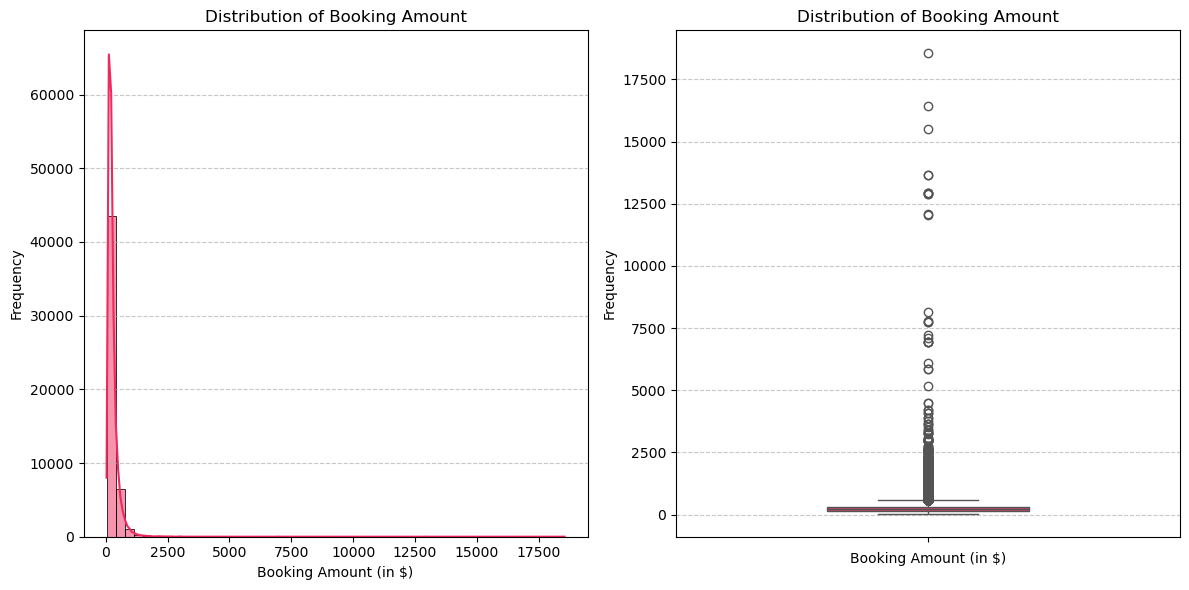

In [16]:
# Print statistics
print("\nStatistics of Booking Amount:")
print(df['booking_amount'].describe())

# Visualize the distribution of the booking amount
# Create a single figure with two subplots
plt.figure(figsize=(12, 6))

# Subplot 1: Histogram
ax1 = plt.subplot(1, 2, 1)
sns.histplot(df['booking_amount'], kde=True, bins=50, color='#ef295c', ax=ax1)
ax1.set_title('Distribution of Booking Amount')
ax1.set_xlabel('Booking Amount (in $)')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Boxplot
ax2 = plt.subplot(1, 2, 2)
sns.boxplot(df['booking_amount'], color='#ef295c', saturation=0.75, width=0.4, ax=ax2)
ax2.set_title('Distribution of Booking Amount')
ax2.set_xlabel('Booking Amount (in $)')
ax2.set_ylabel('Frequency')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()
plt.show()

    ⚛ RECAP ⚛

    Booking Amount Distribution Analysis
    To investigate the data's dispersion and identify potential anomalies or errors, we examined the distribution of booking amounts.
    The boxplot analysis revealed several outliers, indicating unusually high values that may be anormal.
    
    For instance in this data set, a booking amount of $18,000 for a single night's stay is significantly extreme and likely represents an outlier.
    • Distribution: The distribution of booking amounts is right-skewed, meaning there are a few very high values that pull the average to the right.
    • Outliers: The boxplot identified several outliers, including the $18,000 value, which is considered an anomaly for a one-night rental.

### **Handling Outliers**

Outliers can significantly impact the performance of regression models, particularly those sensitive to extreme values like linear regression.

While several methods exist for handling outliers, in this case, we considered using z-score method. In our project context, we found that unusually high booking amounts might represent legitimate luxury property listings rather than data errors.

The number of outliers in the dataset is: 403

Statistics of Booking Amount Capped:
Minimum: 34.78
Maximum: 1160.84
Mean: 270.27
Median: 211.34
Standard Deviation: 191.65



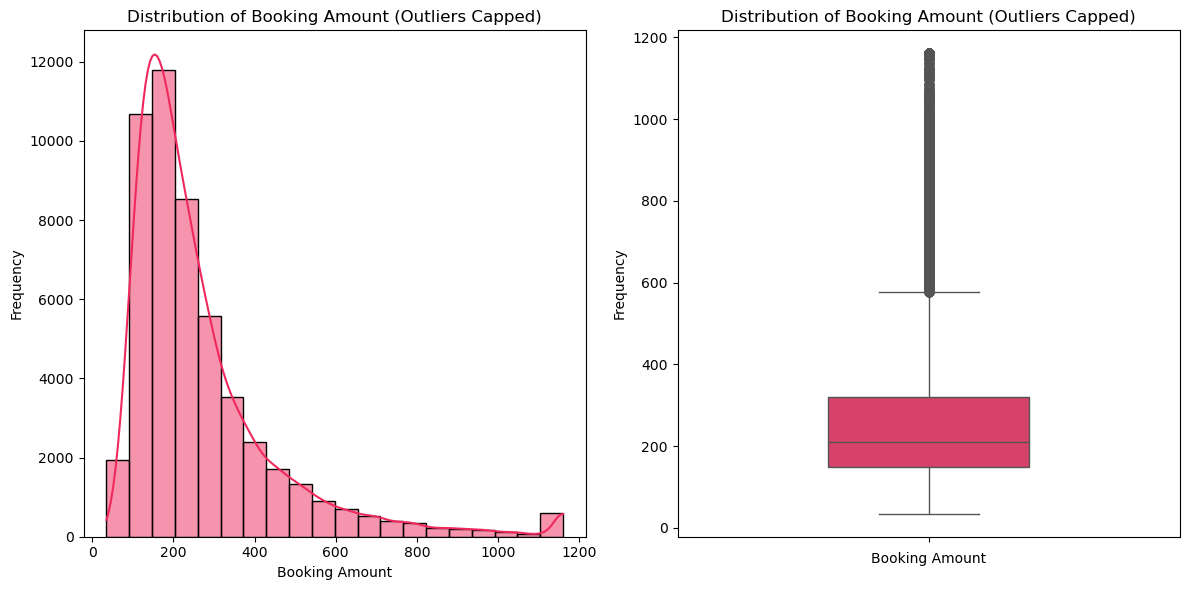

In [19]:
# 1. Detect Outliers using z-score method
# Calculate Z-scores for 'booking_amount'
df['zscore_booking_amount'] = np.abs(stats.zscore(df['booking_amount']))

# Define a threshold for outliers
threshold = 3

# Subset the dataset without outliers
df_no_outliers = df[df['zscore_booking_amount'] <= threshold]

# Print the number of outliers
num_outliers = df.shape[0] - df_no_outliers.shape[0]
print("The number of outliers in the dataset is:", num_outliers)

# 2. Winsorization
# Calculate the 99th percentile of 'booking_amount'
percentile_99 = df['booking_amount'].quantile(0.99)

# Cap the outliers at the 99th percentile
df['booking_amount_capped'] = np.where(df['booking_amount'] > percentile_99, percentile_99, df['booking_amount'])

# Print the statistics
print("\nStatistics of Booking Amount Capped:")
print(f"Minimum: {df['booking_amount_capped'].min():.2f}")
print(f"Maximum: {df['booking_amount_capped'].max():.2f}")
print(f"Mean: {df['booking_amount_capped'].mean():.2f}")
print(f"Median: {df['booking_amount_capped'].median():.2f}")
print(f"Standard Deviation: {df['booking_amount_capped'].std():.2f}\n")

# 3. Visualization
# Visualize the distribution of the dataset with outliers capped
# Create a single figure with two subplots
plt.figure(figsize=(12, 6))

# Subplot 1: Histogram
ax1 = plt.subplot(1, 2, 1)
sns.histplot(df['booking_amount_capped'], kde=True, bins=20, color='#ef295c', ax=ax1)
ax1.set_title('Distribution of Booking Amount (Outliers Capped)')
ax1.set_xlabel('Booking Amount')
ax1.set_ylabel('Frequency')

# Subplot 2: Boxplot
ax2 = plt.subplot(1, 2, 2)
sns.boxplot(df['booking_amount_capped'], color='#ef295c', saturation=0.75, width=0.4, ax=ax2)
ax2.set_title('Distribution of Booking Amount (Outliers Capped)')
ax2.set_xlabel('Booking Amount')
ax2.set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()


    ⚛ RECAP ⚛

    Identifying and Addressing Outliers
	• Number of Outliers: We identified 403 outliers in the dataset.
    • Winsorization: To improve the visualization of the data distribution and mitigate the impact of outliers, we applied winsorization. This technique caps outliers at the 99th percentile, providing a clearer view of the distribution.
    • Visualization: After winsorization, we visualized the new data points, subtracting the 99th percentile to minimize the outliers' influence.
    • Distribution: Despite winsorization, the distribution of booking amounts remains right-skewed, indicating the presence of a few very high values.

    Preserving Outlier Information
    Since the outliers are valid data points representing luxury properties, we chose to flag them as a new feature.
    This allows the model to recognize and potentially categorize these properties during the predictive phase, providing better insights and predictions.

### **Feature Engineering**
Creating new features or transforming existing variables is a pivotal step in the analysis process. This can significantly improve predictive accuracy by providing the model with more informative and relevant information.

In [22]:
# 1. Create a new binary feature "luxury_props" based on the Z-score threshold
df['luxury_props'] = (df['zscore_booking_amount'] > threshold).astype(int)

# Function to categorize person capacity
def categorize_capacity(capacity):
  if capacity <= 2:
    return 'Small Capacity'
  elif capacity <= 4:
    return 'Medium Capacity'
  else:
    return 'Large Capacity'

# 2. Create a new feature 'capacity' to classify person_capacity
df['capacity'] = df['person_capacity'].apply(categorize_capacity)

# Function to categorize bedrooms
def room_size(bedrooms):
  if bedrooms <= 3:
    return 'Normal size'
  elif bedrooms <= 7:
    return 'Large size'
  else:
    return 'Extra-large size'

# 3. Create a new feature 'room_size' to classify bedrooms
df['room_size'] = df['bedrooms'].apply(room_size)

# Function to categorize overall_satisfaction
def categorize_satisfaction(rating):
  if rating <= 40:
    return 'Low'
  elif rating <= 80:
    return 'Medium'
  else:
    return 'High'

# 4. Create a new feature 'overall_satisfaction' to classify satisfaction (rate/100)
df['overall_satisfaction'] = (df['guest_satisfaction_overall'] * df['cleanliness_rating']) / 10

# 5. Creating 'weekend' feature based on time_periods
df['weekend'] = df['time_periods'].apply(lambda x: 1 if 'weekends' in x.lower() else 0)

# Distance Features
# Function to categorize distance
def categorize_distance(distance):
    """
    Categorizes distance values (in miles) into categories based on proximity.

    Parameters:
    distance (float): The distance in miles to categorize.

    Returns:
    str: The distance category.
    """
    if distance <= 1:
        return 'Very Close'
    elif distance <= 3:
        return 'Close'
    elif distance <= 6:
        return 'Moderate'
    elif distance <= 10:
        return 'Far'
    elif distance <= 50:
        return 'Very Far'
    else:
        return 'Extremely Far'

# 6. Create a new feature to categorize distance
df['city_dist_from_props'] = df['dist'].apply(categorize_distance)
df['metro_dist_from_props'] = df['metro_dist'].apply(categorize_distance)
df['attr_dist_from_props'] = df['attr_index_norm'].apply(categorize_distance)
df['rest_dist_from_props'] = df['rest_index_norm'].apply(categorize_distance)

# Derived Metrics
# 7. Create a new feature 'price_per_room' to capture the booking price per room
df['price_per_room'] = df['booking_amount'] / df['bedrooms']

# 8. Create a new feature 'person_per_room' to capture the number of person per room
df['person_per_room'] = df['person_capacity'] / df['bedrooms']

# 9. Create a new feature 'price_per_person' to capture the price spent by one person
df['price_per_person'] = df['booking_amount'] / df['person_per_room']

# replace infinite values by O to prevent errors
df = df.replace([np.inf, -np.inf], 0)

    ⚛ Feature Breakdown ⚛
	1. luxury_props: Identifies properties with exceptionally high booking amounts, likely representing luxury listings. This feature is derived using a Z-score threshold method to distinguish between regular and high-end properties.
    2. capacity: Categorizes properties based on their person capacity, providing a more granular understanding of their suitability for different group sizes.
    3. room_size: Categorizes properties based on the number of bedrooms, offering insights into their overall size and potential accommodation capacity.
    4. overall_satisfaction: Categorizes properties based on their overall satisfaction (cleanliness_rating x guest_satisfaction_overall), a crucial factor influencing guest satisfaction and booking decisions.
    5. weekend: Indicates whether a property is typically booked on weekends, helping to identify properties popular for leisure travel.
    6. Distance Features: Categorizes properties into “Very Close,” “Close,” “Moderate,” and “Far” based on their distances from metro, attractions, or city center.
    7. Derived Metrics: Calculates derived metrics related to pricing and occupancy

# **4. Exploratory Data Analysis**

This section focuses on a step by step examination of the cleaned data to reveal concealed patterns, relationships, and insights through the use of integrated visualizations.

Initially, we separate the dataset into two categories that represent classic and luxury properties.

In [25]:
# Filter the DataFrame to include only rows where luxury_props is 0 (classic properties)
classic_props_df = df[df['luxury_props'] == 0]

# Filter the DataFrame to include only rows where luxury_props is 1 (luxury properties)
luxury_props_df = df[df['luxury_props'] == 1]

### **Useful Plot Functions**

In [27]:
# Helper function to plot bar plots
def plot_bar(data, ax, title, x=None, y=None, color=None, xlabel=None, ylabel=None, rotation=0, stacked=False):
    """
    Plots a bar plot to visualize data.

    Parameters:
    - data: DataFrame containing the data to plot.
    - ax: The axis to plot on.
    - title: The title of the plot.
    - x: The label for the x-axis.
    - y: The label for the y-axis.
    - color: The color for the scatter plot.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - rotation: The rotation angle for the x-axis labels.
    - stacked: Whether to stack the bars or not.
    """
    # Create the bar plot
    ax = data.plot(
        kind='bar',
        color=color,
        linewidth=1.2,
        edgecolor='black',
        stacked=stacked,
        ax=ax
    )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=rotation, labelsize=10)


# Helper function to plot heatmap plots
def plot_heatmap(data, ax, title, palette=None, xlabel=None, ylabel=None, rotation=0):
    """
    Plots a heatmap to visualize data.

    Parameters:
    - data: DataFrame containing the data to plot.
    - ax: The axis to plot on.
    - title: The title of the plot.
    - palette: The color palette to use for the heatmap.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - rotation: The rotation angle for the x-axis labels.
    """

    # Create the heatmap plot
    sns.heatmap(
        data,
        annot=True,
        cmap=palette,
        fmt=".2f",
        linewidths=0.5,
        linecolor='black',
        ax=ax
    )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=rotation)

# Helper function to plot scatter and regression plots
def plot_scatter(data, correlation, ax, title, x=None, y=None, palette=None, hue=None, size=None, legend_loc=None, legend_title=None, xlabel=None, ylabel=None):
    """
    Plots the relationship between two continues features,
    including a scatter plot with a regression line.

    Parameters:
    - data: DataFrame containing the data to plot.
    - correlation: The correlation value between 'dist' and 'booking_amount'.
    - ax: The axis to plot on.
    - title: The title of the plot.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - x: The label for the x-axis.
    - y: The label for the y-axis.
    - hue: The label for the hue.
    - palette: The color palette to use for the scatter plot.
    - size: The label for the size.
    - legend_loc: The location of the legend.
    - legend_title: The title of the legend.
    """
    # Create the scatterplot
    sns.scatterplot(
        x=x,
        y=y,
        data=data,
        hue=hue,
        palette=palette,
        size=size,
        sizes=(50, 150),
        alpha=0.6,
        ax=ax
    )

    # # Add regression line
    # sns.regplot(
    #     x=x,
    #     y=y,
    #     data=data,
    #     scatter=False,
    #     color='red',
    #     line_kws={"linewidth": 2.5},
    #     ax=ax
    # )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc=legend_loc, title=legend_title, fontsize=12)

    # Display the correlation value on the plot
    ax.text(
        0.05, 0.95, f'Correlation: {correlation:.2f}',
        transform=ax.transAxes, fontsize=12,
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5', alpha=0.7)
    )


# Helper function to plot line plots
def plot_line(data, ax, title, x=None, y=None, hue=None, style=None, palette=None, legend_loc=None, legend_title=None, marker=None, xlabel=None, ylabel=None, rotation=0):
    """
    Plots a line plot to visualize data.

    Parameters:
    - data: DataFrame containing the data to plot.
    - ax: The axis to plot on.
    - title: The title of the plot.
    - palette: The color palette to use for the line plot.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - rotation: The rotation angle for the x-axis labels.
    - x: The label for the x-axis.
    - y: The label for the y-axis.
    - hue: The label for the hue.
    - style: The label for the style.
    - marker: The marker style for the line plot.
    - legend_loc: The location of the legend.
    - legend_title: The title of the legend.
    """
    # Create the line plot
    sns.lineplot(
        x=x,
        y=y,
        hue=hue,
        data=data,
        marker=marker,
        palette=palette,
        linewidth=2.5,
        markersize=8,
        style=style,
        ax=ax
    )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=rotation)
    ax.legend(loc=legend_loc, title=legend_title, fontsize=12)

# Helper functions to plot hist plots
def plot_hist(data, ax, title, x=None, xlabel=None, ylabel=None, color=None, palette=None, rotation=0, bins=None, hue=None):
    """
    Plots a histogram to visualize data.

    Parameters:
    - data: DataFrame containing the data to plot.
    - ax: The axis to plot on.
    - x: The label for the x-axis.
    - title: The title of the plot.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - rotation: The rotation angle for the x-axis labels.
    - bins: The number of bins for the histogram.
    """
    sns.histplot(
        data,
        x=x,
        kde=True,
        bins=bins,
        hue=hue,
        color=color,
        palette=palette,
        ax=ax,
        alpha=0.6,
        edgecolor='black'
    )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=rotation)

# Helper functions to plot count plots
def plot_count(data, ax, title, x=None, y=None, xlabel=None, ylabel=None, rotation=0, palette=None, order=None, hue=None):
    """
    Plots a count plot to visualize data.

    Parameters:
    - data: DataFrame containing the data to plot.
    - ax: The axis to plot on.
    - title: The title of the plot.
    - x: The label for the x-axis.
    - y: The label for the y-axis.
    - xlabel: The label for the x-axis.
    - ylabel: The label for the y-axis.
    - rotation: The rotation angle for the x-axis labels.
    - palette: The color palette to use for the count plot.
    - order: The order of the categories in the count plot.
    """

    sns.countplot(
        data,
        ax=ax,
        x=x,
        y=y,
        palette=palette,
        order=order,
        hue=hue,
        edgecolor='black'
    )

    # Add title, labels, and gridlines
    ax.set_title(title, fontsize=14, weight='bold', pad=10, color='#333')
    ax.set_xlabel(xlabel, fontsize=12, weight='bold', labelpad=10)
    ax.set_ylabel(ylabel, fontsize=12, weight='bold', labelpad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=rotation, labelsize=10)

### **Market Positioning**
This analysis concentrates on Airbnb pricing across several European cities to understand how average booking amounts vary by location.

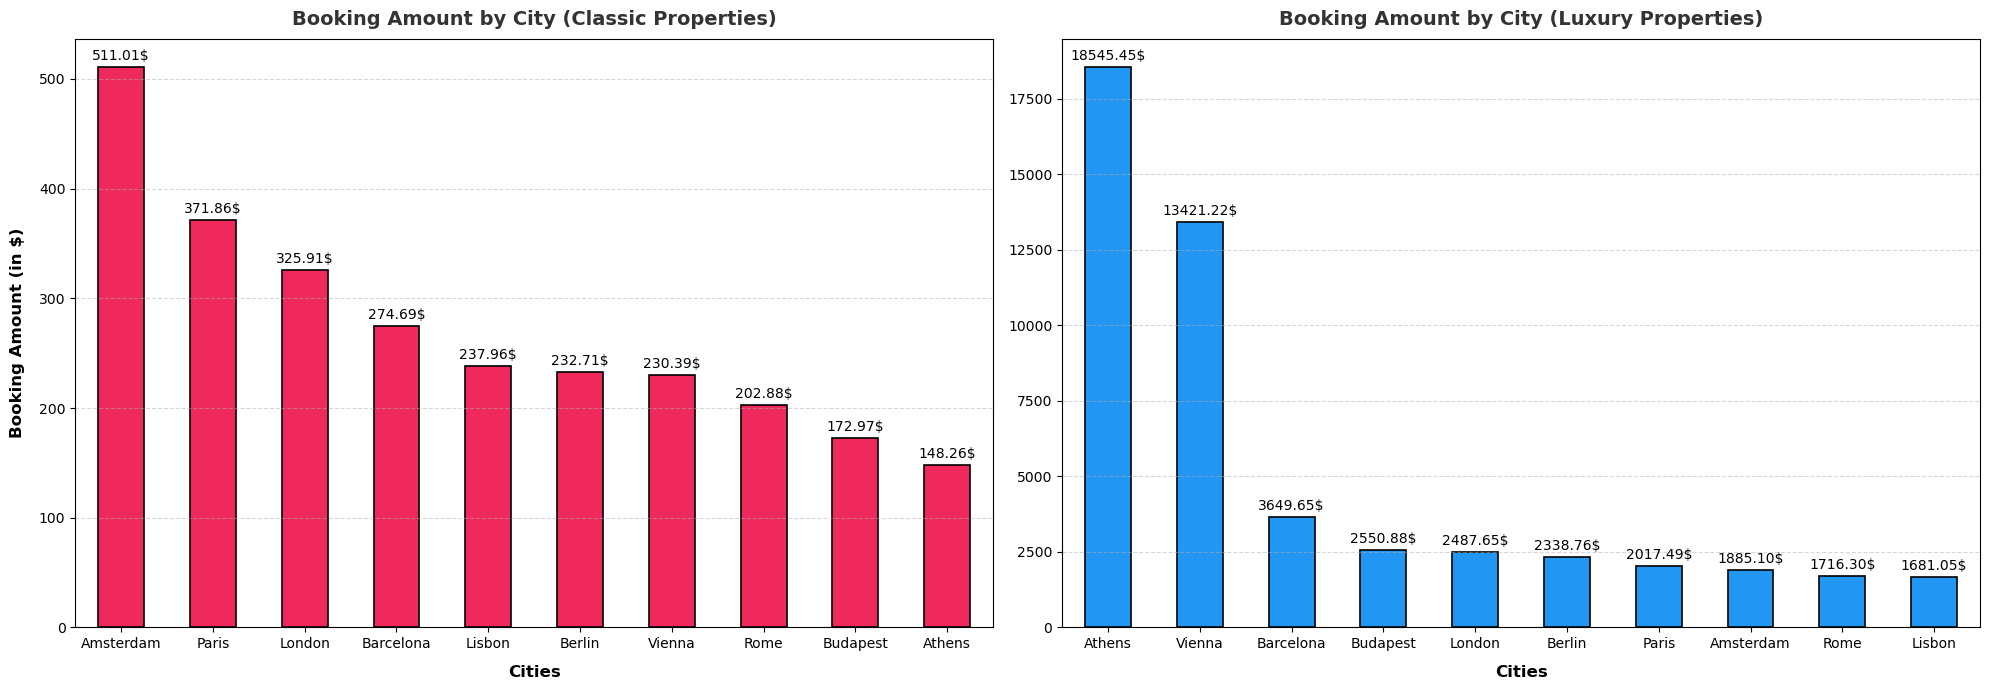

In [29]:
# 1. Booking Amount by City
# Calculate average booking amount by city
classic_avg_booking_by_city = classic_props_df.groupby('cities')['booking_amount'].mean()
luxury_avg_booking_by_city = luxury_props_df.groupby('cities')['booking_amount'].mean()

# Sort the values in descending order
classic_avg_booking_by_city = classic_avg_booking_by_city.sort_values(ascending=False)
luxury_avg_booking_by_city = luxury_avg_booking_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_avg_booking_by_city,
    ax=axes[0],
    title='Booking Amount by City (Classic Properties)',
    xlabel='Cities',
    ylabel='Booking Amount (in $)',
    color='#ef295c'
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_avg_booking_by_city,
    ax=axes[1],
    title='Booking Amount by City (Luxury Properties)',
    xlabel='Cities',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"{i.get_height():.2f}$",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Booking Amount by City ⚛
    - Classic Properties
    The positioning for classic properties indicates that `Amsterdam`, `Paris`, and `London` are strong performers, while Athens and Budapest offer more budget-friendly alternatives.
    
    - Luxury Properties
    In the luxury market, `Athens` and `Vienna` present significant potential for premium offerings, with significantly elevated booking rates compared to other locations.
    Meanwhile, cities like `Paris` and `Amsterdam`, which are usually classified as high-cost.

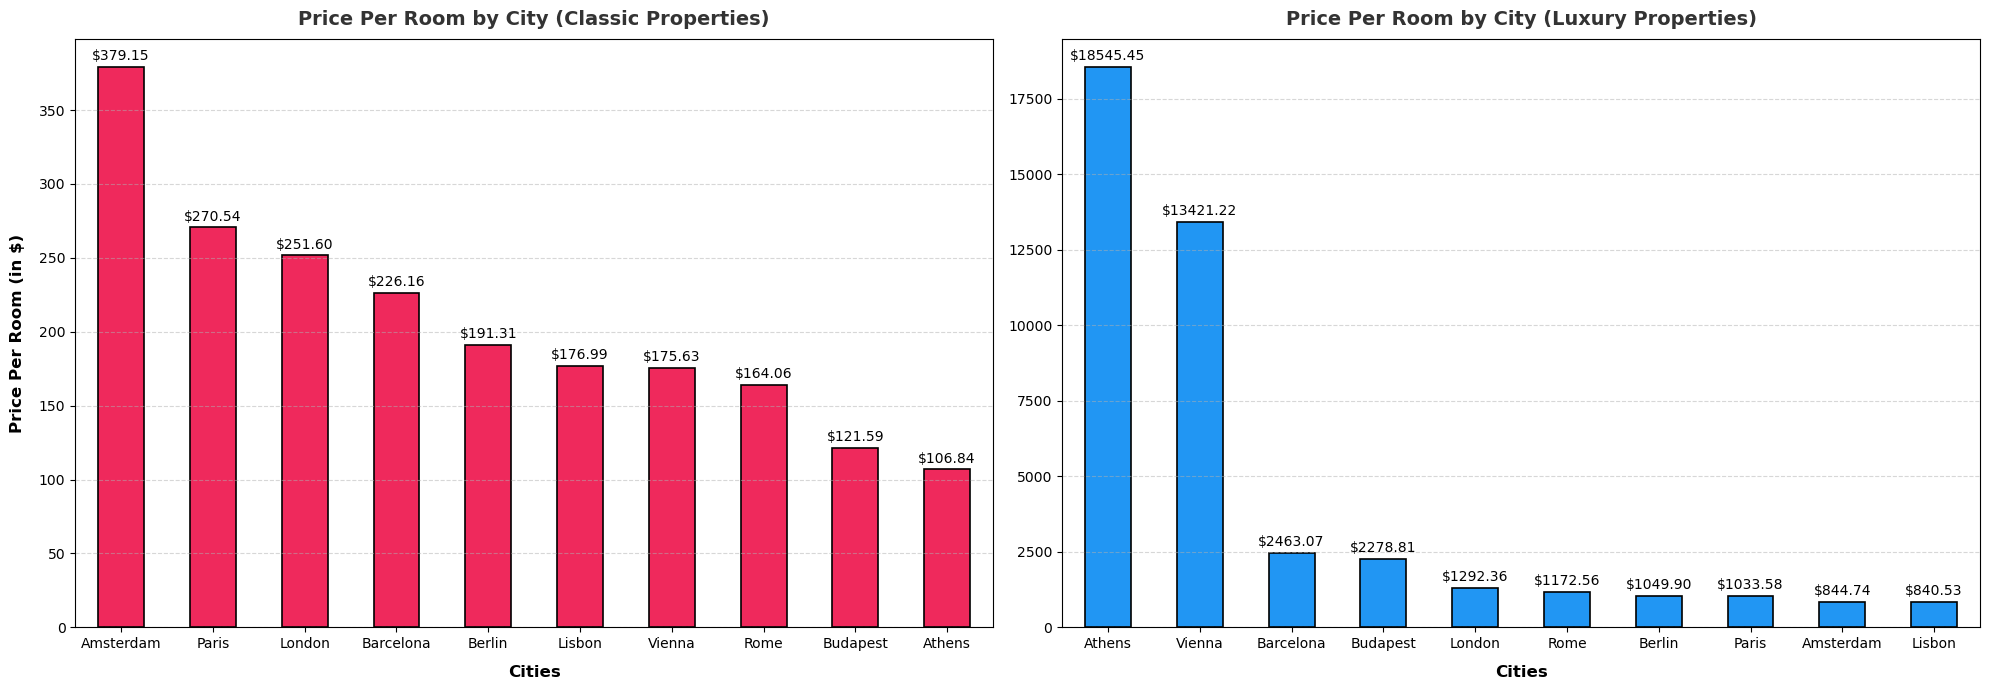

In [31]:
# 2. Price per room by City
# Calculate average price_per_room by city
classic_city_avg_price_per_room = classic_props_df.groupby('cities')['price_per_room'].mean()
luxury_city_avg_price_per_room = luxury_props_df.groupby('cities')['price_per_room'].mean()

# Sort the values in descending order
classic_city_avg_price_per_room = classic_city_avg_price_per_room.sort_values(ascending=False)
luxury_city_avg_price_per_room = luxury_city_avg_price_per_room.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_city_avg_price_per_room,
    ax=axes[0],
    title='Price Per Room by City (Classic Properties)',
    xlabel='Cities',
    ylabel='Price Per Room (in $)',
    color='#ef295c'
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_city_avg_price_per_room,
    ax=axes[1],
    title='Price Per Room by City (Luxury Properties)',
    xlabel='Cities',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Price per room by City ⚛
    - For Classic Properties
    `Amsterdam` has reaffirmed its position with the highest booking prices for classic properties.
    The results support previous assessments, indicating no notable changes.
    
    - For Luxury Properties
    `Athens` and `Vienna` continue to hold the top positions for the highest booking prices for luxury properties, maintaining the exact previous rankings.
    The results support previous assessments, indicating no notable changes.
    This leads to the conclusion that room size could impact the booking amounts.

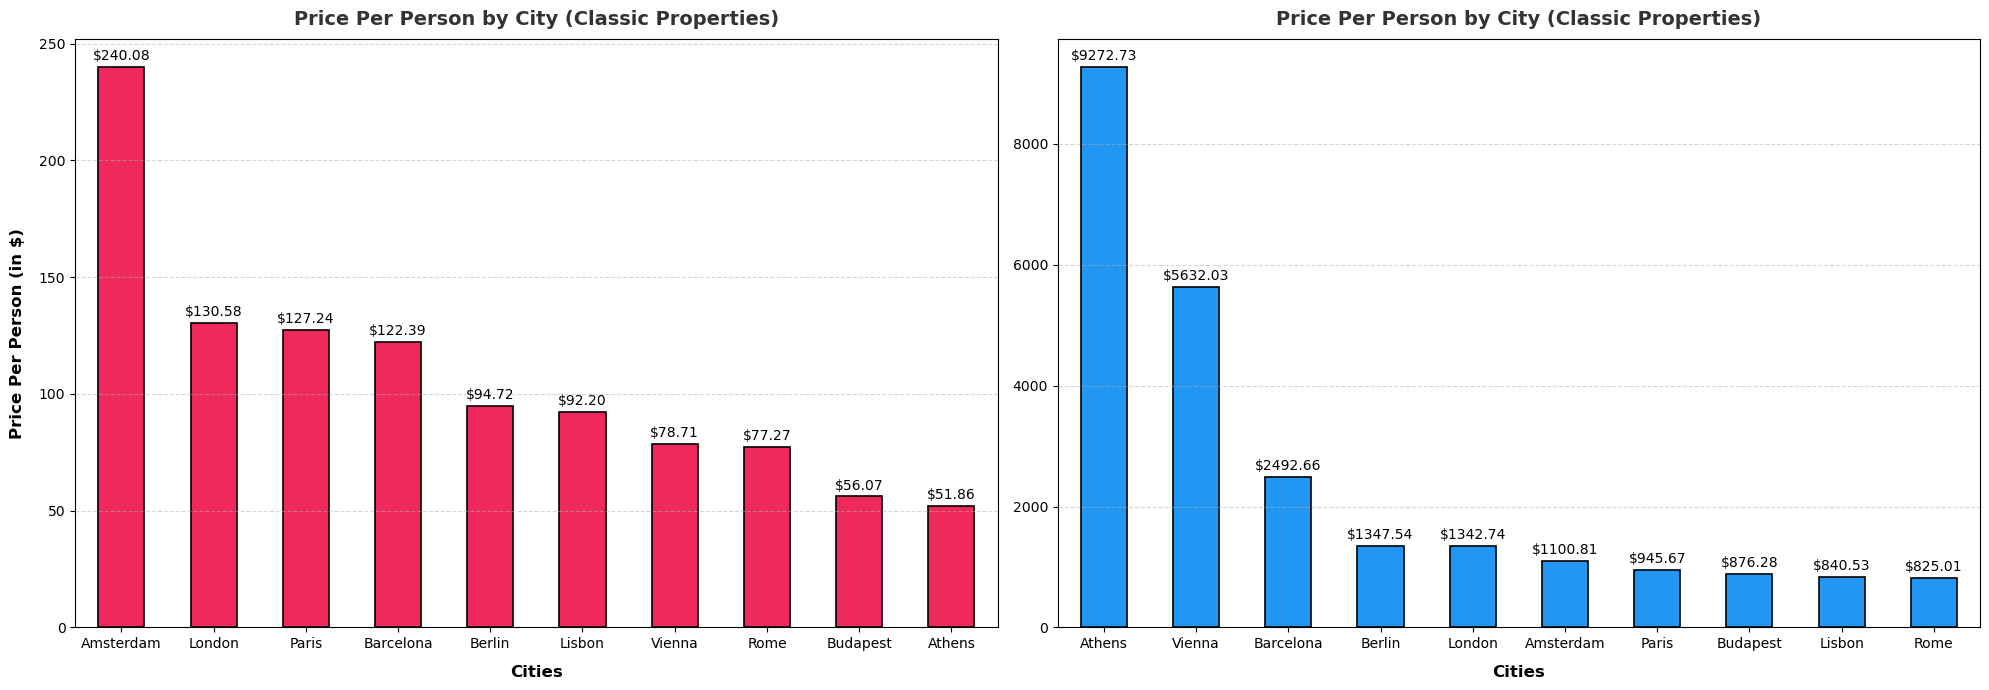

In [33]:
# 3. Price per person by City
# Calculate average price_per_person by city
classic_city_avg_price_per_person = classic_props_df.groupby('cities')['price_per_person'].mean()
luxury_city_avg_price_per_person = luxury_props_df.groupby('cities')['price_per_person'].mean()

# Sort the values in descending order
classic_city_avg_price_per_person = classic_city_avg_price_per_person.sort_values(ascending=False)
luxury_city_avg_price_per_person = luxury_city_avg_price_per_person.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_city_avg_price_per_person,
    ax=axes[0],
    title='Price Per Person by City (Classic Properties)',
    xlabel='Cities',
    ylabel='Price Per Person (in $)',
    color='#ef295c'
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_city_avg_price_per_person,
    ax=axes[1],
    title='Price Per Person by City (Classic Properties)',
    xlabel='Cities',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ OVERALL CONCLUSION : MARKET POSITIONING ⚛
    
	• `Luxury` vs. `Classic`: Luxury properties consistently command significantly higher prices compared to classic properties, indicating a clear market segmentation based on price and experience.
    • City Variation: While certain cities consistently rank high in terms of average prices (e.g., Athens, Vienna for luxury; Amsterdam for classic), there are variations within each category, suggesting that local market dynamics and property-specific factors also play a role.
    • Pricing Drivers: Factors such as `property type`, `property size`, `person capacity`, likely influence pricing in both classic and luxury segments.


### **Satisfaction Analysis**
This analysis evaluates guest satisfaction and cleanliness ratings to compare experiences across different locations.

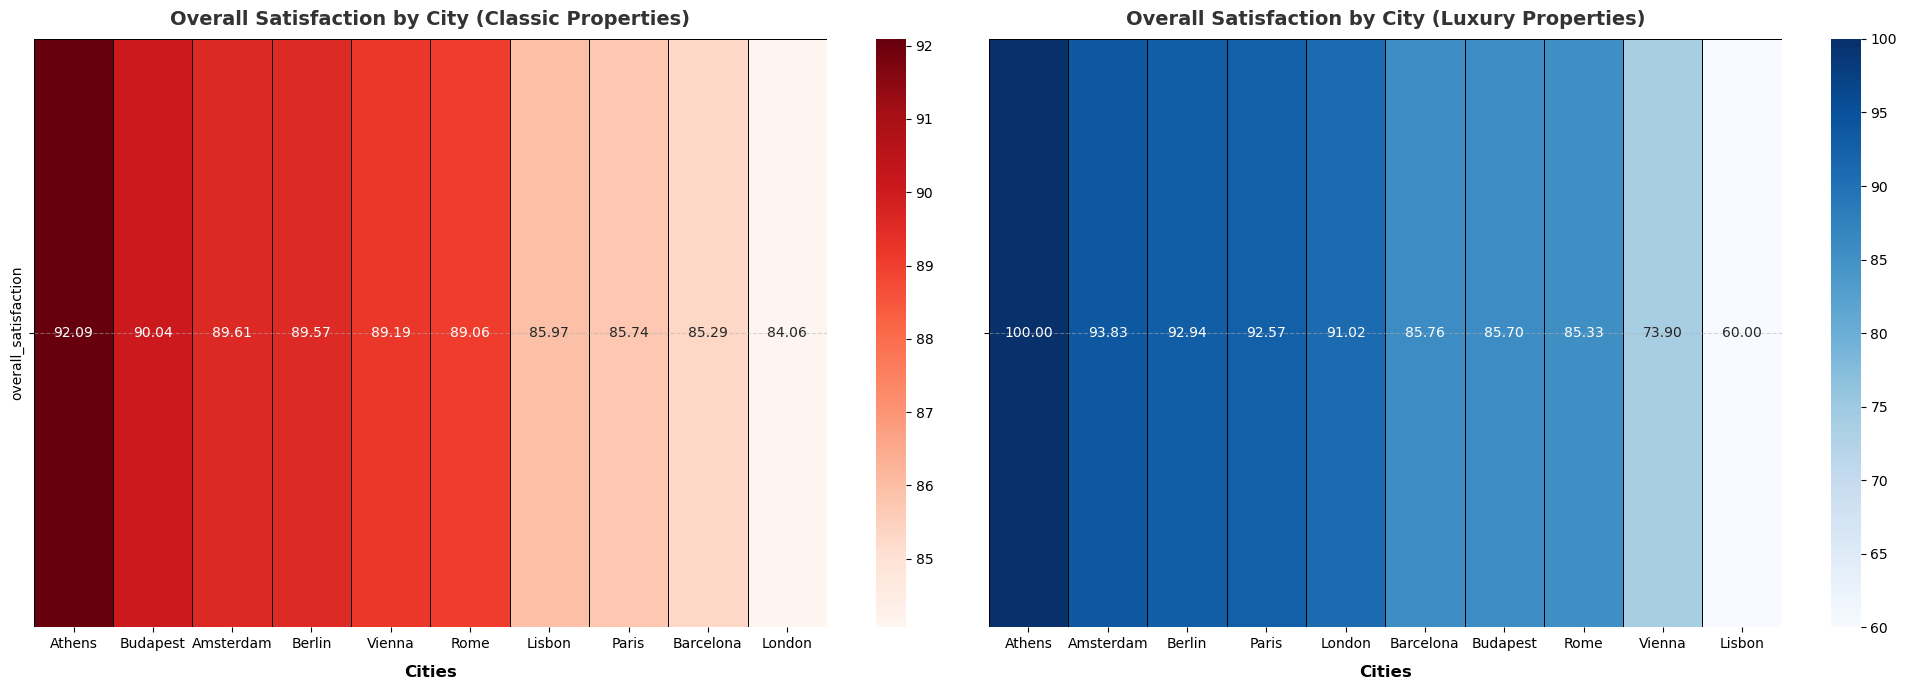

In [36]:
# 1. Overall satisfaction by City
# Calculate average overall satisfaction by city
classic_avg_overall_satisfaction = classic_props_df.groupby('cities')['overall_satisfaction'].mean().reset_index()
luxury_avg_overall_satisfaction = luxury_props_df.groupby('cities')['overall_satisfaction'].mean().reset_index()

# Sort by overall satisfaction for heatmap display
classic_avg_overall_satisfaction = classic_avg_overall_satisfaction.sort_values(by='overall_satisfaction', ascending=False)
luxury_avg_overall_satisfaction = luxury_avg_overall_satisfaction.sort_values(by='overall_satisfaction', ascending=False)

# Set 'cities' as the index for the sorted DataFrame before pivoting
classic_avg_overall_satisfaction_pivot = classic_avg_overall_satisfaction.set_index('cities').T
luxury_avg_overall_satisfaction_pivot = luxury_avg_overall_satisfaction.set_index('cities').T

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot for Classic Properties
plot_heatmap(
    data=classic_avg_overall_satisfaction_pivot,
    ax=axes[0],
    title='Overall Satisfaction by City (Classic Properties)',
    xlabel='Cities',
    palette='Reds'
)

# Plot for Luxury Properties
plot_heatmap(
    data=luxury_avg_overall_satisfaction_pivot,
    ax=axes[1],
    title='Overall Satisfaction by City (Luxury Properties)',
    xlabel='Cities',
    palette='Blues'
)

# Tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Overall Satisfaction by City ⚛
    - For Classic Properties
    `Athens` and `Budapest` provide the most fulfilling experiences for guests.
    In contrast, `London`, `Paris`, and `Barcelona`, despite their elevated booking costs, generally receive lower satisfaction ratings.
    Although there are differences among the cities, classic properties tend to maintain relatively high overall satisfaction levels.

    - For Luxury Properties ⚛
    `Athens` stands out with the highest satisfaction score for luxury properties across all cities.
    Meanwhile, `Vienna` and `Lisbon` report significantly lower scores.
    This trend in `Lisbon` could be associated with its position as the area with the lowest booking prices.
    
    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


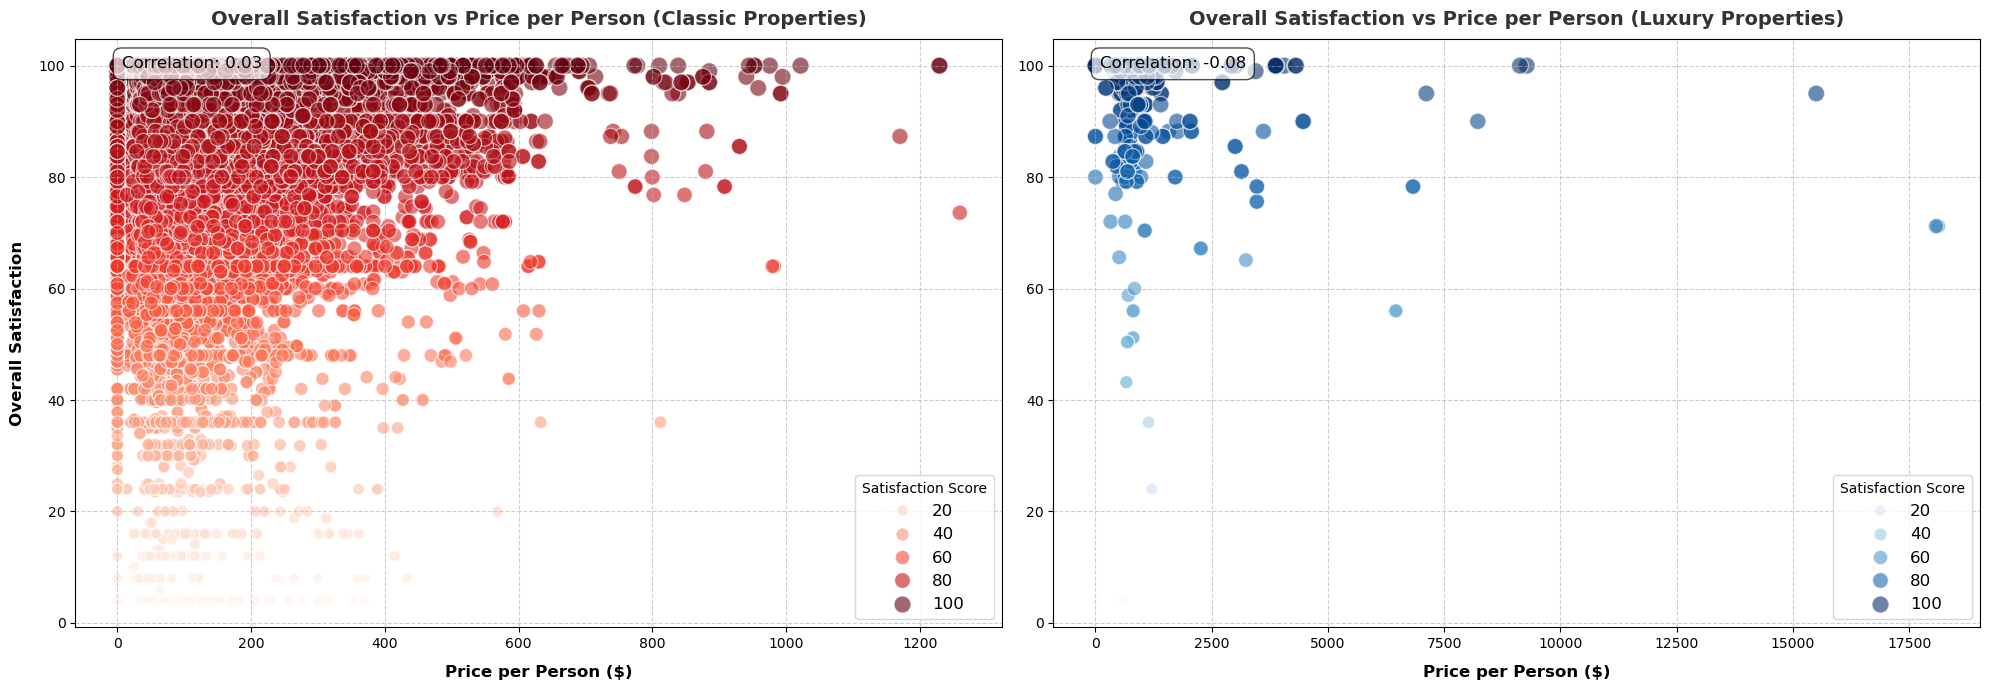

In [38]:
# 2. Correlation Overall satisfaction and Price Per Person
# Calculate correlations
correlation_classic = classic_props_df['overall_satisfaction'].corr(classic_props_df['price_per_person'])
correlation_luxury = luxury_props_df['overall_satisfaction'].corr(luxury_props_df['price_per_person'])

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_scatter(
    x = 'price_per_person',
    y = 'overall_satisfaction',
    data=classic_props_df,
    correlation=correlation_classic,
    ax=axes[0],
    palette='Reds',
    hue='overall_satisfaction',
    size='overall_satisfaction',
    title='Overall Satisfaction vs Price per Person (Classic Properties)',
    xlabel='Price per Person ($)',
    ylabel='Overall Satisfaction',
    legend_loc='lower right',
    legend_title='Satisfaction Score'
)
# Adjust legend position and size
plt.legend(title='Satisfaction Score', loc='upper right', fontsize=10)

# Plot for Luxury Properties
plot_scatter(
    x = 'price_per_person',
    y = 'overall_satisfaction',
    data=luxury_props_df,
    correlation=correlation_luxury,
    ax=axes[1],
    palette='Blues',
    hue='overall_satisfaction',
    size='overall_satisfaction',
    title='Overall Satisfaction vs Price per Person (Luxury Properties)',
    xlabel='Price per Person ($)',
    legend_loc='lower right',
    legend_title='Satisfaction Score'
)

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Overall Satisfaction vs Price per person ⚛
    In the both cases, there is no linear relationship between the overall satisfaction and booking amount.

    ⚛ OVERALL CONCLUSION : SATISFACTION ANALYSIS ⚛
    
	• Guest Satisfaction: Guests express a high level of satisfaction with both classic and luxury accommodations, as reflected in their generally favorable satisfaction ratings.
    • City: Satisfaction scores do vary by city; however, there is no consistent trend showing that certain cities consistently excel in overall satisfaction.
    • Property Type: The overall satisfaction levels between classic and luxury properties are comparable, indicating that both types can deliver high guest satisfaction.
    • Cleanliness:  A key determinant of satisfaction is cleanliness, with properties that uphold high cleanliness standards generally earning higher satisfaction scores.
    • Price: There is no strong relationship between the price and overall satisfaction for either classic or luxury properties, suggesting that other elements are more influential in determining guest satisfaction.

### **Room Capacity Analysis**
This analysis focuses on the types of properties available to understand how they may affect accommodation choices.

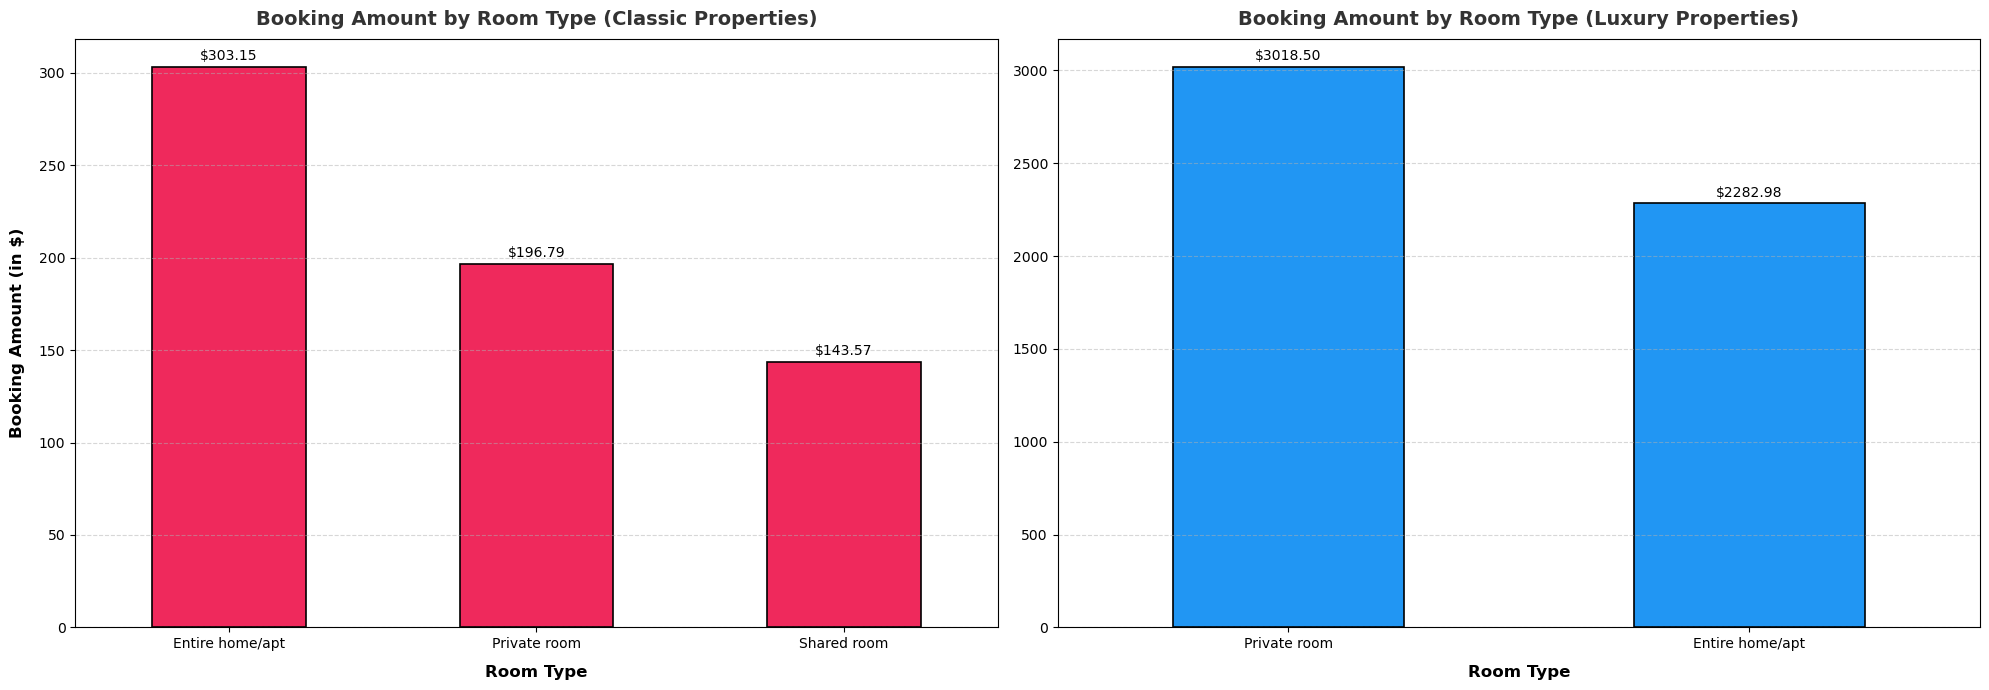

In [42]:
# 1. Booking Amount by Room Type
# Calculate average booking amount by room type
classic_room_type_avg_booking = classic_props_df.groupby('room_type')['booking_amount'].mean()
luxury_room_type_avg_booking = luxury_props_df.groupby('room_type')['booking_amount'].mean()

# Sort the values in descending order
classic_room_type_avg_booking = classic_room_type_avg_booking.sort_values(ascending=False)
luxury_room_type_avg_booking = luxury_room_type_avg_booking.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_room_type_avg_booking,
    ax=axes[0],
    title='Booking Amount by Room Type (Classic Properties)',
    xlabel='Room Type',
    ylabel='Booking Amount (in $)',
    color='#ef295c'
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_room_type_avg_booking,
    ax=axes[1],
    title='Booking Amount by Room Type (Luxury Properties)',
    xlabel='Room Type',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Booking Amount by Room Type ⚛
    - For Classic Properties
    Among the various room types, `Entire home/apt` stands out with the highest prices.
    `Shared room` records the lowest average booking amount.
    
    - For Luxury Properties ⚛
    There a no shared room in the luxury properties type.
    Unlike the classic properties, Private room has the highest prices.

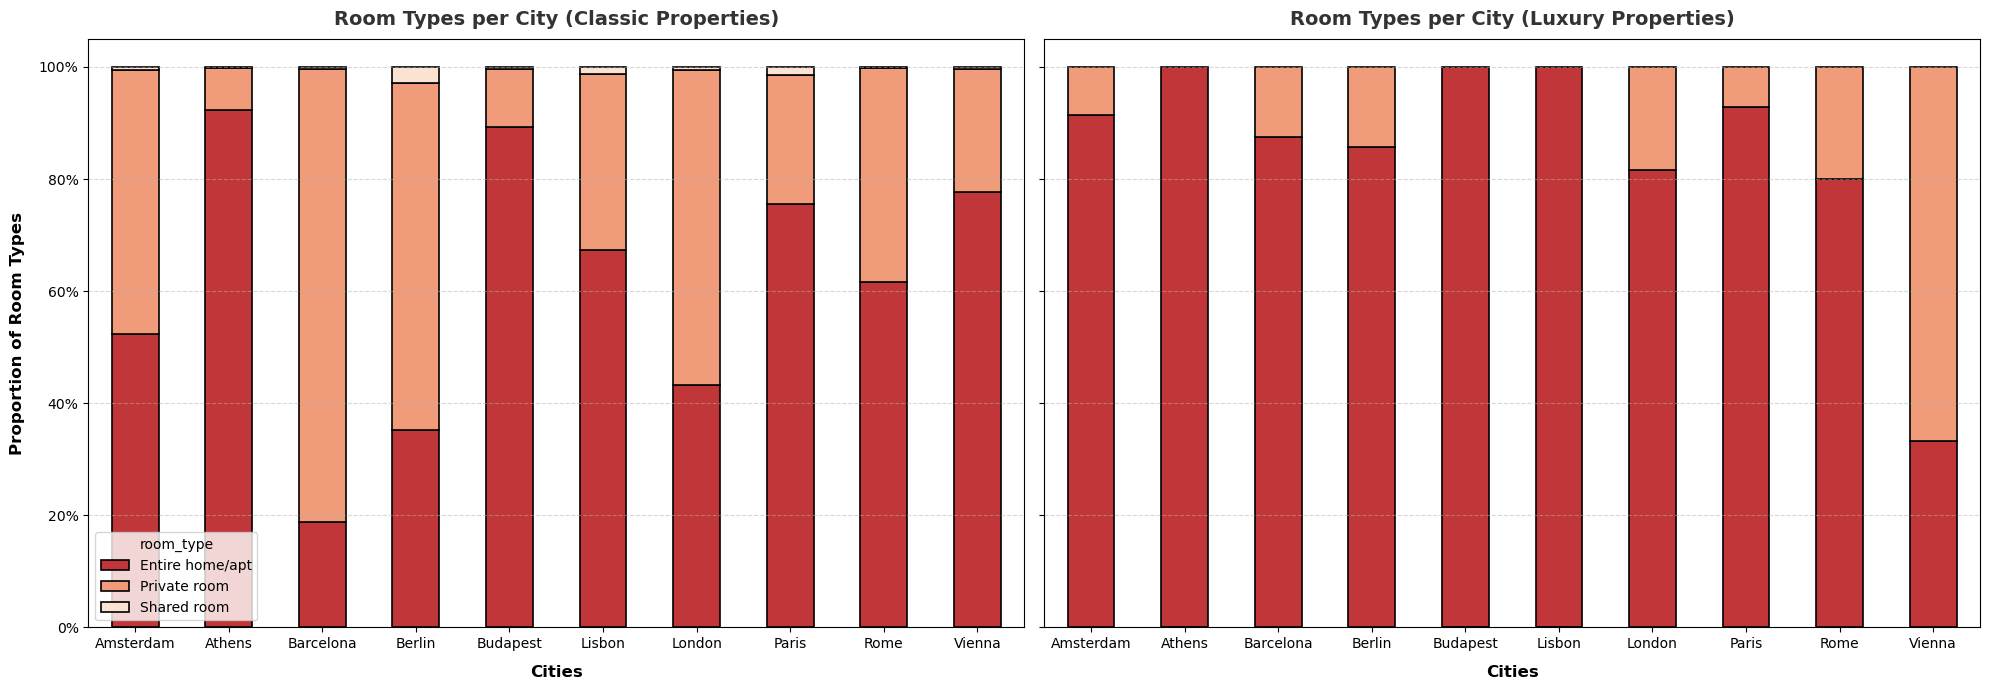

In [44]:
# 2. Room Type per City
# Helper function to compute proportions of room types per city
def get_room_type_proportions(df):
    """Group by city and room type, calculate the proportion of room types for each city."""
    room_type_by_city = df.groupby(['cities', 'room_type'])['room_type'].count().unstack()
    room_type_proportion = room_type_by_city.div(room_type_by_city.sum(axis=1), axis=0)
    return room_type_proportion

# Get the proportions for classic and luxury properties
room_type_by_city_classic = get_room_type_proportions(classic_props_df)
room_type_by_city_luxury = get_room_type_proportions(luxury_props_df)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot: Proportion of Room Types for Classic Properties
plot_bar(
    data=room_type_by_city_classic,
    ax=axes[0],
    title='Room Types per City (Classic Properties)',
    xlabel='Cities',
    ylabel='Proportion of Room Types',
    color=sns.color_palette('RdBu'),
    stacked=True
)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))


# Plot: Proportion of Room Types for Luxury Properties
plot_bar(
    data=room_type_by_city_luxury,
    ax=axes[1],
    title='Room Types per City (Luxury Properties)',
    xlabel='Cities',
    ylabel='Proportion of Room Types',
    color=sns.color_palette('RdBu'),
    stacked=True
)
axes[1].get_legend().remove()

# Apply tight layout and display the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Proportion of Room Types Booked per City ⚛
    In the both cases, `Entire home/apt` accommodations remain the dominant force in the market.
    The `Private room` follows as the second most popular choice.

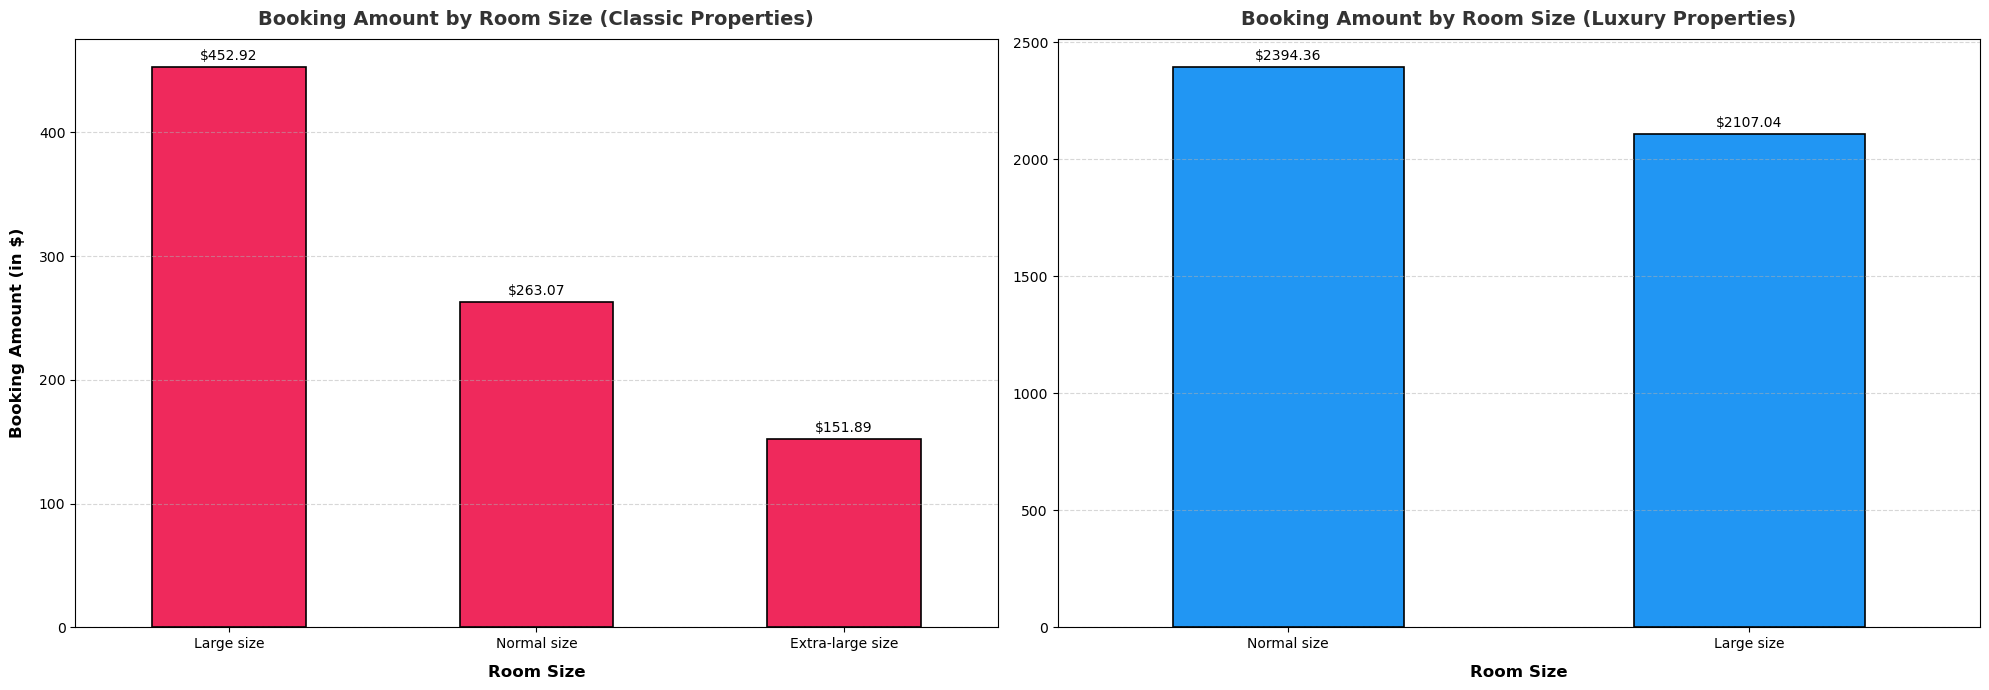

In [46]:
# 3. Booking Amount by Room Size
# Calculate average booking amount by room size
classic_room_size_avg_booking = classic_props_df.groupby('room_size')['booking_amount'].mean()
luxury_room_size_avg_booking = luxury_props_df.groupby('room_size')['booking_amount'].mean()

# Sort the values in descending order
classic_room_size_avg_booking = classic_room_size_avg_booking.sort_values(ascending=False)
luxury_room_size_avg_booking = luxury_room_size_avg_booking.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_room_size_avg_booking,
    ax=axes[0],
    title='Booking Amount by Room Size (Classic Properties)',
    xlabel='Room Size',
    ylabel='Booking Amount (in $)',
    color='#ef295c'
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_room_size_avg_booking,
    ax=axes[1],
    title='Booking Amount by Room Size (Luxury Properties)',
    xlabel='Room Size',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Booking Amount by Room Size ⚛
    - For Classic Properties
    `Normal size` rooms offer a more affordable option compared to `large size` rooms, while `extra-large size` rooms represent the most budget-friendly choice.

    - For Luxury Properties
    The difference in the pricing is not as significant as in classic properties. There is no `extra-large size` rooms in luxury properties.

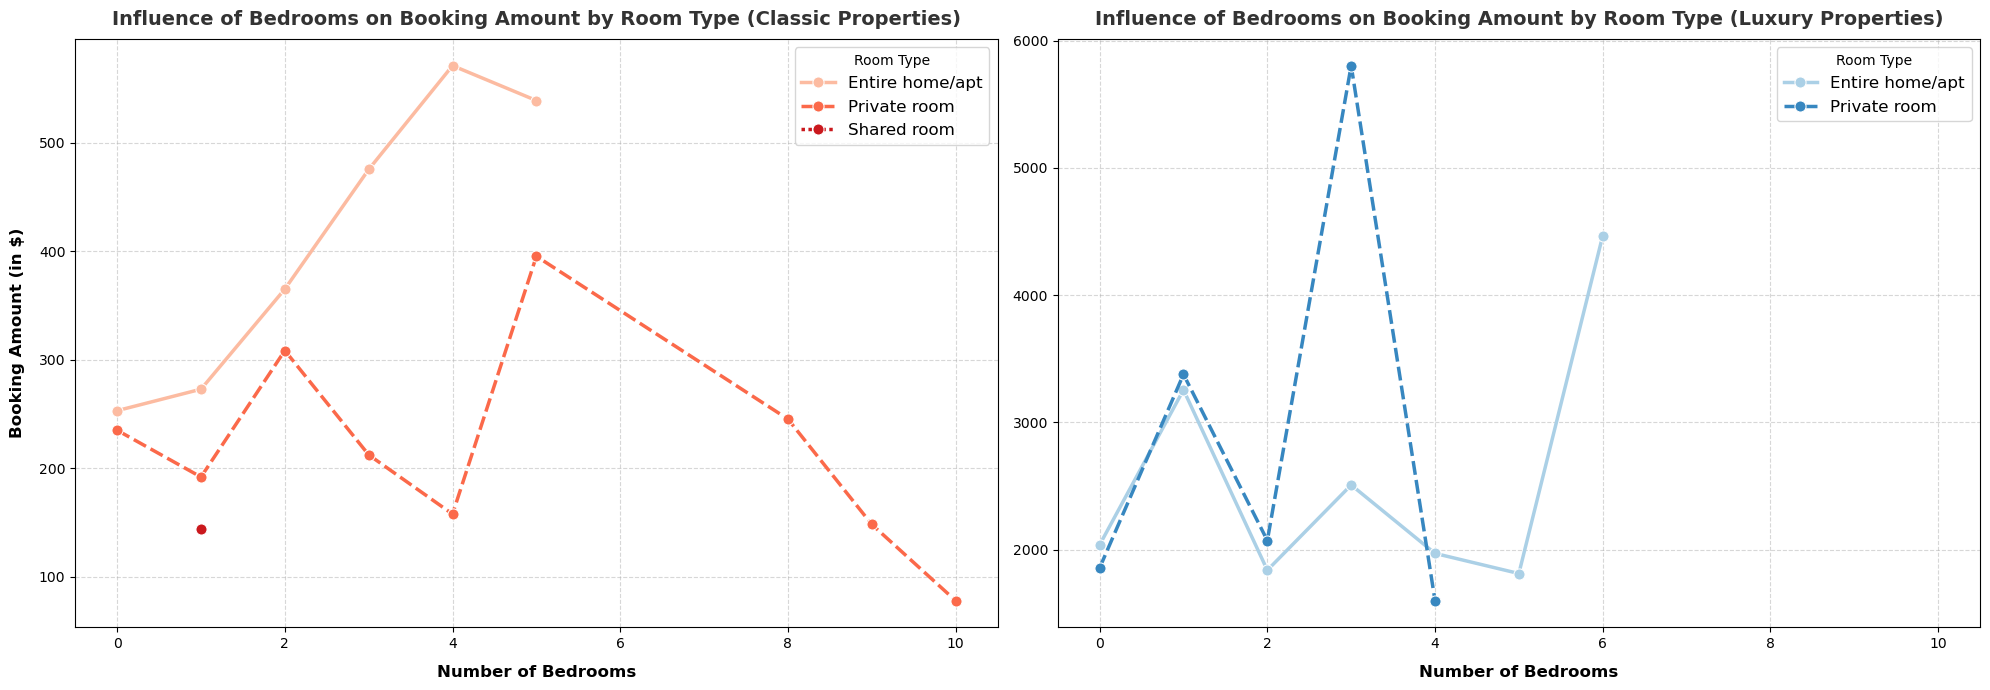

In [48]:
# 4. Influence of Bedrooms on Booking Amount by Room Type
# Group by room type and bedrooms, then calculate the average booking amount
classic_room_size_booking_amount = (
    classic_props_df.groupby(['room_type', 'bedrooms'])['booking_amount']
    .mean().reset_index()
)

luxury_room_size_booking_amount = (
    luxury_props_df.groupby(['room_type', 'bedrooms'])['booking_amount']
    .mean().reset_index()
)

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=True)

# Plot for Classic Properties
plot_line(
    data=classic_room_size_booking_amount,
    ax=axes[0],
    title='Influence of Bedrooms on Booking Amount by Room Type (Classic Properties)',
    xlabel='Number of Bedrooms',
    ylabel='Booking Amount (in $)',
    palette='Reds',
    style='room_type',
    x='bedrooms',
    y='booking_amount',
    hue='room_type',
    legend_title='Room Type',
    legend_loc='upper right',
    marker='o'
)

# Plot for Luxury Properties
plot_line(
    data=luxury_room_size_booking_amount,
    ax=axes[1],
    title='Influence of Bedrooms on Booking Amount by Room Type (Luxury Properties)',
    xlabel='Number of Bedrooms',
    palette='Blues',
    style='room_type',
    x='bedrooms',
    y='booking_amount',
    hue='room_type',
    legend_title='Room Type',
    legend_loc='upper right',
    marker='o'
)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

    ⚛ Observations of Influence of Bedrooms on Booking Amount ⚛
    - For Classic Properties
    The pricing for an `Entire home/apt` is heavily influenced by the number of bedrooms available.
    In contrast, the pricing dynamics for `Private rooms` are less apparent, which may imply the presence of other underlying factors affecting this scenario.

    - For Luxury Properties
    There is no clear relationship between the price and the number of bedrooms.
    This indicates that some other factors influence this scenario.

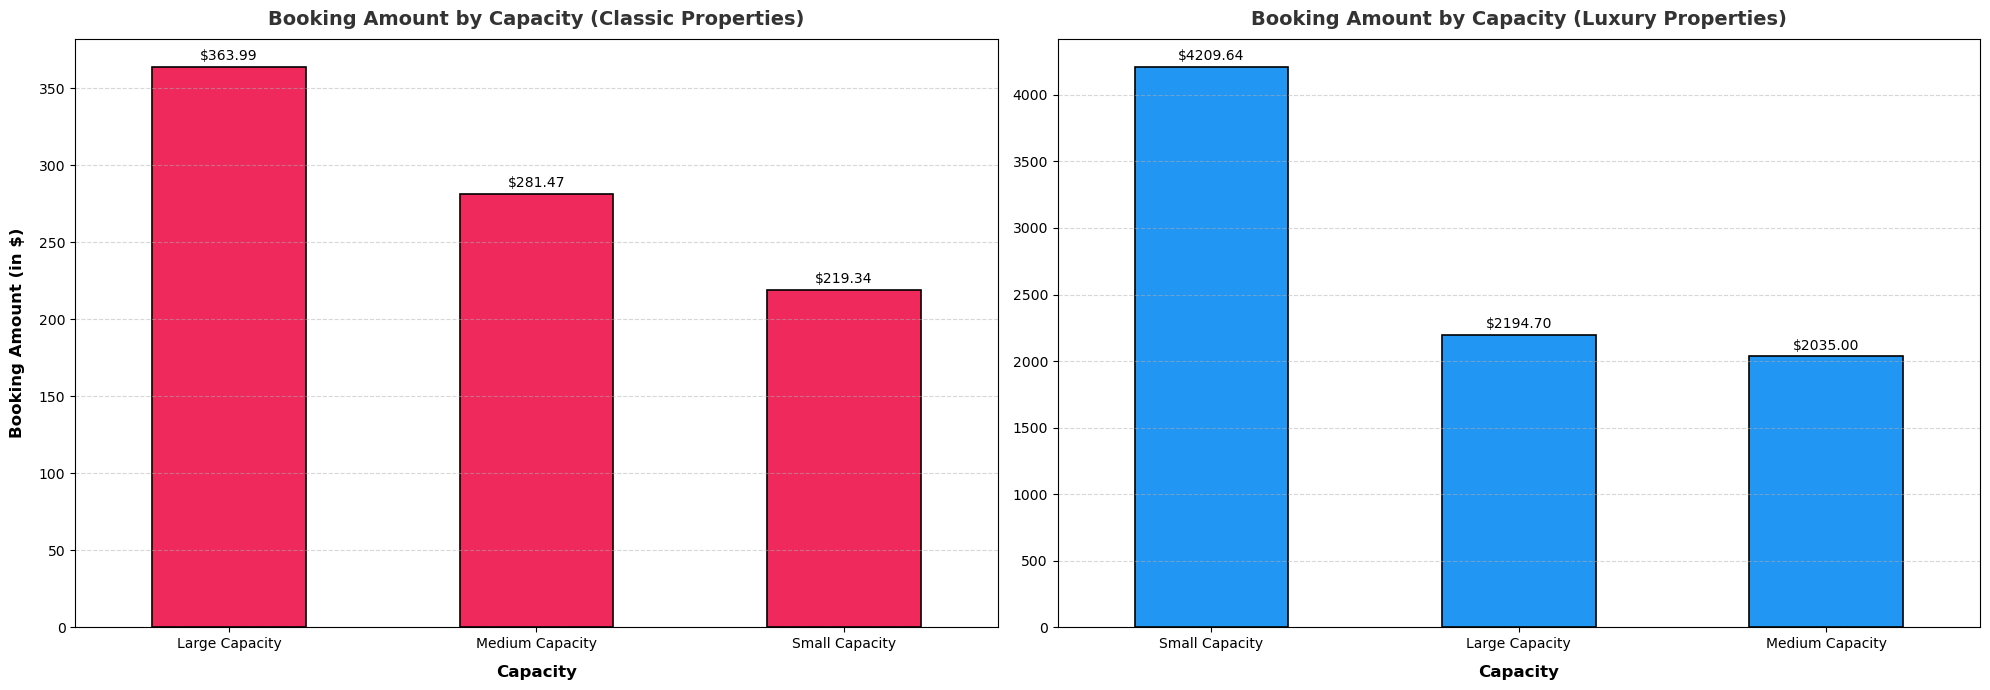

In [50]:
# 5. Booking Amount by Capacity
# Calculate average booking amount by capacity
classic_capacity_avg_booking = classic_props_df.groupby('capacity')['booking_amount'].mean()
luxury_capacity_avg_booking = luxury_props_df.groupby('capacity')['booking_amount'].mean()

# Sort the values in descending order
classic_capacity_avg_booking = classic_capacity_avg_booking.sort_values(ascending=False)
luxury_capacity_avg_booking = luxury_capacity_avg_booking.sort_values(ascending=False)

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_capacity_avg_booking,
    ax=axes[0],
    title='Booking Amount by Capacity (Classic Properties)',
    xlabel='Capacity',
    ylabel='Booking Amount (in $)',
    color='#ef295c',
)

# Plot for Luxury Properties
plot_bar(
    data=luxury_capacity_avg_booking,
    ax=axes[1],
    title='Booking Amount by Capacity (Luxury Properties)',
    xlabel='Capacity',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

	⚛ Observations of Booking Amount by Capacity ⚛
    - For Classic Properties
    `Large Capacity` properties have the highest booking amount.
    `Small Capacity` properties represent the most budget-friendly choice.

    - For Luxury Properties ⚛
    Contrary to Classic Properties, `Small Capacity` command the highest booking prices among luxury offerings.
    `Large Capacity` and `Medium Capacity` properties have approximately the same pricing and the most economical choice available.

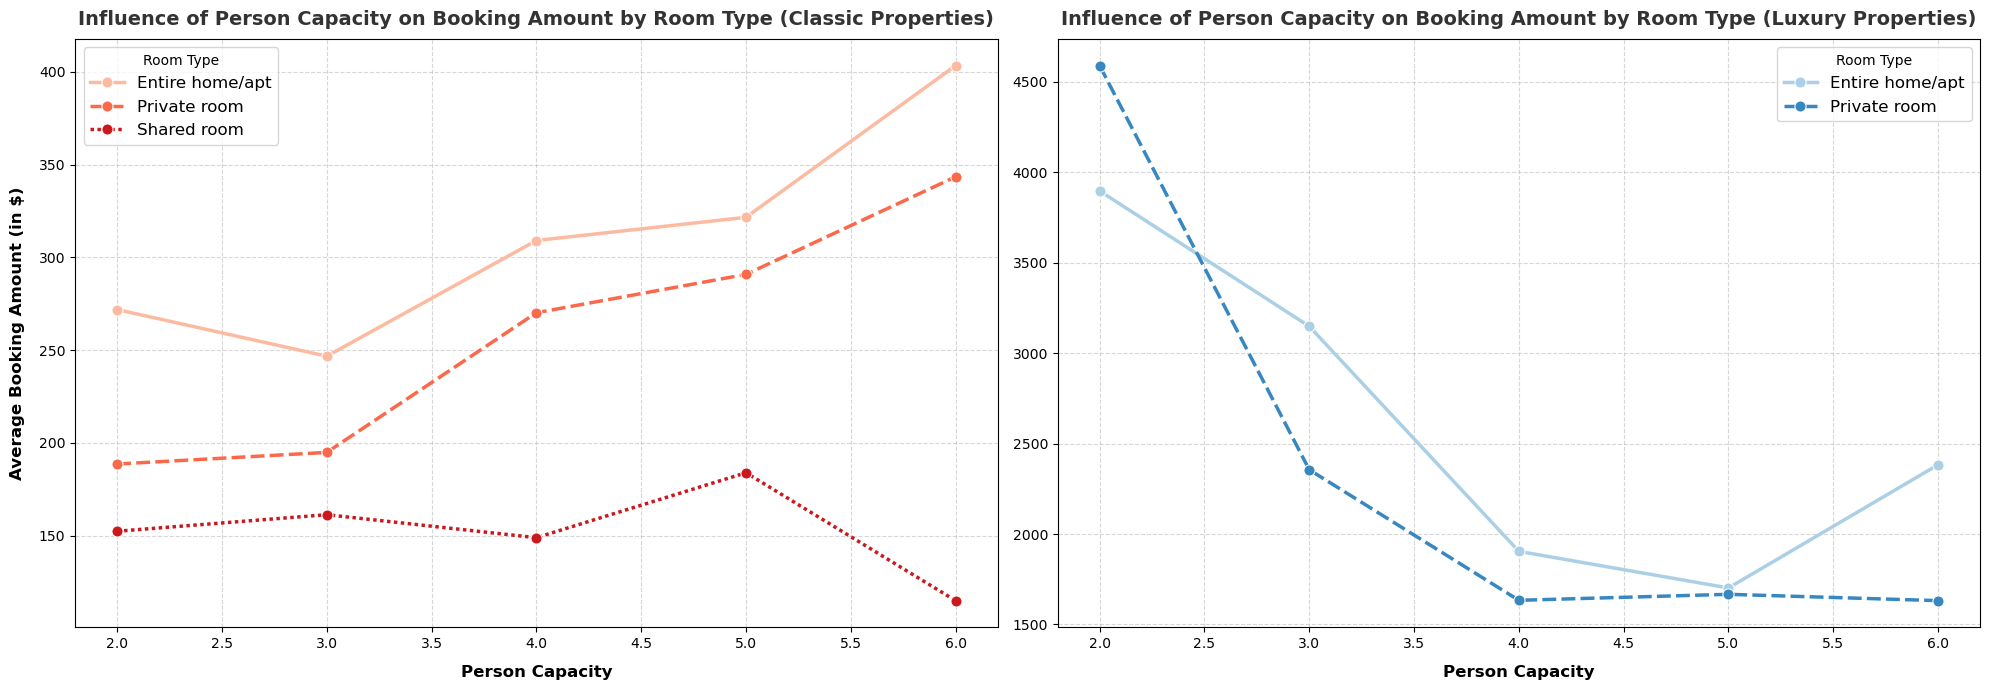

In [52]:
# 6. Influence of Person Capacity on Booking Amount by Room Type
# Group by room type and person capacity, then calculate the average booking amount
classic_capacity_booking_amount = classic_props_df.groupby(['room_type', 'person_capacity'])['booking_amount'].mean().reset_index()
luxury_capacity_booking_amount = luxury_props_df.groupby(['room_type', 'person_capacity'])['booking_amount'].mean().reset_index()

# Create the figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharex=True)

# Plot for Classic Properties
plot_line(
    data=classic_capacity_booking_amount,
    ax=axes[0],
    title='Influence of Person Capacity on Booking Amount by Room Type (Classic Properties)',
    xlabel='Person Capacity',
    ylabel='Average Booking Amount (in $)',
    palette='Reds',
    style='room_type',
    x='person_capacity',
    y='booking_amount',
    hue='room_type',
    legend_title='Room Type',
    legend_loc='upper left',
    marker='o'
)

# Plot for Luxury Properties
plot_line(
    data=luxury_capacity_booking_amount,
    ax=axes[1],
    title='Influence of Person Capacity on Booking Amount by Room Type (Luxury Properties)',
    xlabel='Person Capacity',
    palette='Blues',
    style='room_type',
    x='person_capacity',
    y='booking_amount',
    hue='room_type',
    legend_title='Room Type',
    legend_loc='upper right',
    marker='o'
)

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

	⚛ Observations of Influence of Person Capacity on Booking Amount by Room Type ⚛
    - For Classic Properties
    `Entire home/apt` and `Private Room` has a considerable positive effect, revealing that guests are willing to spend more on properties that can host a larger number of individuals.

    - For Luxury Properties
    `person capacity` negatively impacts the booking figures for both `Entire home/apt` and `Private room` luxury accommodations.
    This trend suggests that guests are inclined to spend more on smaller, more exclusive luxury properties.

    ⚛ OVERALL CONCLUSION : ROOM CAPACITY ANALYSIS ⚛  

    • Room Size: Generally, `larger size` rooms tend to attract higher booking rates, particularly in classic properties.
    • Room Type: Properties that offer `Entire home/apt` are the most appreciated by guests compared to `Private rooms`, especially in luxury properties.
    • Person Capacity: In classic properties, greater capacity typically leads to increased booking amounts, especially for `Entire home/apt` rentals.
      Conversely, in luxury properties, smaller capacities often result in higher pricing.

### **Superhost Impact Analysis**
This analysis explores the influence of being a superhost on property bookings.

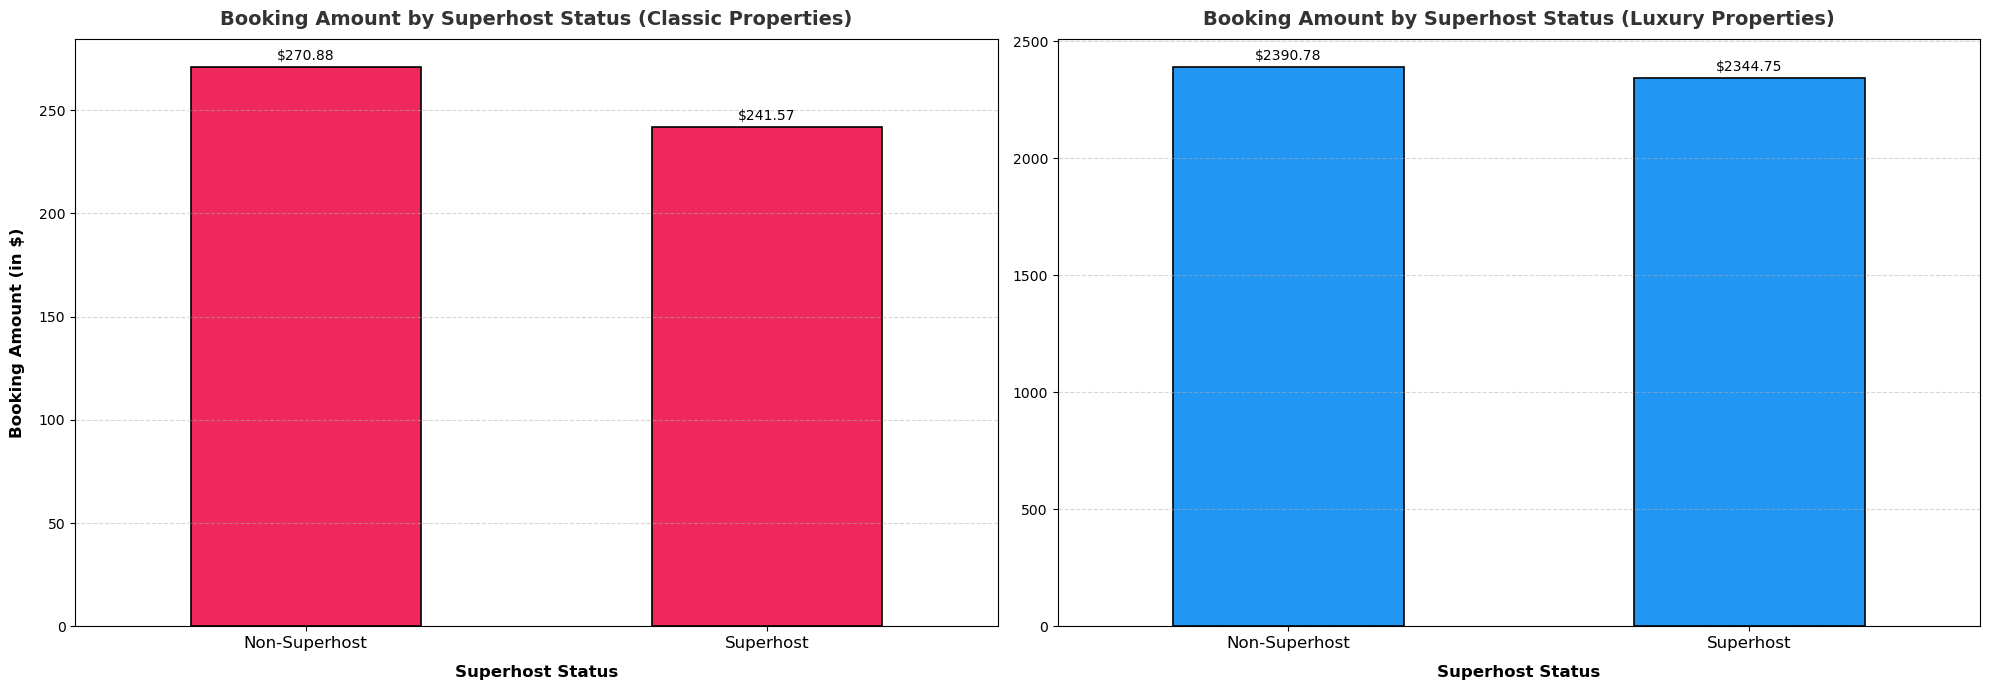

In [56]:
# 1. Booking amount by Superhost Status
# Calculate average booking amount by host_is_superhost
classic_superhost_avg_booking = classic_props_df.groupby('host_is_superhost')['booking_amount'].mean()
luxury_superhost_avg_booking = luxury_props_df.groupby('host_is_superhost')['booking_amount'].mean()

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_superhost_avg_booking,
    ax=axes[0],
    title='Booking Amount by Superhost Status (Classic Properties)',
    xlabel='Superhost Status',
    ylabel='Booking Amount (in $)',
    color='#ef295c',
)

# Set ticks
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0, fontsize=12)

# Plot for Luxury Properties
plot_bar(
    data=luxury_superhost_avg_booking,
    ax=axes[1],
    title='Booking Amount by Superhost Status (Luxury Properties)',
    xlabel='Superhost Status',
    color='#2196f3'
)

# Set ticks
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0, fontsize=12)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Booking amount by superhost status ⚛
    In both scenarios, renting properties managed by a SuperHost offers greater convenience compared to other options.
    

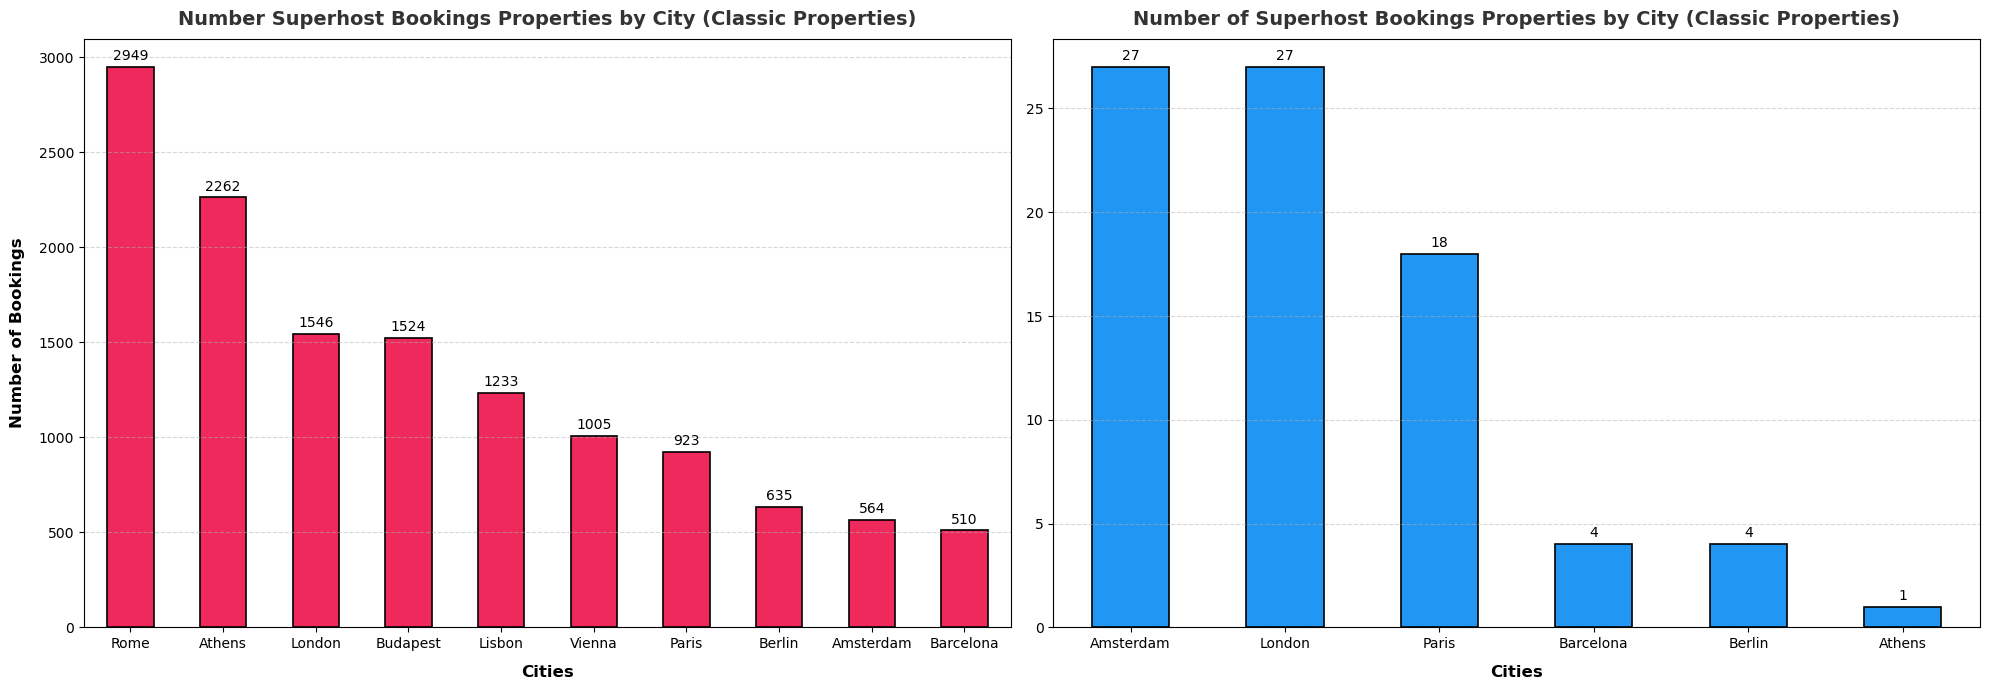

In [58]:
# 2. Number of Properties with a Superhost Status by City
# Filter by superhost
superhost_classic_props = classic_props_df[classic_props_df['host_is_superhost'] == 1]
superhost_luxury_props = luxury_props_df[luxury_props_df['host_is_superhost'] == 1]

# Group by city, and count the number of bookings for Superhost Properties
classic_superhost_bookings_by_city = superhost_classic_props.groupby(['cities'])['host_is_superhost'].count()
luxury_superhost_bookings_by_city = superhost_luxury_props.groupby(['cities'])['host_is_superhost'].count()

# Sort by descending
classic_superhost_bookings_by_city = classic_superhost_bookings_by_city.sort_values(ascending=False)
luxury_superhost_bookings_by_city = luxury_superhost_bookings_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic properties
plot_bar(
    data=classic_superhost_bookings_by_city,
    ax=axes[0],
    title='Number Superhost Bookings Properties by City (Classic Properties)',
    xlabel='Cities',
    ylabel='Number of Bookings',
    color='#ef295c',
)

# Plot for Luxury properties
plot_bar(
    data=luxury_superhost_bookings_by_city,
    ax=axes[1],
    title='Number of Superhost Bookings Properties by City (Classic Properties)',
    xlabel='Cities',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"{i.get_height()}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply the layout and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Number of Properties with a Superhost Status by City ⚛
    - For classic Properties
    Rome and Athens rank highest in the count of properties managed by superhosts. This trend may account for the elevated guest satisfaction and competitive pricing in these cities, especially when compared to Amsterdam.
    - For luxury Properties
    Unlike classic properties, luxury properties in Amsterdam, London, and Paris show a significant number of bookings by superhosts, suggesting that luxury guests tend to have greater confidence in these listings.
    

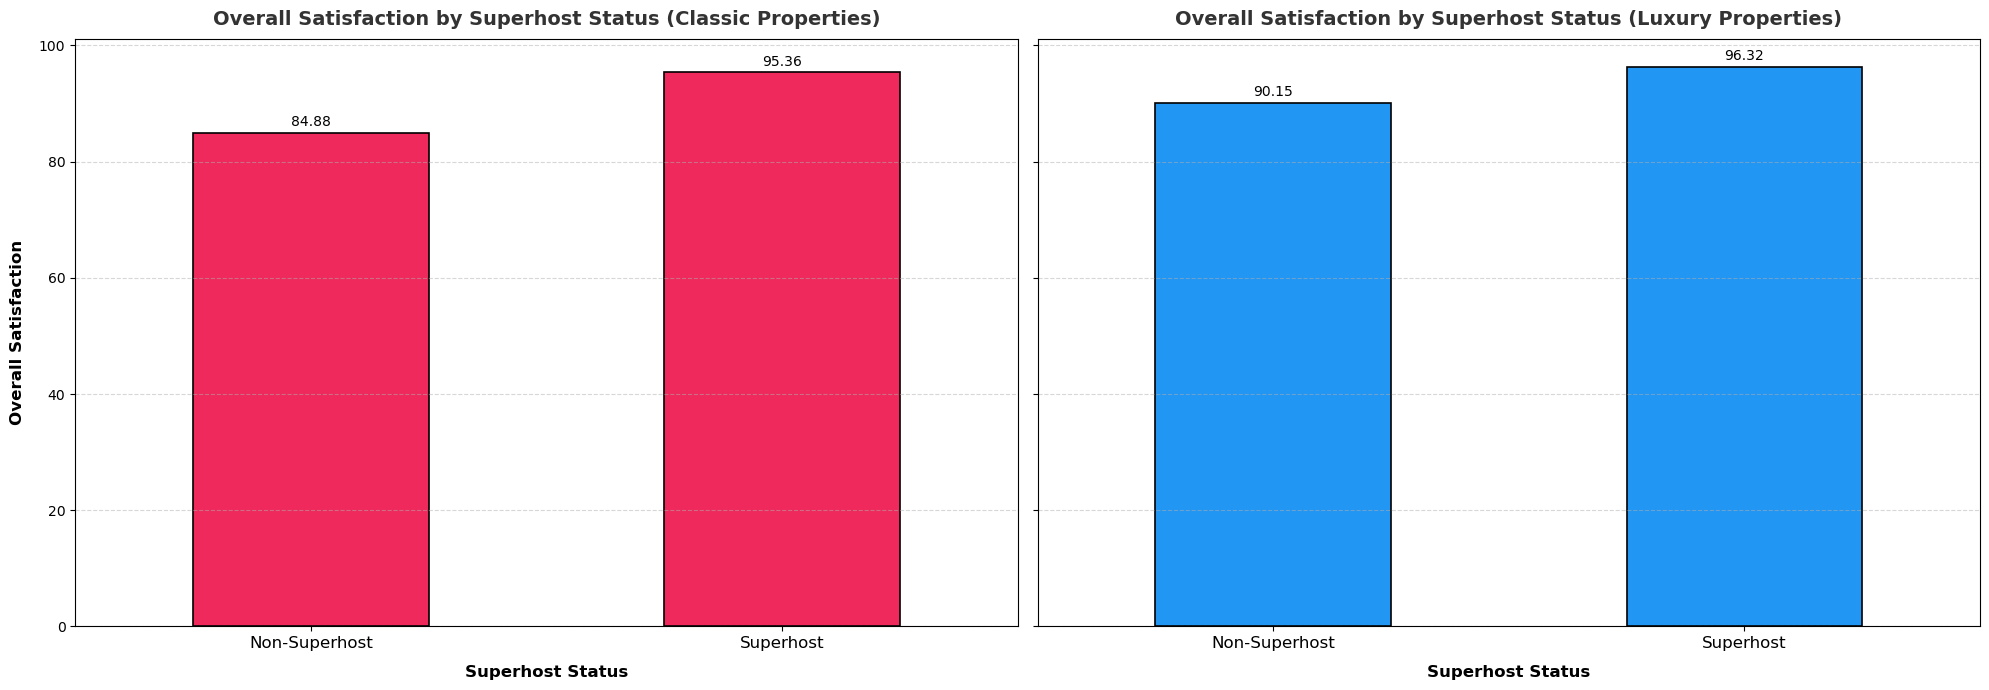

In [60]:
# 3. Overall satisfaction for Superhost Properties
# Group by host_is_superhost and calculate the average overall satisfaction
classic_avg_satisfaction_by_superhost = classic_props_df.groupby('host_is_superhost')['overall_satisfaction'].mean()
luxury_avg_satisfaction_by_superhost = luxury_props_df.groupby('host_is_superhost')['overall_satisfaction'].mean()

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot for Classic Properties
plot_bar(
    data=classic_avg_satisfaction_by_superhost,
    ax=axes[0],
    title='Overall Satisfaction by Superhost Status (Classic Properties)',
    xlabel='Superhost Status',
    ylabel='Overall Satisfaction',
    color='#ef295c',
)

# Set ticks
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0, fontsize=12)

# Plot for Luxury Properties
plot_bar(
    data=luxury_avg_satisfaction_by_superhost,
    ax=axes[1],
    title='Overall Satisfaction by Superhost Status (Luxury Properties)',
    xlabel='Superhost Status',
    color='#2196f3'
)

# Set ticks
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Superhost', 'Superhost'], rotation=0, fontsize=12)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"{i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Overall Satisfaction by superhost status ⚛
    In Both scenarios, Superhost status has a strong positive impact on overall satisfaction.
    

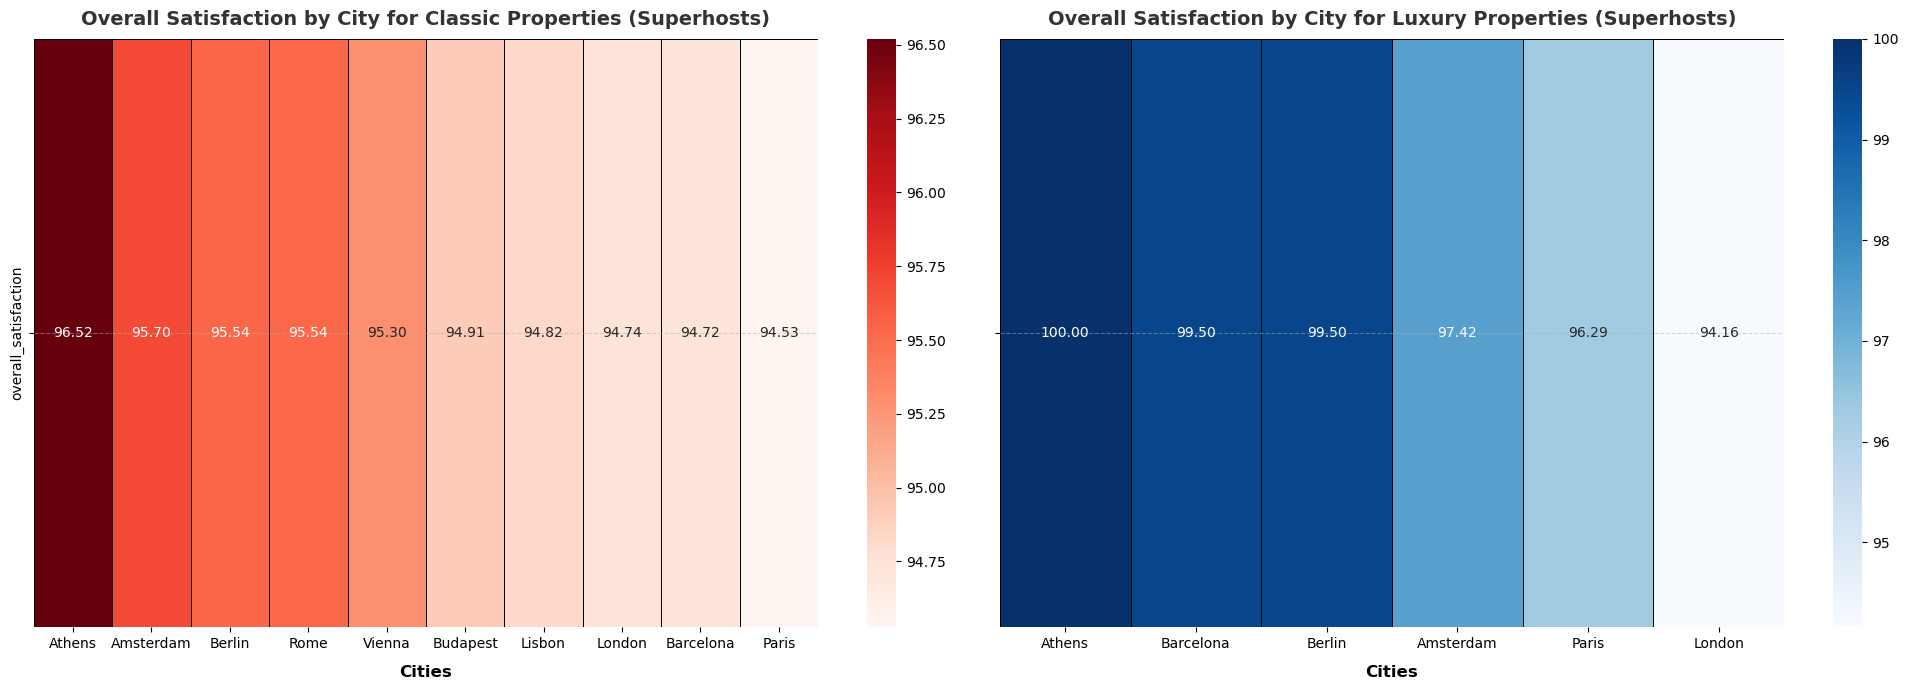

In [62]:
# 4. Overall satisfaction by city for Superhost Properties
# Group by city and calculate the average guest satisfaction
classic_city_satisfaction_superhost = superhost_classic_props.groupby('cities')['overall_satisfaction'].mean().reset_index()
luxury_city_satisfaction_superhost = superhost_luxury_props.groupby('cities')['overall_satisfaction'].mean().reset_index()

# Sort by overall satisfaction for heatmap display
classic_city_satisfaction_superhost = classic_city_satisfaction_superhost.sort_values(by='overall_satisfaction', ascending=False)
luxury_city_satisfaction_superhost = luxury_city_satisfaction_superhost.sort_values(by='overall_satisfaction', ascending=False)

# Set 'cities' as the index for the sorted DataFrame before pivoting
classic_city_satisfaction_superhost_pivot = classic_city_satisfaction_superhost.set_index('cities').T
luxury_city_satisfaction_superhost_pivot = luxury_city_satisfaction_superhost.set_index('cities').T

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot for Classic Properties
plot_heatmap(
    data=classic_city_satisfaction_superhost_pivot,
    ax=axes[0],
    title='Overall Satisfaction by City for Classic Properties (Superhosts)',
    xlabel='Cities',
    palette='Reds'
)

# Plot for Luxury Properties
plot_heatmap(
    data=luxury_city_satisfaction_superhost_pivot,
    ax=axes[1],
    title='Overall Satisfaction by City for Luxury Properties (Superhosts)',
    xlabel='Cities',
    palette='Blues'
)

# Tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Overall satisfaction by city for Superhost Properties ⚛
    In the both scenarios, Properties managed by Superhosts offer the most satisfying guest experiences.
    
    

    ⚛ OVERALL CONCLUSION : SUPERHOST IMPACT ANALYSIS ⚛

    • Overall Satisfaction: Superhosts demonstrate a higher level of overall satisfaction highlighting the success of the Superhost program.
    • Booking Amount: Possessing superhost status can enhance various facets of property performance, including guest satisfaction and increased repeat clientele.
    • Location: When it comes to classic choices, Rome and Athens are often favored by guest, whereas Amsterdam, London, and Paris are the preferred destinations for luxury properties.


### **Business Booking Impact Analysis**

This analysis explores the influence of booking a property for business purposes.

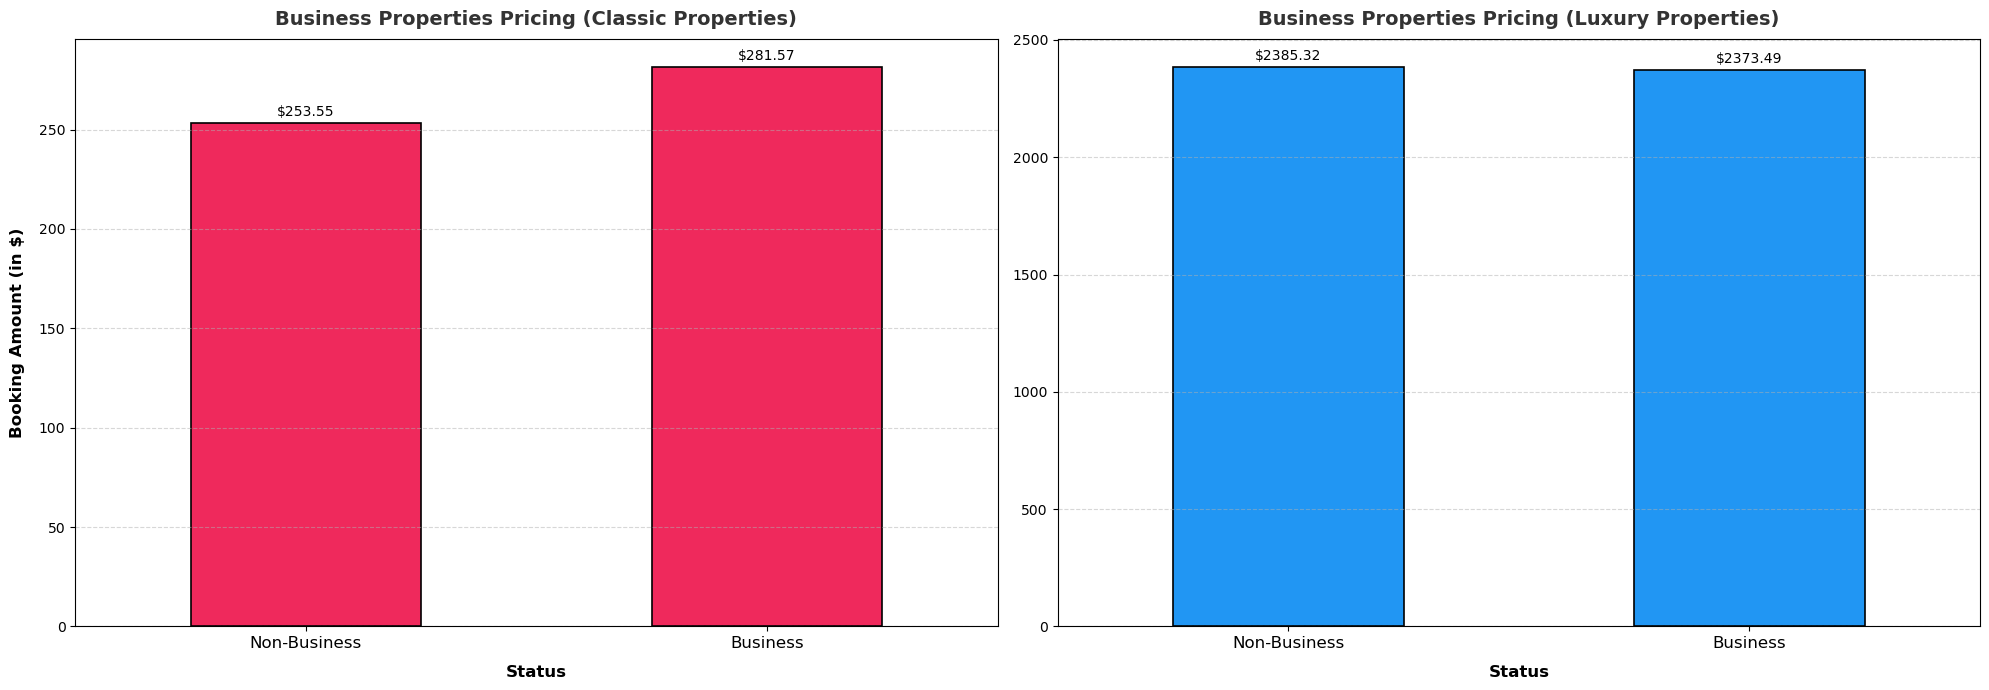

In [66]:
# 1. Business Properties Pricing
# Calculate average booking amount for business properties
classic_business_avg_booking = classic_props_df.groupby('biz')['booking_amount'].mean()
luxury_business_avg_booking = luxury_props_df.groupby('biz')['booking_amount'].mean()

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_business_avg_booking,
    ax=axes[0],
    title='Business Properties Pricing (Classic Properties)',
    xlabel='Status',
    ylabel='Booking Amount (in $)',
    color='#ef295c',
)

# Set ticks
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Business', 'Business'], rotation=0, fontsize=12)

# Plot for Luxury Properties
plot_bar(
    data=luxury_business_avg_booking,
    ax=axes[1],
    title='Business Properties Pricing (Luxury Properties)',
    xlabel='Status',
    color='#2196f3'
)

# Set ticks
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Business', 'Business'], rotation=0, fontsize=12)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Business Properties Pricing ⚛
    Business properties in both classic and luxury categories have a substantial pricing advantage over non-business properties.

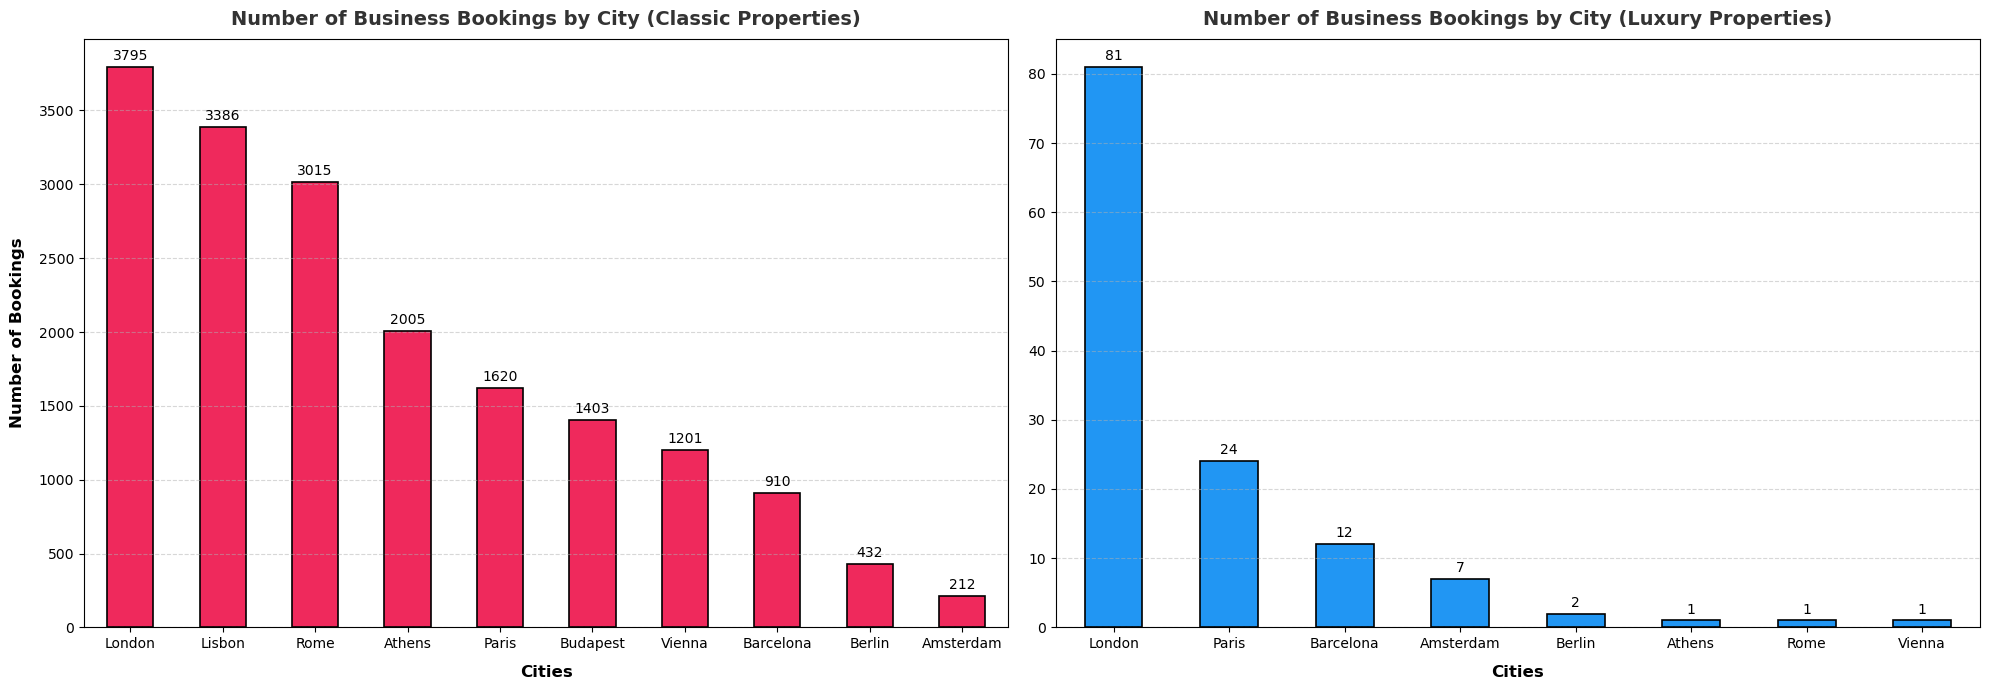

In [68]:
# 2. Number of Business Bookings by City
# Filter by business bookings
biz_classic_props = classic_props_df[classic_props_df['biz'] == 1]
biz_luxury_props = luxury_props_df[luxury_props_df['biz'] == 1]

# Group by city, and count the number of business bookings
classic_biz_bookings_by_city = biz_classic_props.groupby(['cities'])['biz'].count()
luxury_biz_bookings_by_city = biz_luxury_props.groupby(['cities'])['biz'].count()

# Sort by descending
classic_biz_bookings_by_city = classic_biz_bookings_by_city.sort_values(ascending=False)
luxury_biz_bookings_by_city = luxury_biz_bookings_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic properties
plot_bar(
    data=classic_biz_bookings_by_city,
    ax=axes[0],
    title='Number of Business Bookings by City (Classic Properties)',
    xlabel='Cities',
    ylabel='Number of Bookings',
    color='#ef295c',
)

# Plot for Luxury properties
plot_bar(
    data=luxury_biz_bookings_by_city,
    ax=axes[1],
    title='Number of Business Bookings by City (Luxury Properties)',
    xlabel='Cities',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"{i.get_height()}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply the layout and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Number of Business Bookings by City ⚛
    London stands out as the leading city for business bookings, indicating its prominence as a hub for commercial activities.
    Additionally, cities like Lisbon, Rome, and Athens are also experiencing a significant volume of business engagements, in classic properties.
    This observation suggests that these cities may have a stronger appeal for corporate travelers seeking high-end accommodations.

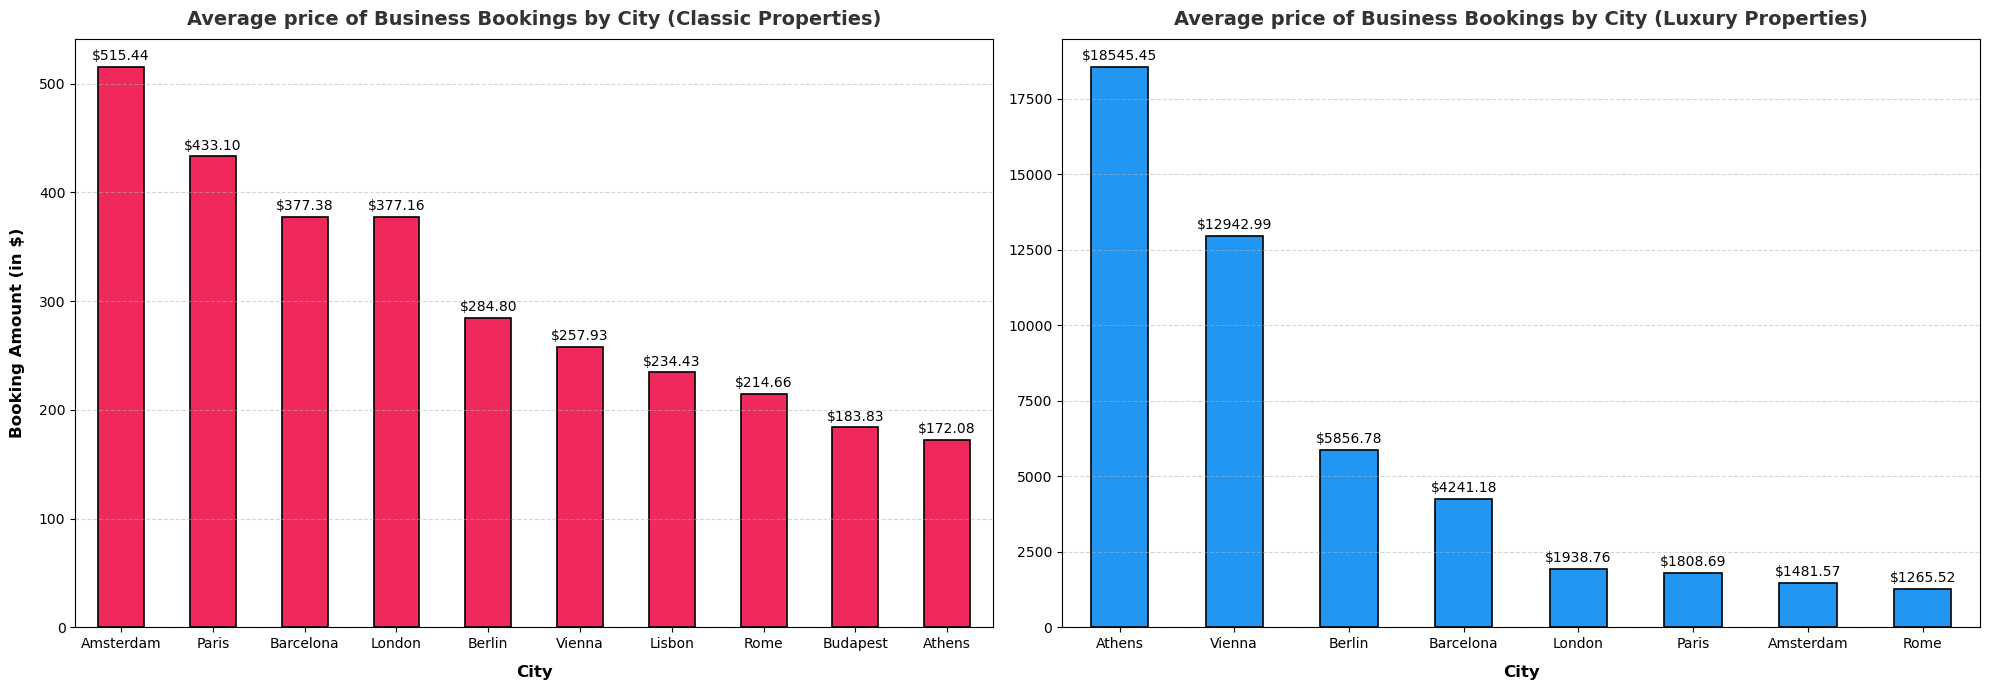

In [70]:
# 3. Average price of Business Bookings by City
# Calculate the average booking amount per city with business bookings
average_classic_biz_bookings_by_city = biz_classic_props.groupby(['cities'])['booking_amount'].mean()
average_luxury_biz_bookings_by_city = biz_luxury_props.groupby(['cities'])['booking_amount'].mean()

# Sort by descending
average_classic_biz_bookings_by_city = average_classic_biz_bookings_by_city.sort_values(ascending=False)
average_luxury_biz_bookings_by_city = average_luxury_biz_bookings_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic properties
plot_bar(
    data=average_classic_biz_bookings_by_city,
    ax=axes[0],
    title='Average price of Business Bookings by City (Classic Properties)',
    xlabel='City',
    ylabel='Booking Amount (in $)',
    color='#ef295c'
)

# Plot for Luxury properties
plot_bar(
    data=average_luxury_biz_bookings_by_city,
    ax=axes[1],
    title='Average price of Business Bookings by City (Luxury Properties)',
    xlabel='City',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

    ⚛ Observations of Average price of Business Bookings by City ⚛
    The city of London presents reasonable business booking prices for all situations.
    In contrast, Amsterdam and Paris feature the highest property prices, which could account for the lower booking rates in those locations.

    ⚛ OVERALL CONCLUSION : BUSINESS BOOKING IMPACT ANALYSIS ⚛

    • Business Properties: Business properties consistently command higher booking amounts than non-business properties.
    • City: London is the most popular city for business bookings.
    • Superhost Impact: Superhost status does not appear to have a significant impact on the average booking amount for business properties, but it can positively influence guest satisfaction.
    • In Athens, there is a single property that stands out with an exceptionally high price among luxury listings. This particular property is managed by a Superhost, suggesting it enjoys an outstanding reputation in the city.


### **Multi-listings Impact Analysis**

This analysis explores the influence of booking multi-listings properties on Pricing.

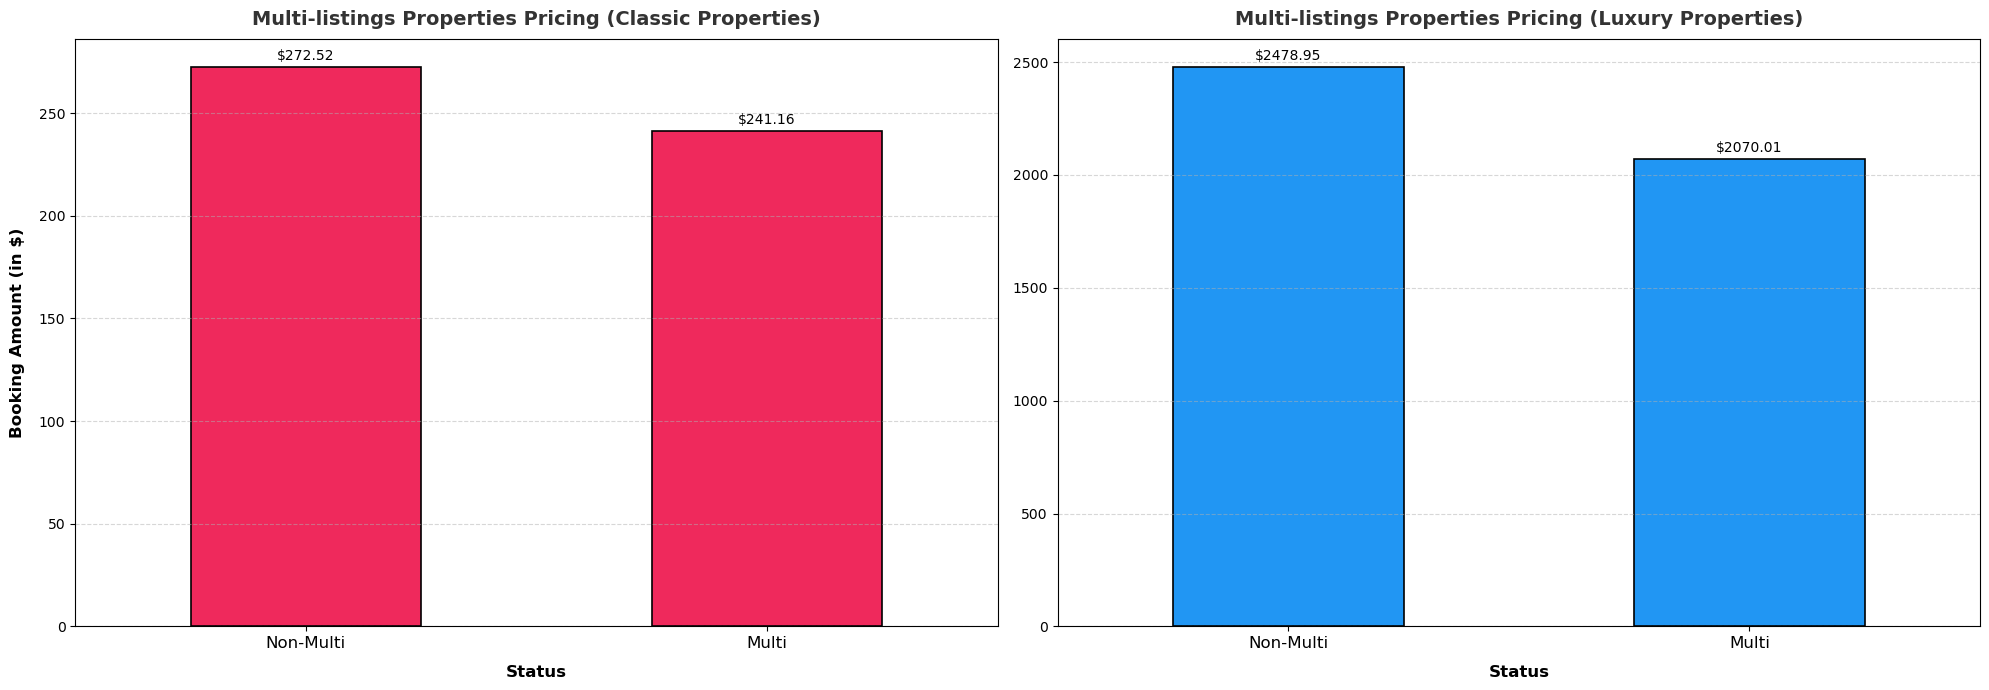

In [74]:
# 1. Multi-listings Properties Pricing
# Calculate average booking amount for multi-listings properties
classic_business_avg_booking = classic_props_df.groupby('multi')['booking_amount'].mean()
luxury_business_avg_booking = luxury_props_df.groupby('multi')['booking_amount'].mean()

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic Properties
plot_bar(
    data=classic_business_avg_booking,
    ax=axes[0],
    title='Multi-listings Properties Pricing (Classic Properties)',
    xlabel='Status',
    ylabel='Booking Amount (in $)',
    color='#ef295c',
)

# Set ticks
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Multi', 'Multi'], rotation=0, fontsize=12)

# Plot for Luxury Properties
plot_bar(
    data=luxury_business_avg_booking,
    ax=axes[1],
    title='Multi-listings Properties Pricing (Luxury Properties)',
    xlabel='Status',
    color='#2196f3'
)

# Set ticks
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Multi', 'Multi'], rotation=0, fontsize=12)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Multi-listings Properties Pricing ⚛
    Renting Multi-listings properties is less pricey in both scenarios.

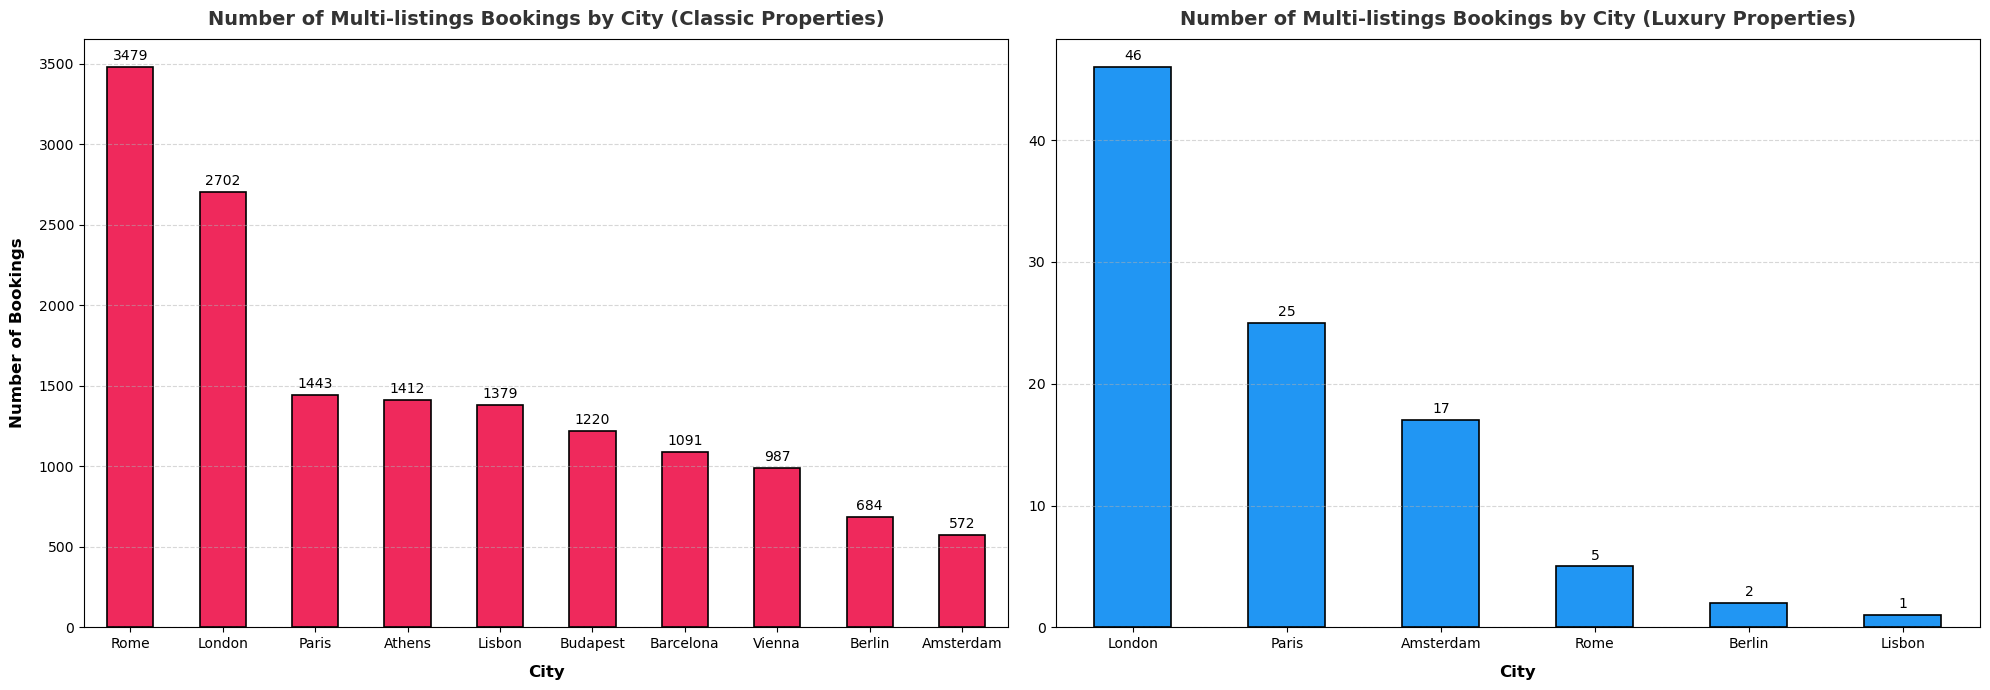

In [76]:
# 2. Number of Multi-listings Bookings by City
# Group by city, and count the number of multi-listings bookings
# Filter by business bookings
multi_classic_props = classic_props_df[classic_props_df['multi'] == 1]
multi_luxury_props = luxury_props_df[luxury_props_df['multi'] == 1]

multi_classic_bookings_by_city = multi_classic_props.groupby(['cities'])['multi'].count()
multi_luxury_bookings_by_city = multi_luxury_props.groupby(['cities'])['multi'].count()

# Sort by descending
multi_classic_bookings_by_city = multi_classic_bookings_by_city.sort_values(ascending=False)
multi_luxury_bookings_by_city = multi_luxury_bookings_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic properties
plot_bar(
    data=multi_classic_bookings_by_city,
    ax=axes[0],
    title='Number of Multi-listings Bookings by City (Classic Properties)',
    xlabel='City',
    ylabel='Number of Bookings',
    color='#ef295c',
)

# Plot for Luxury properties
plot_bar(
    data=multi_luxury_bookings_by_city,
    ax=axes[1],
    title='Number of Multi-listings Bookings by City (Luxury Properties)',
    xlabel='City',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"{i.get_height()}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

# Apply the layout and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Number of Multi-listings Bookings by City ⚛
    Rome presents a greater variety of multi-listing choices.
    Among the cities, London and Paris are the most favored for multi-listing bookings, covering both traditional and luxury properties.
    The trend shows a higher concentration of multi-listing reservations in luxury accommodations, suggesting that these cities may be more attractive to guests seeking premium multi-listing experiences.

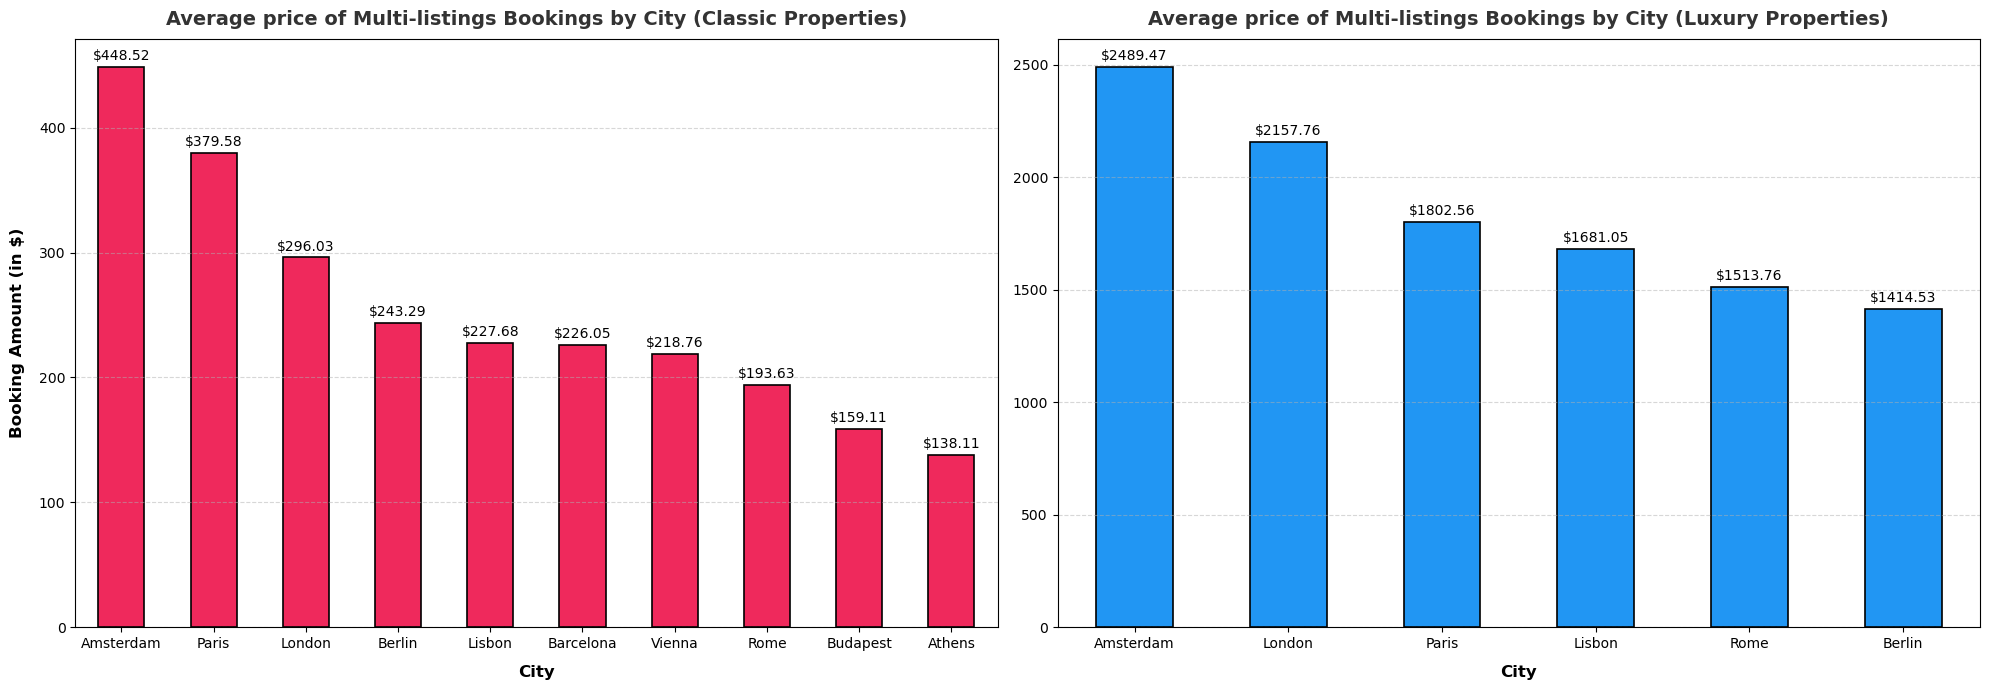

In [78]:
# 3. Average price of Multi-listings Bookings by City
# Calculate the average booking amount per city with multi-listings
average_multi_classic_bookings_by_city = classic_props_df[classic_props_df['multi'] == 1].groupby(['cities'])['booking_amount'].mean()
average_multi_luxury_bookings_by_city = luxury_props_df[luxury_props_df['multi'] == 1].groupby(['cities'])['booking_amount'].mean()

# Sort by descending
average_multi_classic_bookings_by_city = average_multi_classic_bookings_by_city.sort_values(ascending=False)
average_multi_luxury_bookings_by_city = average_multi_luxury_bookings_by_city.sort_values(ascending=False)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot for Classic properties
plot_bar(
    data=average_multi_classic_bookings_by_city,
    ax=axes[0],
    title='Average price of Multi-listings Bookings by City (Classic Properties)',
    xlabel='City',
    ylabel='Booking Amount (in $)',
    color='#ef295c'
)

# Plot for Luxury properties
plot_bar(
    data=average_multi_luxury_bookings_by_city,
    ax=axes[1],
    title='Average price of Multi-listings Bookings by City (Luxury Properties)',
    xlabel='City',
    color='#2196f3'
)

# Add annotations to show the value on top of each bar
for ax in axes:
    for i in ax.patches:
        ax.annotate(f"${i.get_height():.2f}",
                    (i.get_x() + i.get_width() / 2., i.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

    ⚛ Observations of Average price of Multi-listings Bookings by City ⚛
    In terms of pricing, Amsterdam leads as the city with the highest figures for both classic and luxury multi-listing properties.
    The variation in prices across cities is especially marked for classic properties, implying that aspects such as location, amenities, and market demand are crucial in shaping the pricing of classic multi-listings.

    ⚛ OVERALL CONCLUSION : MULTI-LISTINGS IMPACT ANALYSIS ⚛

    • Pricing: Multi-listings properties consistently command higher booking amounts than non-multi-listings properties, both in classic and luxury categories.
    • City: London and Paris are the most popular cities for multi-listings bookings.

### **Location and Access Analysis**
This analysis investigates factors such as proximity to the city center or nearby restaurants to clarify the reasons behind bookings in certain areas.

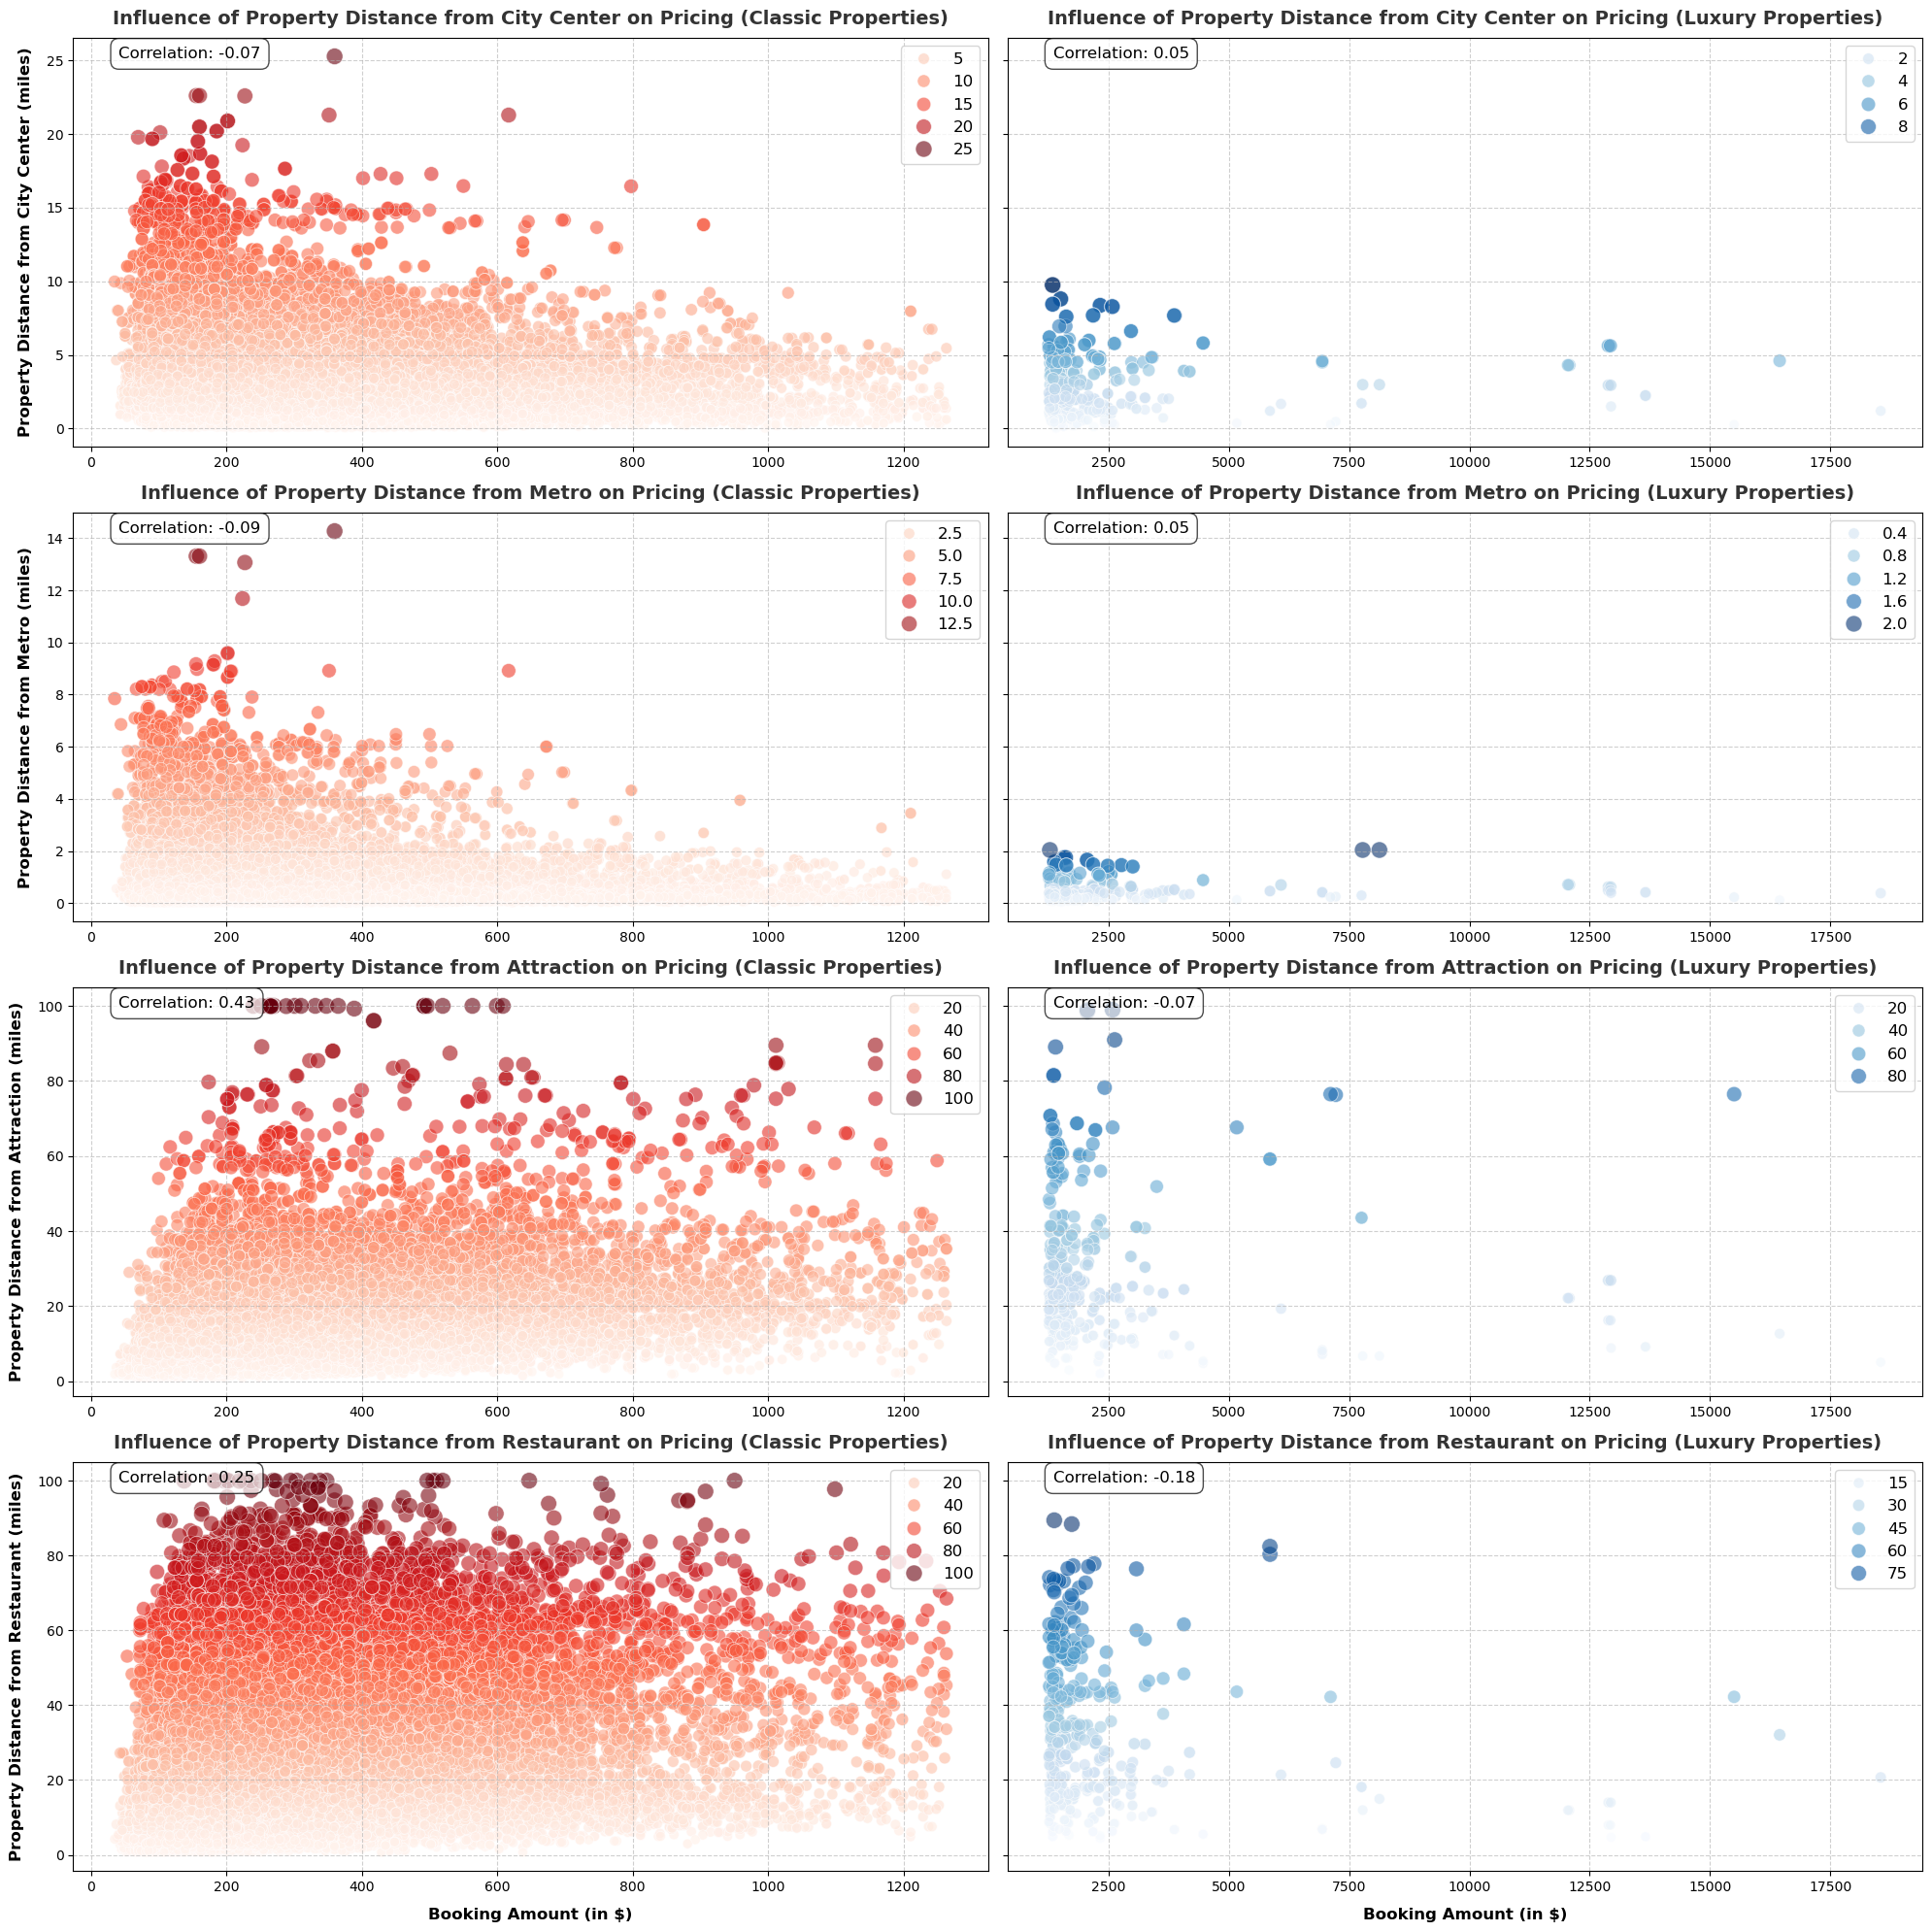

In [82]:
# 1. Correlation between Distance Features and Booking Amount
# Calculate correlations
# Distance from city
correlation_dist_classic = classic_props_df['dist'].corr(classic_props_df['booking_amount'])
correlation_dist_luxury = luxury_props_df['dist'].corr(luxury_props_df['booking_amount'])

# Metro Distance
correlation_metro_dist_classic = classic_props_df['metro_dist'].corr(classic_props_df['booking_amount'])
correlation_metro_dist_luxury = luxury_props_df['metro_dist'].corr(luxury_props_df['booking_amount'])

# Attraction Distances
correlation_attr_index_classic = classic_props_df['attr_index_norm'].corr(classic_props_df['booking_amount'])
correlation_attr_index_luxury = luxury_props_df['attr_index_norm'].corr(luxury_props_df['booking_amount'])

# Restaurant Distances
correlation_rest_index_classic = classic_props_df['rest_index_norm'].corr(classic_props_df['booking_amount'])
correlation_rest_index_luxury = luxury_props_df['rest_index_norm'].corr(luxury_props_df['booking_amount'])

# Create a figure with two subplots
fig, axes = plt.subplots(4, 2, figsize=(20, 20), sharey='row')

# Influence of Distance from city center on Booking Amount
# Plot for Classic Properties
plot_scatter(
    data=classic_props_df,
    correlation=correlation_dist_classic,
    ax=axes[0, 0],
    title='Influence of Property Distance from City Center on Pricing (Classic Properties)',
    ylabel='Property Distance from City Center (miles)',
    x='booking_amount',
    y='dist',
    hue='dist',
    palette='Reds',
    size='dist'
)

# Plot for Luxury Properties
plot_scatter(
    data=luxury_props_df,
    correlation=correlation_dist_luxury,
    ax=axes[0, 1],
    title='Influence of Property Distance from City Center on Pricing (Luxury Properties)',
    x='booking_amount',
    y='dist',
    hue='dist',
    palette='Blues',
    size='dist'
)

# Influence of Propertiy Distance from Metro on Booking Amount
# Plot for Classic Properties
plot_scatter(
    data=classic_props_df,
    correlation=correlation_metro_dist_classic,
    ax=axes[1, 0],
    title='Influence of Property Distance from Metro on Pricing (Classic Properties)',
    ylabel='Property Distance from Metro (miles)',
    x='booking_amount',
    y='metro_dist',
    hue='metro_dist',
    palette='Reds',
    size='metro_dist'
)

# Plot for Luxury Properties
plot_scatter(
    data=luxury_props_df,
    correlation=correlation_metro_dist_luxury,
    ax=axes[1, 1],
    title='Influence of Property Distance from Metro on Pricing (Luxury Properties)',
    x='booking_amount',
    y='metro_dist',
    hue='metro_dist',
    palette='Blues',
    size='metro_dist'
)

# Influence of Property Distance from Attraction on Booking Amount
# Plot for Classic Properties
plot_scatter(
    data=classic_props_df,
    correlation=correlation_attr_index_classic,
    ax=axes[2, 0],
    title='Influence of Property Distance from Attraction on Pricing (Classic Properties)',
    ylabel='Property Distance from Attraction (miles)',
    x='booking_amount',
    y='attr_index_norm',
    hue='attr_index_norm',
    palette='Reds',
    size='attr_index_norm'
)

# Plot for Luxury Properties
plot_scatter(
    data=luxury_props_df,
    correlation=correlation_attr_index_luxury,
    ax=axes[2, 1],
    title='Influence of Property Distance from Attraction on Pricing (Luxury Properties)',
    x='booking_amount',
    y='attr_index_norm',
    hue='attr_index_norm',
    palette='Blues',
    size='attr_index_norm'
)

# Influence of Property Distance from Restaurant on Booking Amount
# Plot for Classic Properties
plot_scatter(
    data=classic_props_df,
    correlation=correlation_rest_index_classic,
    ax=axes[3, 0],
    title='Influence of Property Distance from Restaurant on Pricing (Classic Properties)',
    xlabel='Booking Amount (in $)',
    ylabel='Property Distance from Restaurant (miles)',
    x='booking_amount',
    y='rest_index_norm',
    hue='rest_index_norm',
    palette='Reds',
    size='rest_index_norm'
)

# Plot for Luxury Properties
plot_scatter(
    data=luxury_props_df,
    correlation=correlation_rest_index_luxury,
    ax=axes[3, 1],
    title='Influence of Property Distance from Restaurant on Pricing (Luxury Properties)',
    xlabel='Booking Amount (in $)',
    x='booking_amount',
    y='rest_index_norm',
    hue='rest_index_norm',
    palette='Blues',
    size='rest_index_norm'
)

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Influence of Property Distance features on Pricing ⚛
    Classic Properties: Generally, being near attractions and restaurants positively affects pricing, while greater distance from the city center and metro stations tends to have a slight adverse effect.
    
    Luxury Properties: Properties that are closer to the city center and metro may see a slight increase in price, but being near attractions and restaurants can negatively influence their market value.

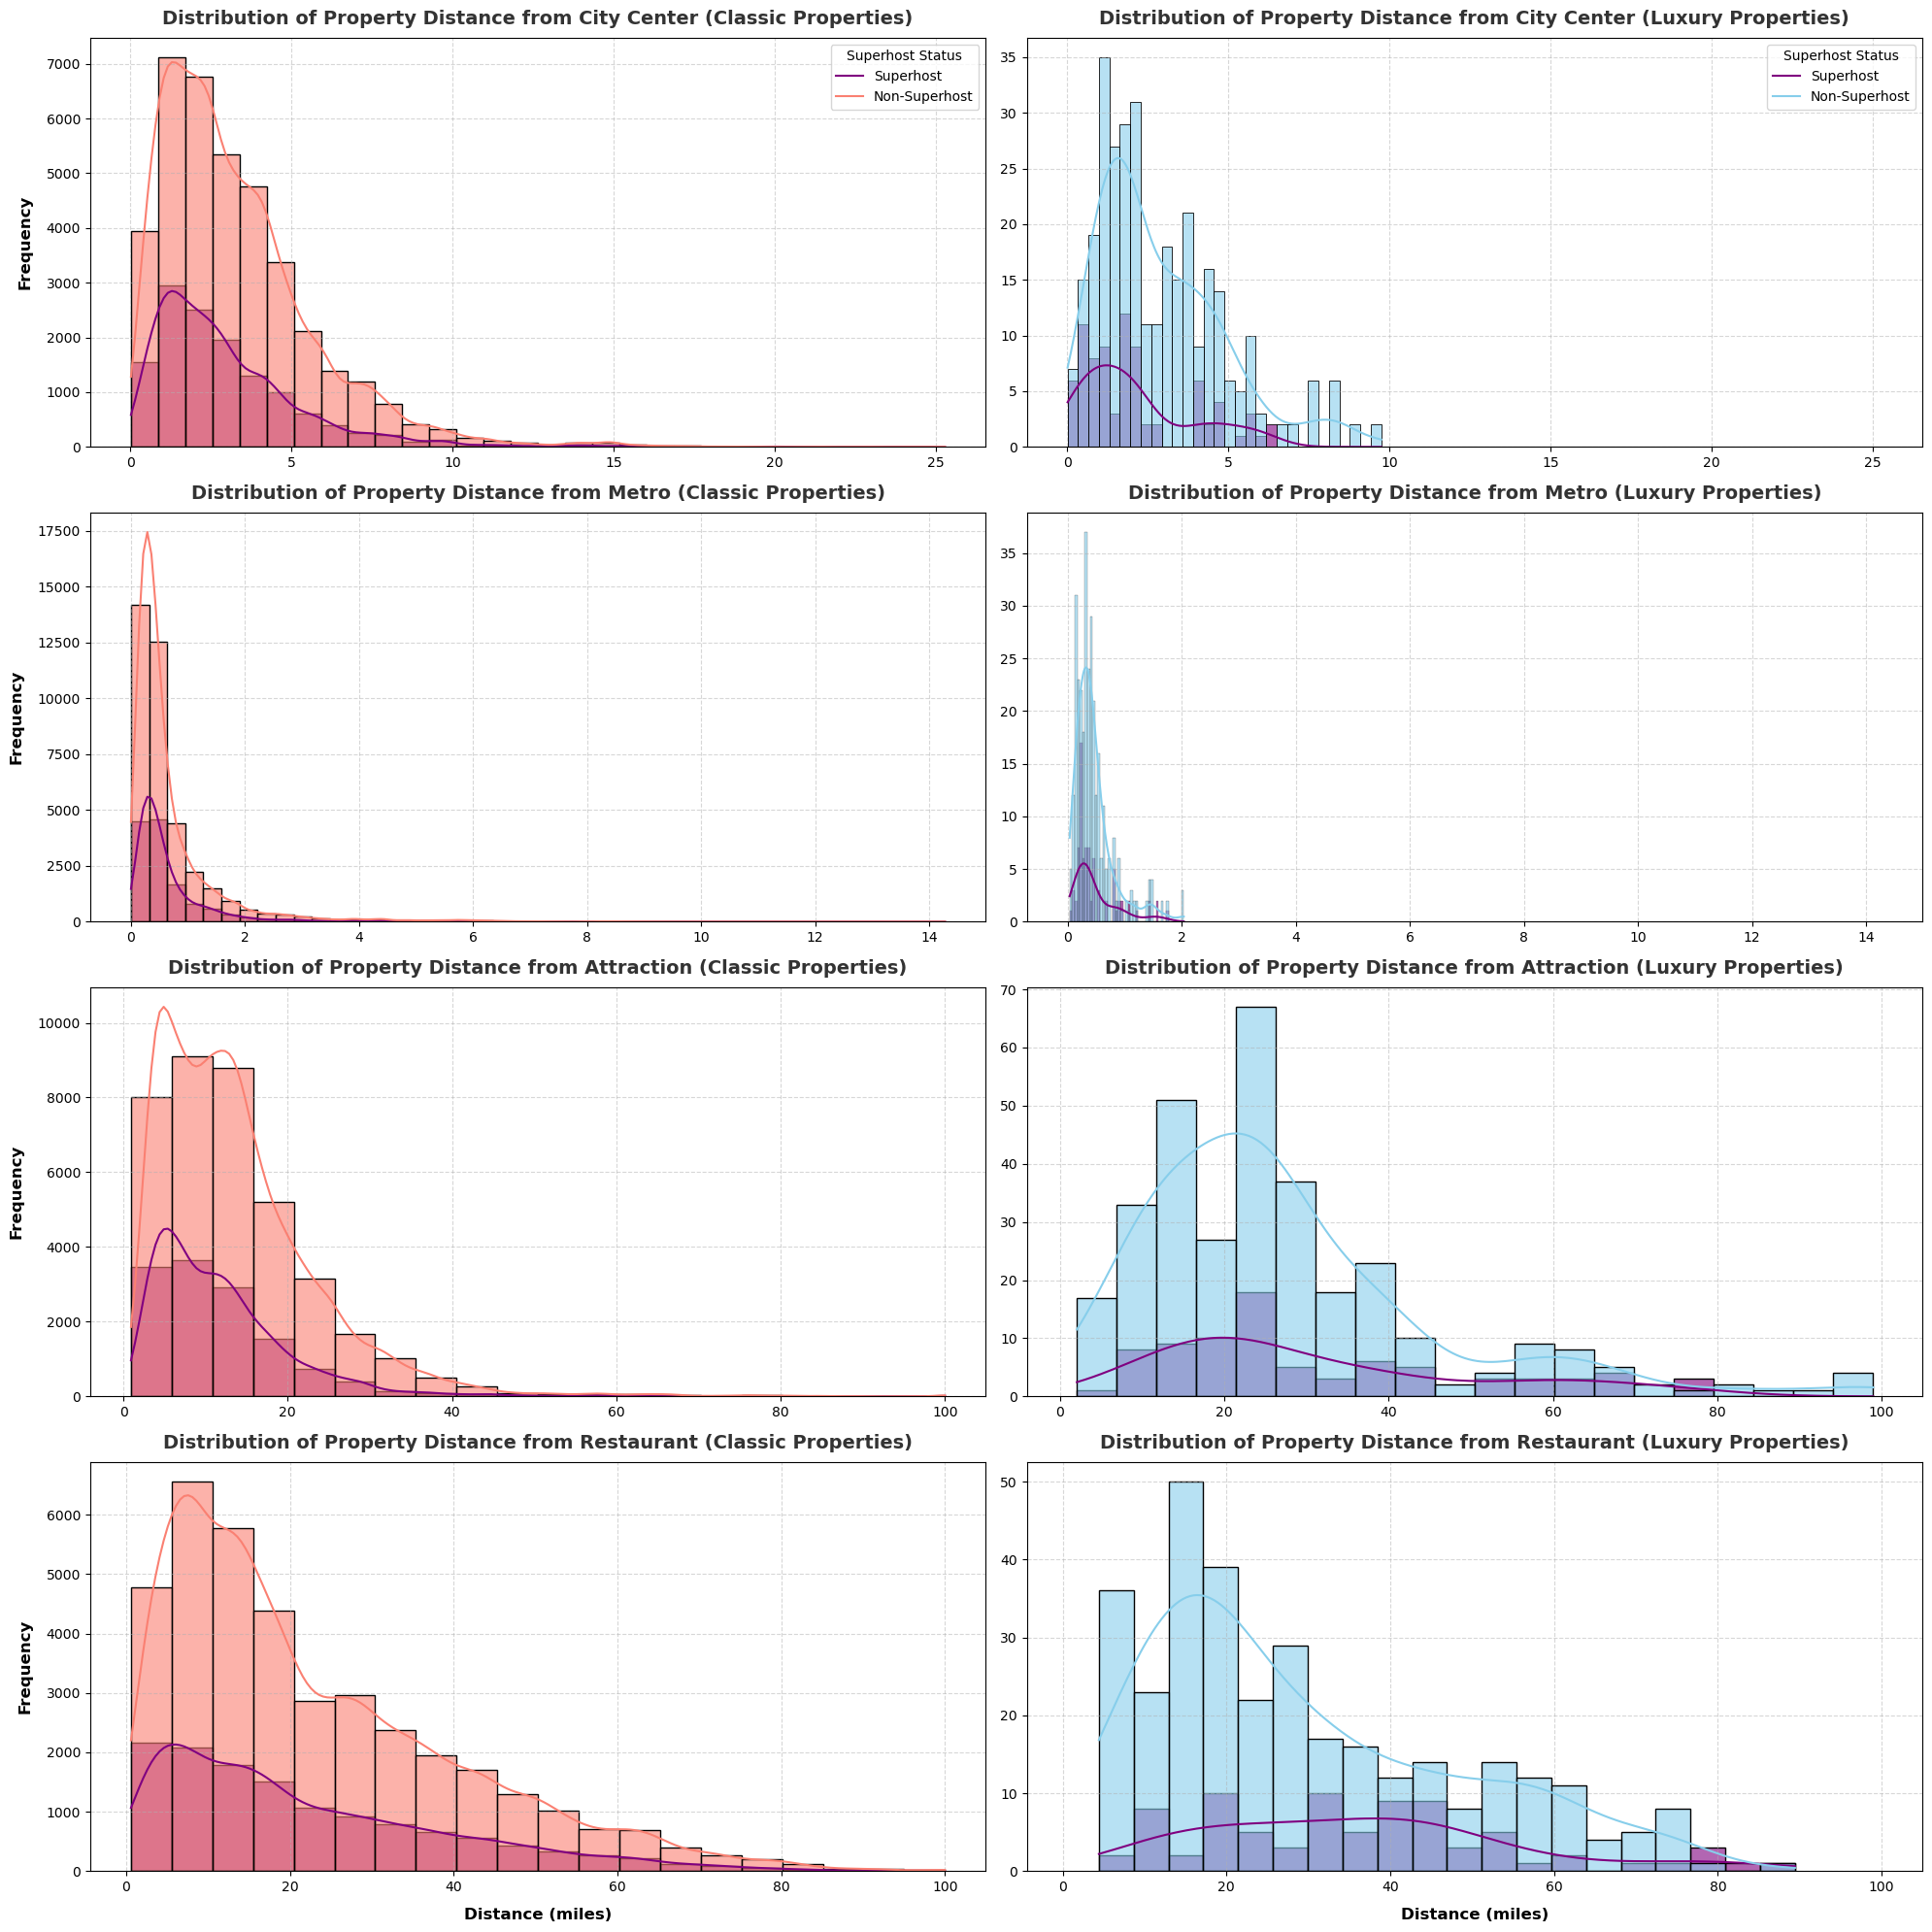

In [84]:
# 2. Distribution of Distance features
# Create a figure with two subplots
fig, axes = plt.subplots(4, 2, figsize=(20, 20), sharex='row')

# Distribution of Property Distance from City Center
# Plot for Classic Properties
plot_hist(
    data=classic_props_df,
    ax=axes[0, 0],
    x='dist',
    hue='host_is_superhost',
    title='Distribution of Property Distance from City Center (Classic Properties)',
    ylabel='Frequency',
    palette={0: 'salmon', 1: 'purple'},
    bins=30
)

# Plot for Luxury Properties
plot_hist(
    data=luxury_props_df,
    x='dist',
    ax=axes[0, 1],
    hue='host_is_superhost',
    title='Distribution of Property Distance from City Center (Luxury Properties)',
    palette={0: 'skyblue', 1: 'purple'},
    bins=30
)

# Distribution of Property Distance from Metro
# Plot for Classic Properties
plot_hist(
    data=classic_props_df,
    ax=axes[1, 0],
    x='metro_dist',
    hue='host_is_superhost',
    title='Distribution of Property Distance from Metro (Classic Properties)',
    ylabel='Frequency',
    palette={0: 'salmon', 1: 'purple'},
    bins=45
)

# Plot for Luxury Properties
plot_hist(
    data=luxury_props_df,
    ax=axes[1, 1],
    x='metro_dist',
    title='Distribution of Property Distance from Metro (Luxury Properties)',
    hue='host_is_superhost',
    palette={0: 'skyblue', 1: 'purple'},
    bins=45
)

# Distribution of Property Distance from Attraction
# Plot for Classic Properties
plot_hist(
    data=classic_props_df,
    ax=axes[2, 0],
    x='attr_index_norm',
    hue='host_is_superhost',
    title='Distribution of Property Distance from Attraction (Classic Properties)',
    ylabel='Frequency',
    palette={0: 'salmon', 1: 'purple'},
    bins=20
)

# Plot for Luxury Properties
plot_hist(
    data=luxury_props_df,
    ax=axes[2, 1],
    x='attr_index_norm',
    hue='host_is_superhost',
    title='Distribution of Property Distance from Attraction (Luxury Properties)',
    palette={0: 'skyblue', 1: 'purple'},
    bins=20
)

# Distribution of Property Distance from Restaurant
# Plot for Classic Properties
plot_hist(
    data=classic_props_df,
    ax=axes[3, 0],
    x='rest_index_norm',
    hue='host_is_superhost',
    title='Distribution of Property Distance from Restaurant (Classic Properties)',
    xlabel='Distance (miles)',
    ylabel='Frequency',
    palette={0: 'salmon', 1: 'purple'},
    bins=20
)

# Plot for Luxury Properties
plot_hist(
    data=luxury_props_df,
    ax=axes[3, 1],
    x='rest_index_norm',
    hue='host_is_superhost',
    title='Distribution of Property Distance from Restaurant (Luxury Properties)',
    xlabel='Distance (miles)',
    color='#2196f3',
    palette={0: 'skyblue', 1: 'purple'},
    bins=20
)

# Set legend
axes[0, 0].legend(title='Superhost Status', loc='upper right', labels=['Superhost', 'Non-Superhost'])
axes[0, 1].legend(title='Superhost Status', loc='upper right', labels=['Superhost', 'Non-Superhost'])

# Remove legend from other plots
axes[1, 0].get_legend().remove()
axes[1, 1].get_legend().remove()
axes[2, 0].get_legend().remove()
axes[2, 1].get_legend().remove()
axes[3, 0].get_legend().remove()
axes[3, 1].get_legend().remove()

plt.tight_layout()
plt.show()

    ⚛ Observations of Distribution of Property Distance features ⚛
    The distribution of property distance from various points of interest differs between classic and luxury properties.
    Luxury properties are generally located closer to the city center, metro, and restaurants, while classic properties tend to be more spread out.

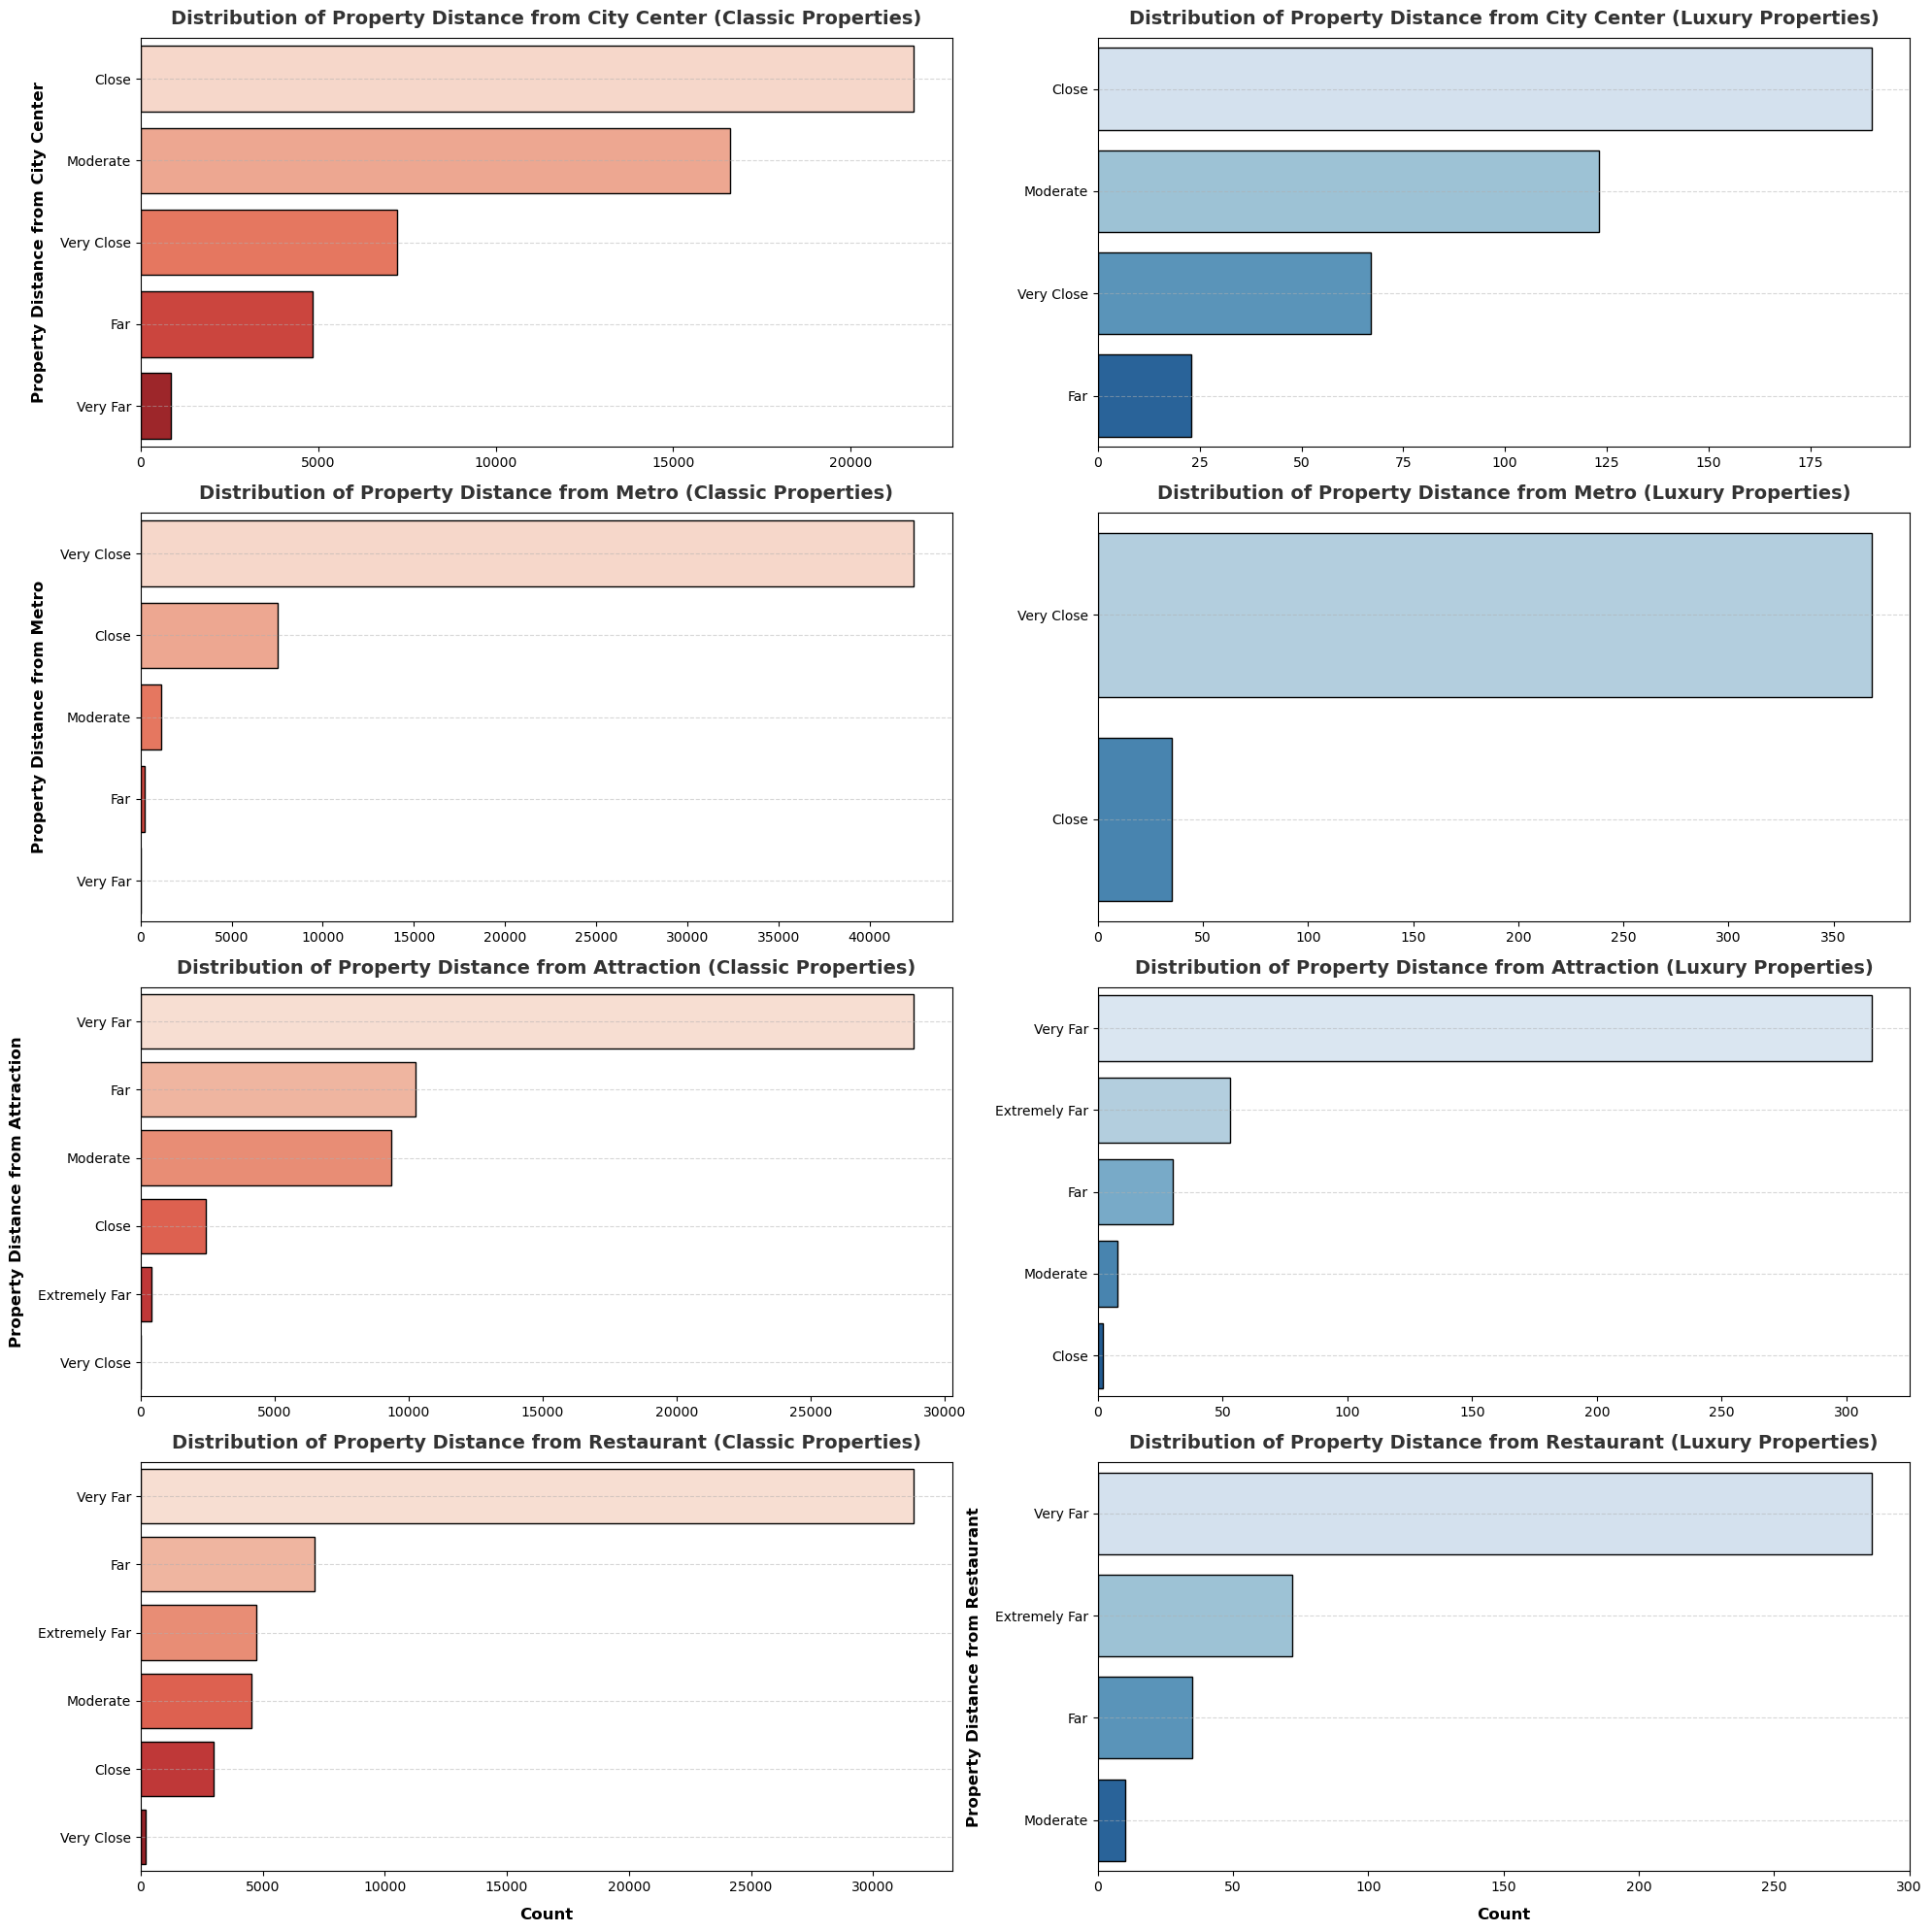

In [86]:
# 3. Distribution of Property Distance features (categories)
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(4, 2, figsize=(20, 20))

# Plot the Distribution of Property Distance for City Center
# Plot for Classic Properties
plot_count(
    classic_props_df['city_dist_from_props'],
    ax=axes[0, 0],
    title='Distribution of Property Distance from City Center (Classic Properties)',
    ylabel='Property Distance from City Center',
    order=classic_props_df['city_dist_from_props'].value_counts().index,
    palette='Reds'
)

# Plot for Luxury Properties
plot_count(
    luxury_props_df['city_dist_from_props'],
    ax=axes[0, 1],
    title='Distribution of Property Distance from City Center (Luxury Properties)',
    order=luxury_props_df['city_dist_from_props'].value_counts().index,
    palette='Blues'
)

# Distribution of Property Distance from Metro
# Plot for Classic Properties
plot_count(
    classic_props_df['metro_dist_from_props'],
    ax=axes[1, 0],
    title='Distribution of Property Distance from Metro (Classic Properties)',
    ylabel='Property Distance from Metro',
    order=classic_props_df['metro_dist_from_props'].value_counts().index,
    palette='Reds'
)

# Plot for Luxury Properties
plot_count(
    luxury_props_df['metro_dist_from_props'],
    ax=axes[1, 1],
    title='Distribution of Property Distance from Metro (Luxury Properties)',
    order=luxury_props_df['metro_dist_from_props'].value_counts().index,
    palette='Blues'
)

# Distribution of Property Distance from Attraction
# Plot for Classic Properties
plot_count(
    classic_props_df['attr_dist_from_props'],
    ax=axes[2, 0],
    title='Distribution of Property Distance from Attraction (Classic Properties)',
    ylabel='Property Distance from Attraction',
    order=classic_props_df['attr_dist_from_props'].value_counts().index,
    palette='Reds'
)

# Plot for Luxury Properties
plot_count(
    luxury_props_df['attr_dist_from_props'],
    ax=axes[2, 1],
    title='Distribution of Property Distance from Attraction (Luxury Properties)',
    order=luxury_props_df['attr_dist_from_props'].value_counts().index,
    palette='Blues'
)

# Distribution of Property Distance from Restaurant
# Plot for Classic Properties
plot_count(
    classic_props_df['rest_dist_from_props'],
    ax=axes[3, 0],
    title='Distribution of Property Distance from Restaurant (Classic Properties)',
    xlabel='Count',
    order=classic_props_df['rest_dist_from_props'].value_counts().index,
    palette='Reds'
)

# Plot for Luxury Properties
plot_count(
    luxury_props_df['rest_dist_from_props'],
    ax=axes[3, 1],
    title='Distribution of Property Distance from Restaurant (Luxury Properties)',
    xlabel='Count',
    ylabel='Property Distance from Restaurant',
    order=luxury_props_df['rest_dist_from_props'].value_counts().index,
    palette='Blues'
)

# Adjust layout to prevent overlap and show the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Distribution of Property Distance features ⚛
    
    • City Center: Luxury properties are more likely to be located closer to the city center than classic properties.
    • Metro: Luxury properties are more likely to be located closer to the metro than classic properties.
    • Attraction: There is no clear difference in the distribution of property distance from attractions between classic and luxury properties.
    • Restaurant: Luxury properties are more likely to be located closer to restaurants than classic properties.

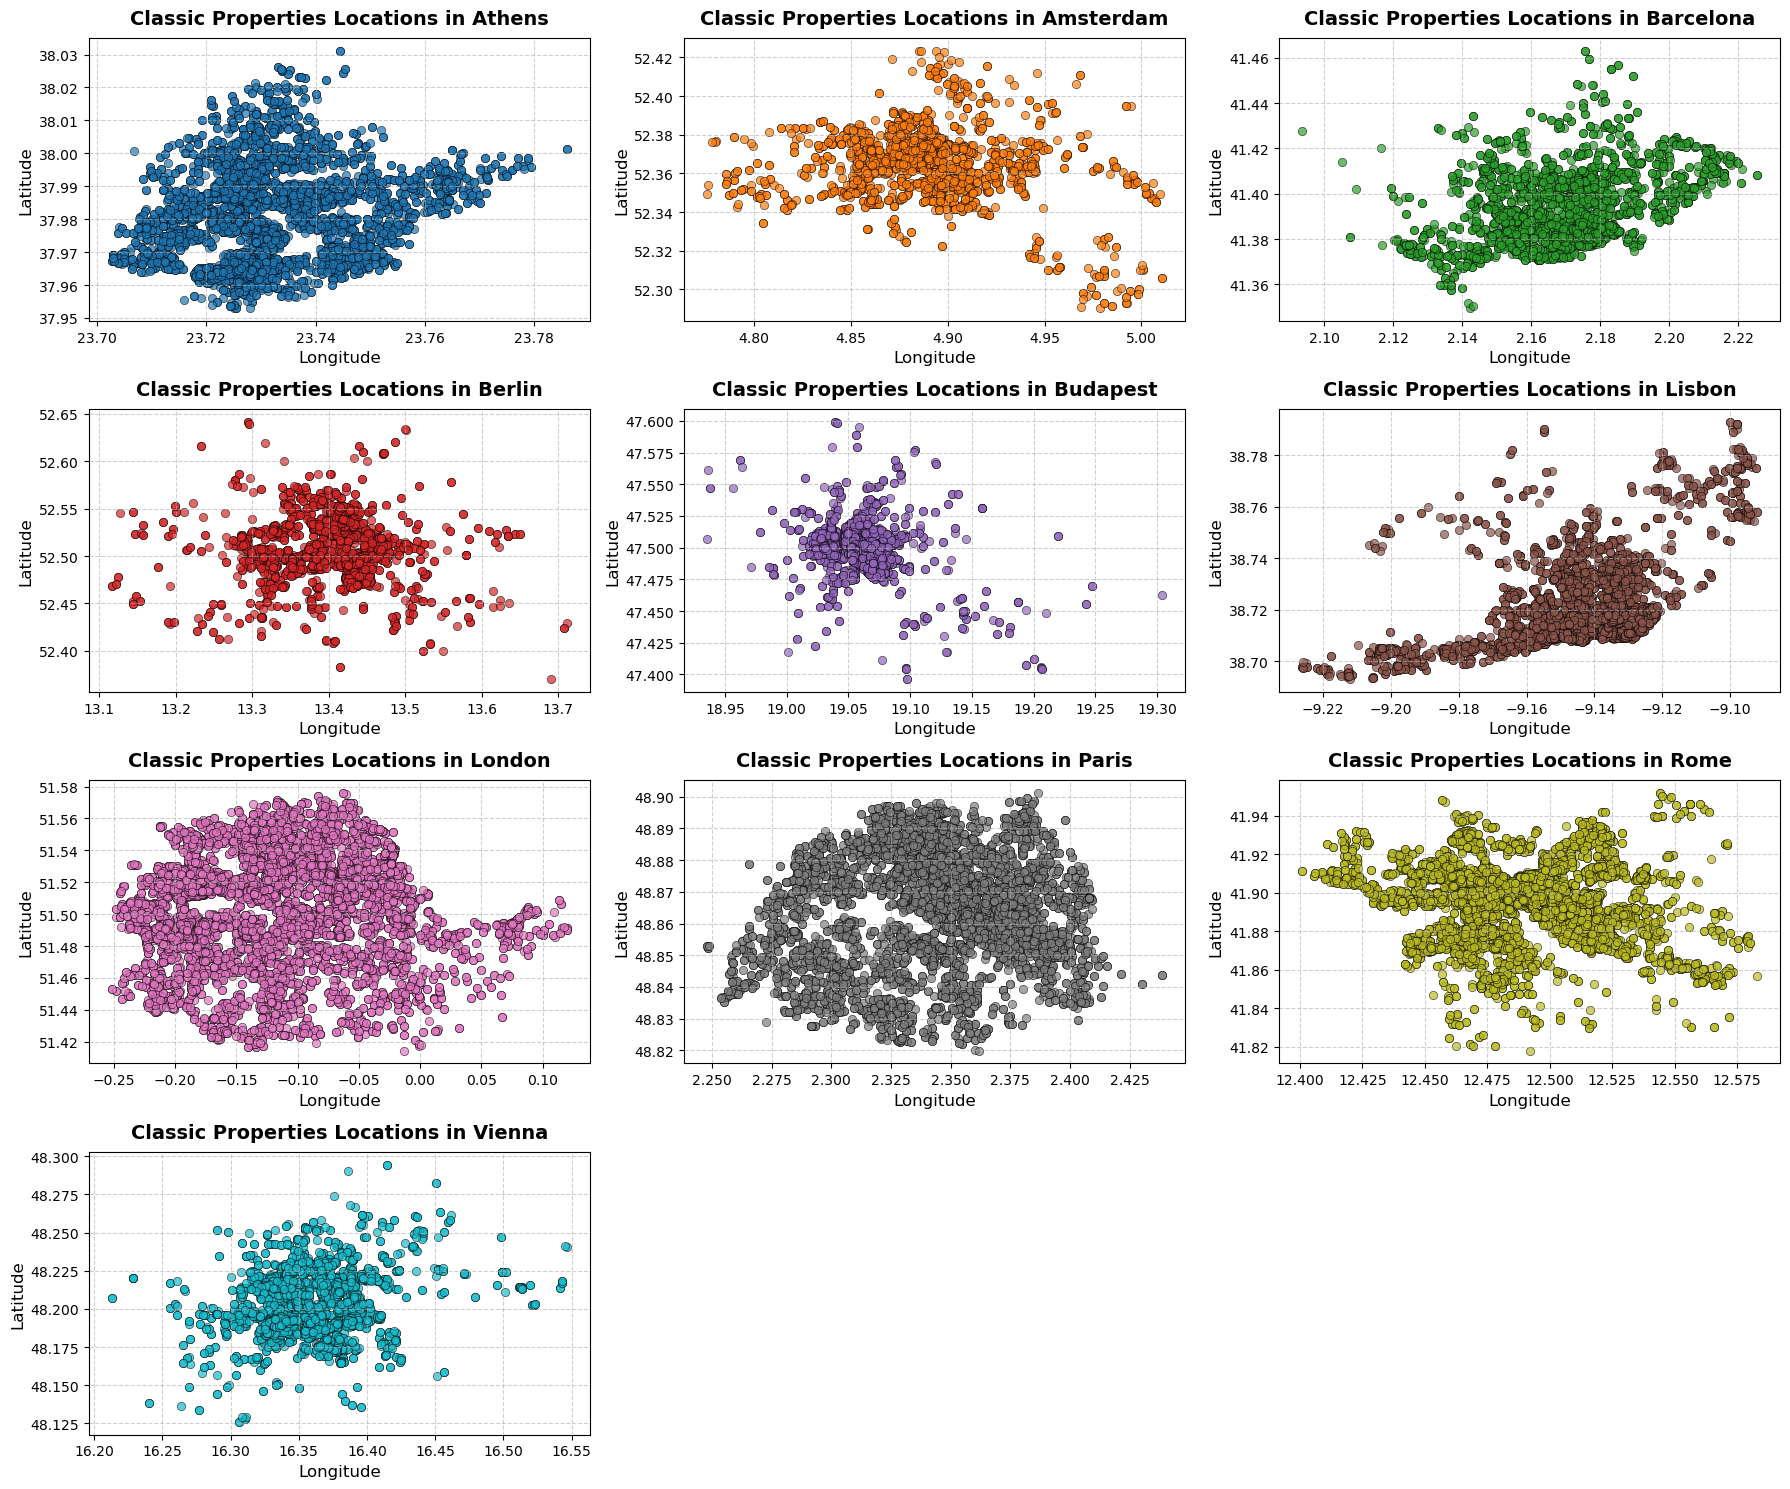

In [88]:
# 4. Properties Dispersion Across Classic Properties Cities
# Get the unique list of cities
cities = classic_props_df['cities'].unique()

# Generate a color palette with one color per city
palette = sns.color_palette('tab10', n_colors=len(cities))

# Create a figure with subplots (one for each city)
n_cities = len(cities)
fig, axes = plt.subplots(
    nrows=(n_cities + 2) // 3, ncols=3,
    figsize=(18, 15)
)

# Flatten the axes for easier iteration
axes = axes.flatten()

# Plot each city on a separate subplot with a unique color
for i, (city, color) in enumerate(zip(cities, palette)):
    city_data = classic_props_df[classic_props_df['cities'] == city]

    sns.scatterplot(
        x='lng',
        y='lat',
        data=city_data,
        ax=axes[i],
        color=color,
        edgecolor='black',
        alpha=0.7
    )

    # Set title, labels and gridlines
    axes[i].set_title(f'Classic Properties Locations in {city}', fontsize=14, weight='bold', pad=10)
    axes[i].set_xlabel('Longitude', fontsize=12)
    axes[i].set_ylabel('Latitude', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

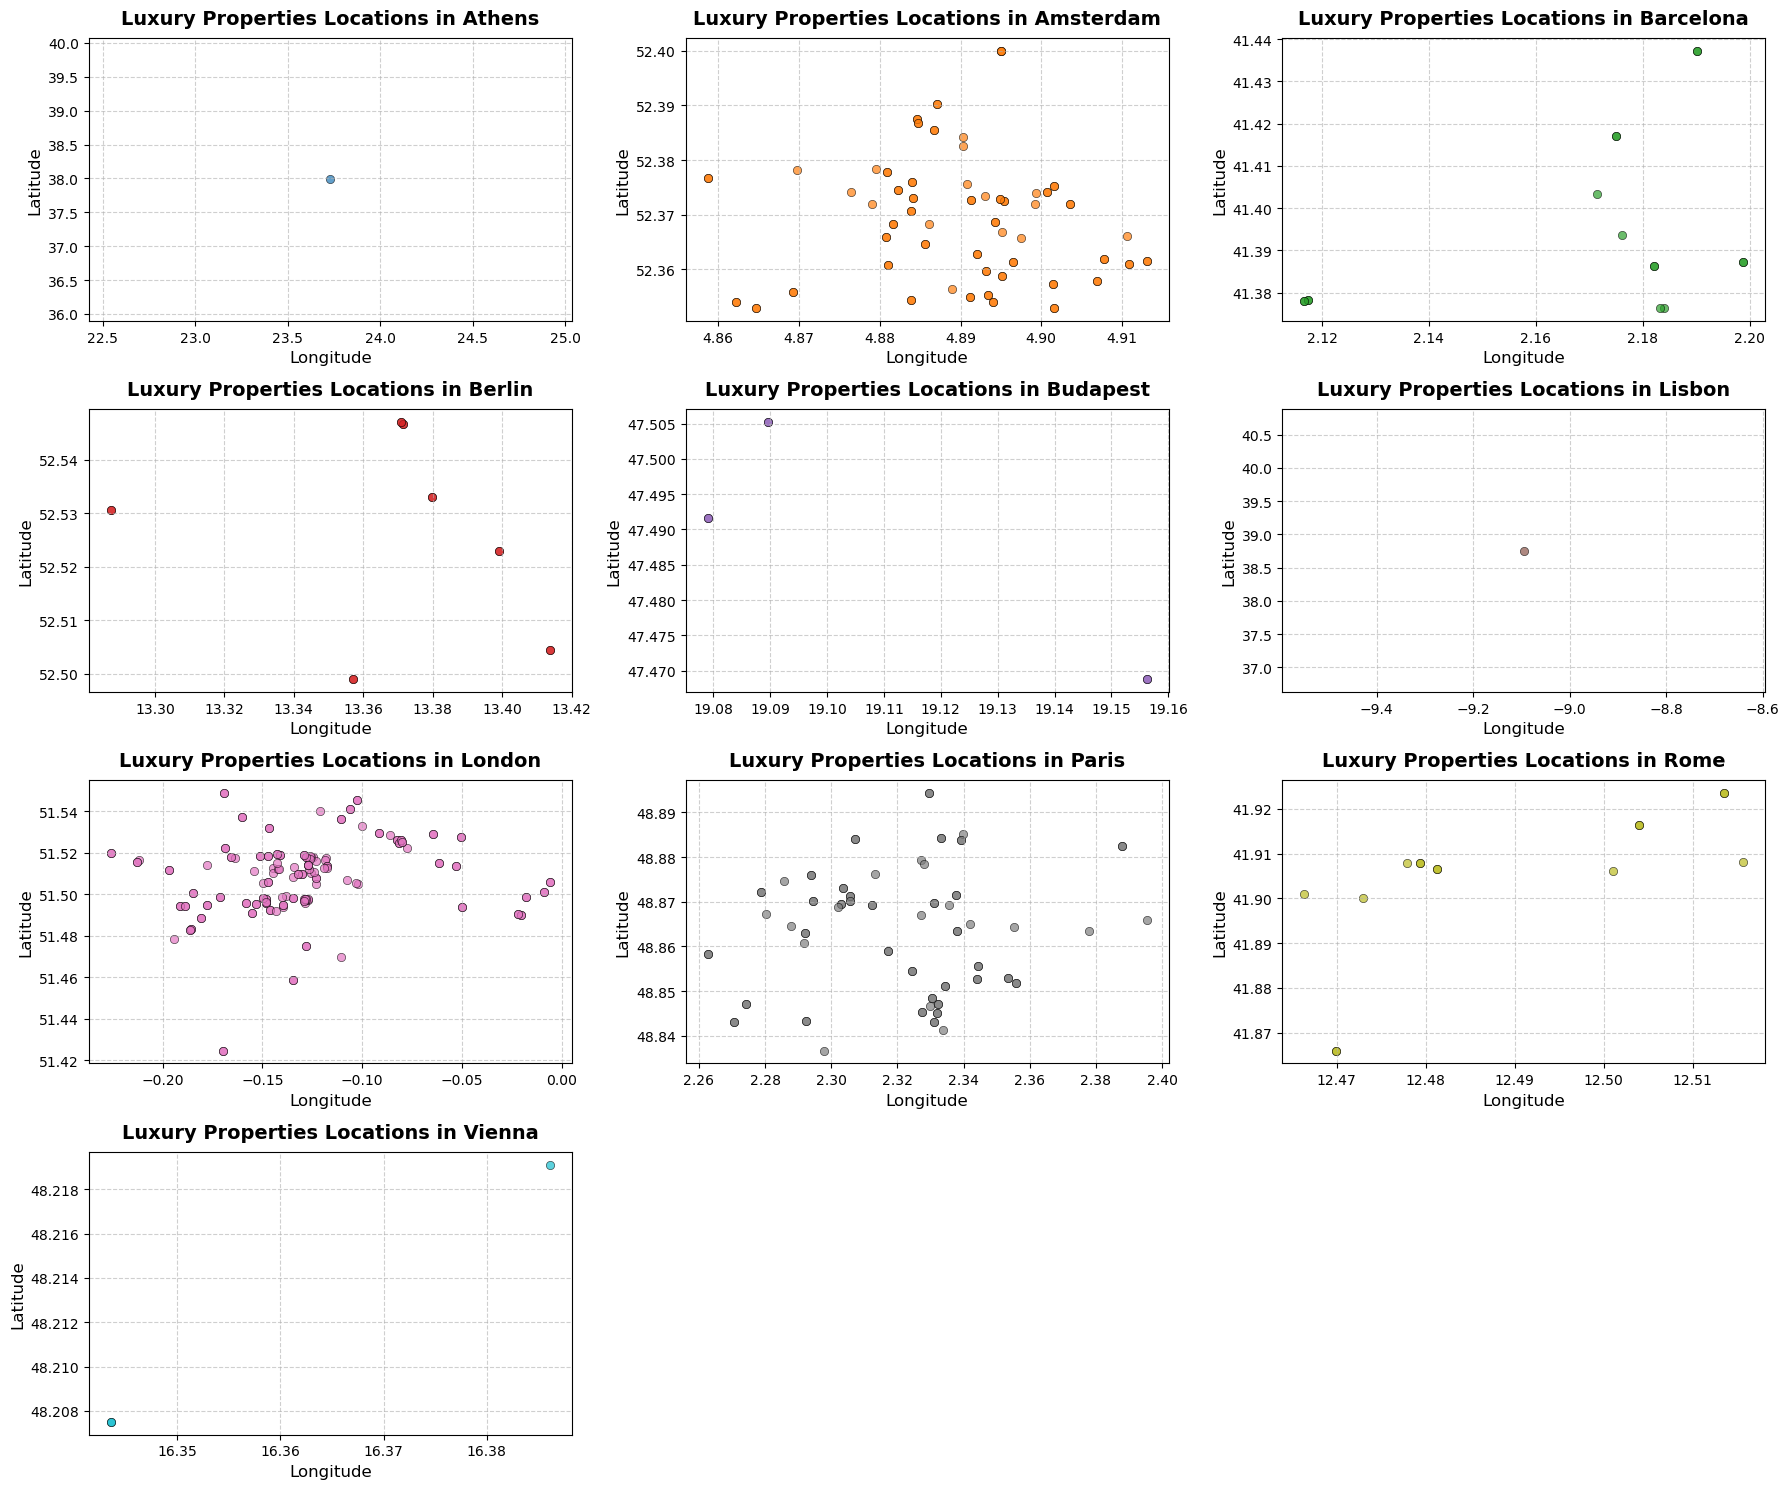

In [89]:
# 5. Properties Dispersion Across Luxury Properties Cities
# Get the unique list of cities
cities = luxury_props_df['cities'].unique()

# Generate a color palette with one color per city
palette = sns.color_palette('tab10', n_colors=len(cities))

# Create a figure with subplots (one for each city)
n_cities = len(cities)
fig, axes = plt.subplots(
    nrows=(n_cities + 2) // 3, ncols=3,
    figsize=(18, 15)
)

# Flatten the axes for easier iteration
axes = axes.flatten()

# Plot each city on a separate subplot with a unique color
for i, (city, color) in enumerate(zip(cities, palette)):
    city_data = luxury_props_df[luxury_props_df['cities'] == city]

    sns.scatterplot(
        x='lng',
        y='lat',
        data=city_data,
        ax=axes[i],
        color=color,
        edgecolor='black',
        alpha=0.7
    )

    # Set title, labels and gridlines
    axes[i].set_title(f'Luxury Properties Locations in {city}', fontsize=14, weight='bold', pad=10)
    axes[i].set_xlabel('Longitude', fontsize=12)
    axes[i].set_ylabel('Latitude', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

    ⚛ OVERALL CONCLUSION : LOCATION AND ACCESS ANALYSIS ⚛
    
    • Property Location: The location of properties significantly influences pricing and guest satisfaction. Properties located closer to desirable amenities, such as city centers, metro stations, attractions, and restaurants, often command higher prices and attract more guests.
    • The spatial distribution of properties varies across cities, reflecting local market dynamics and preferences. Luxury properties tend to be clustered in specific high-end neighborhoods, while classic properties may be more widely distributed.
    • Accessibility: The closeness to public transport options, such as metro stations, is a key factor that can significantly impact both the demand for properties and their pricing structure.

### **Time Period Analysis**
This analysis seeks to understand the significance of time periods in the booking process, considering whether peopple have preferences for specific days of the week.

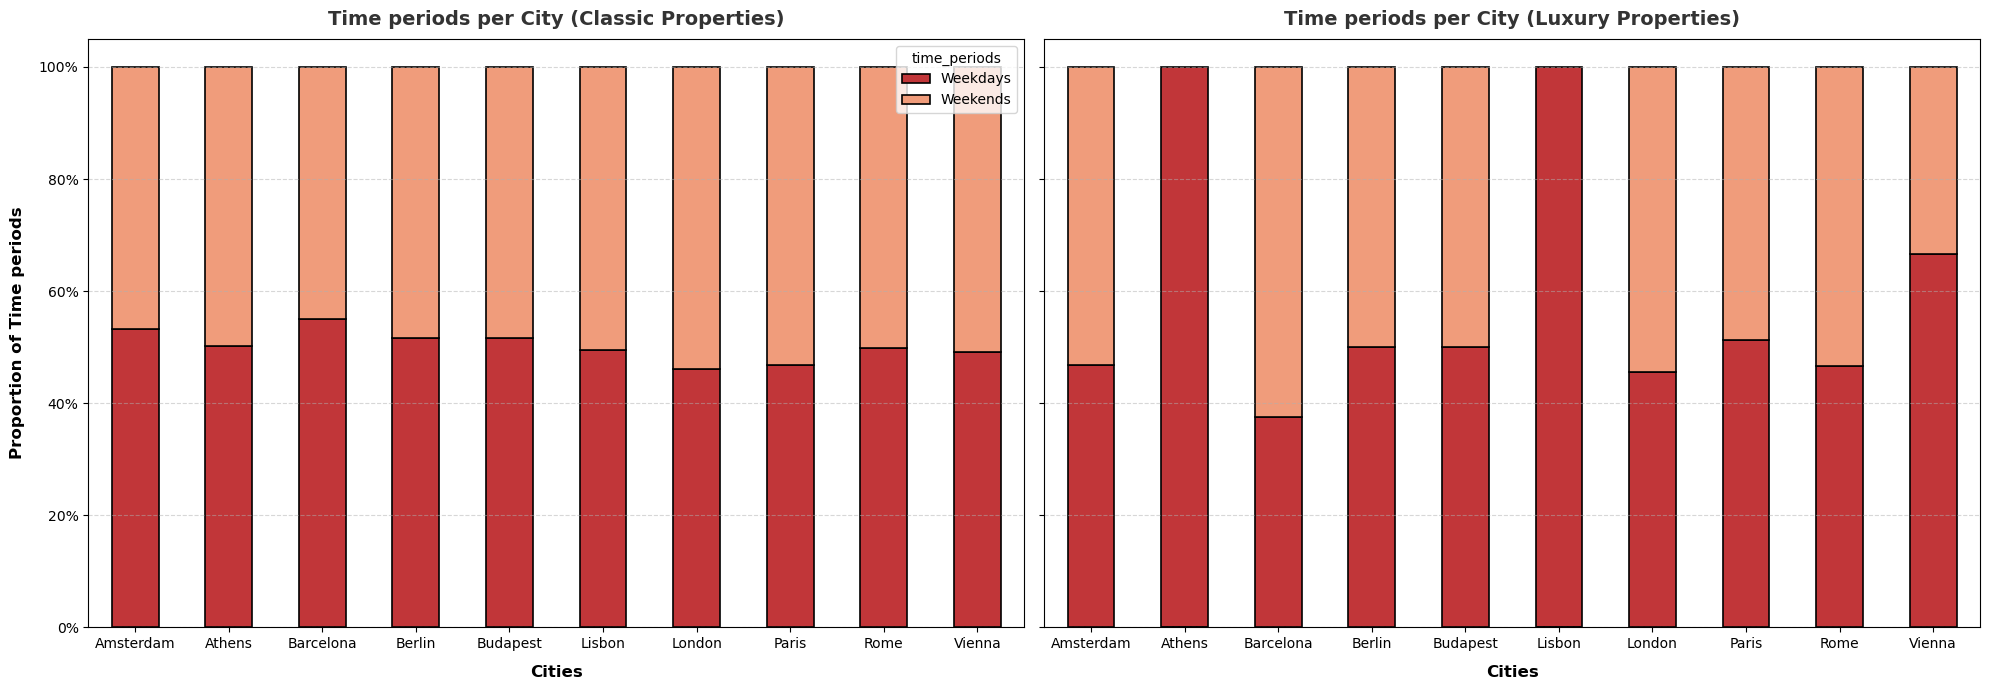

In [92]:
# Time periods per City
# Helper function to compute proportions of time periods per city
def get_time_periods_proportions(df):
    """Group by city and time periods, calculate the proportion of time periods for each city."""
    time_periods_by_city = df.groupby(['cities', 'time_periods'])['time_periods'].count().unstack()
    time_periods_proportion = time_periods_by_city.div(time_periods_by_city.sum(axis=1), axis=0)
    return time_periods_proportion

# Get the proportions for classic and luxury properties
time_periods_by_city_classic = get_time_periods_proportions(classic_props_df)
time_periods_by_city_luxury = get_time_periods_proportions(luxury_props_df)

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot: Proportion of Room Types for Classic Properties
plot_bar(
    data=time_periods_by_city_classic,
    ax=axes[0],
    title='Time periods per City (Classic Properties)',
    xlabel='Cities',
    ylabel='Proportion of Time periods',
    color=sns.color_palette('RdBu'),
    stacked=True
)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Plot: Proportion of Room Types for Luxury Properties
plot_bar(
    data=time_periods_by_city_luxury,
    ax=axes[1],
    title='Time periods per City (Luxury Properties)',
    xlabel='Cities',
    ylabel='Proportion of Time periods',
    color=sns.color_palette('RdBu'),
    stacked=True
)
axes[1].get_legend().remove()

# Optimize layout and display the plot
plt.tight_layout()
plt.show()

    ⚛ Observations of Time Periods per City ⚛
    In most cities weekends are the best time to book classic and luxury properties.
    Although there are variations that can be seen in some cities, the general trend of higher weekend bookings is consistent.

# **5. Model Building**

This section concentrates on the model training and optimization. The performance of these models are evaluated using regression metrics such as r2 score, rmse, and mae.

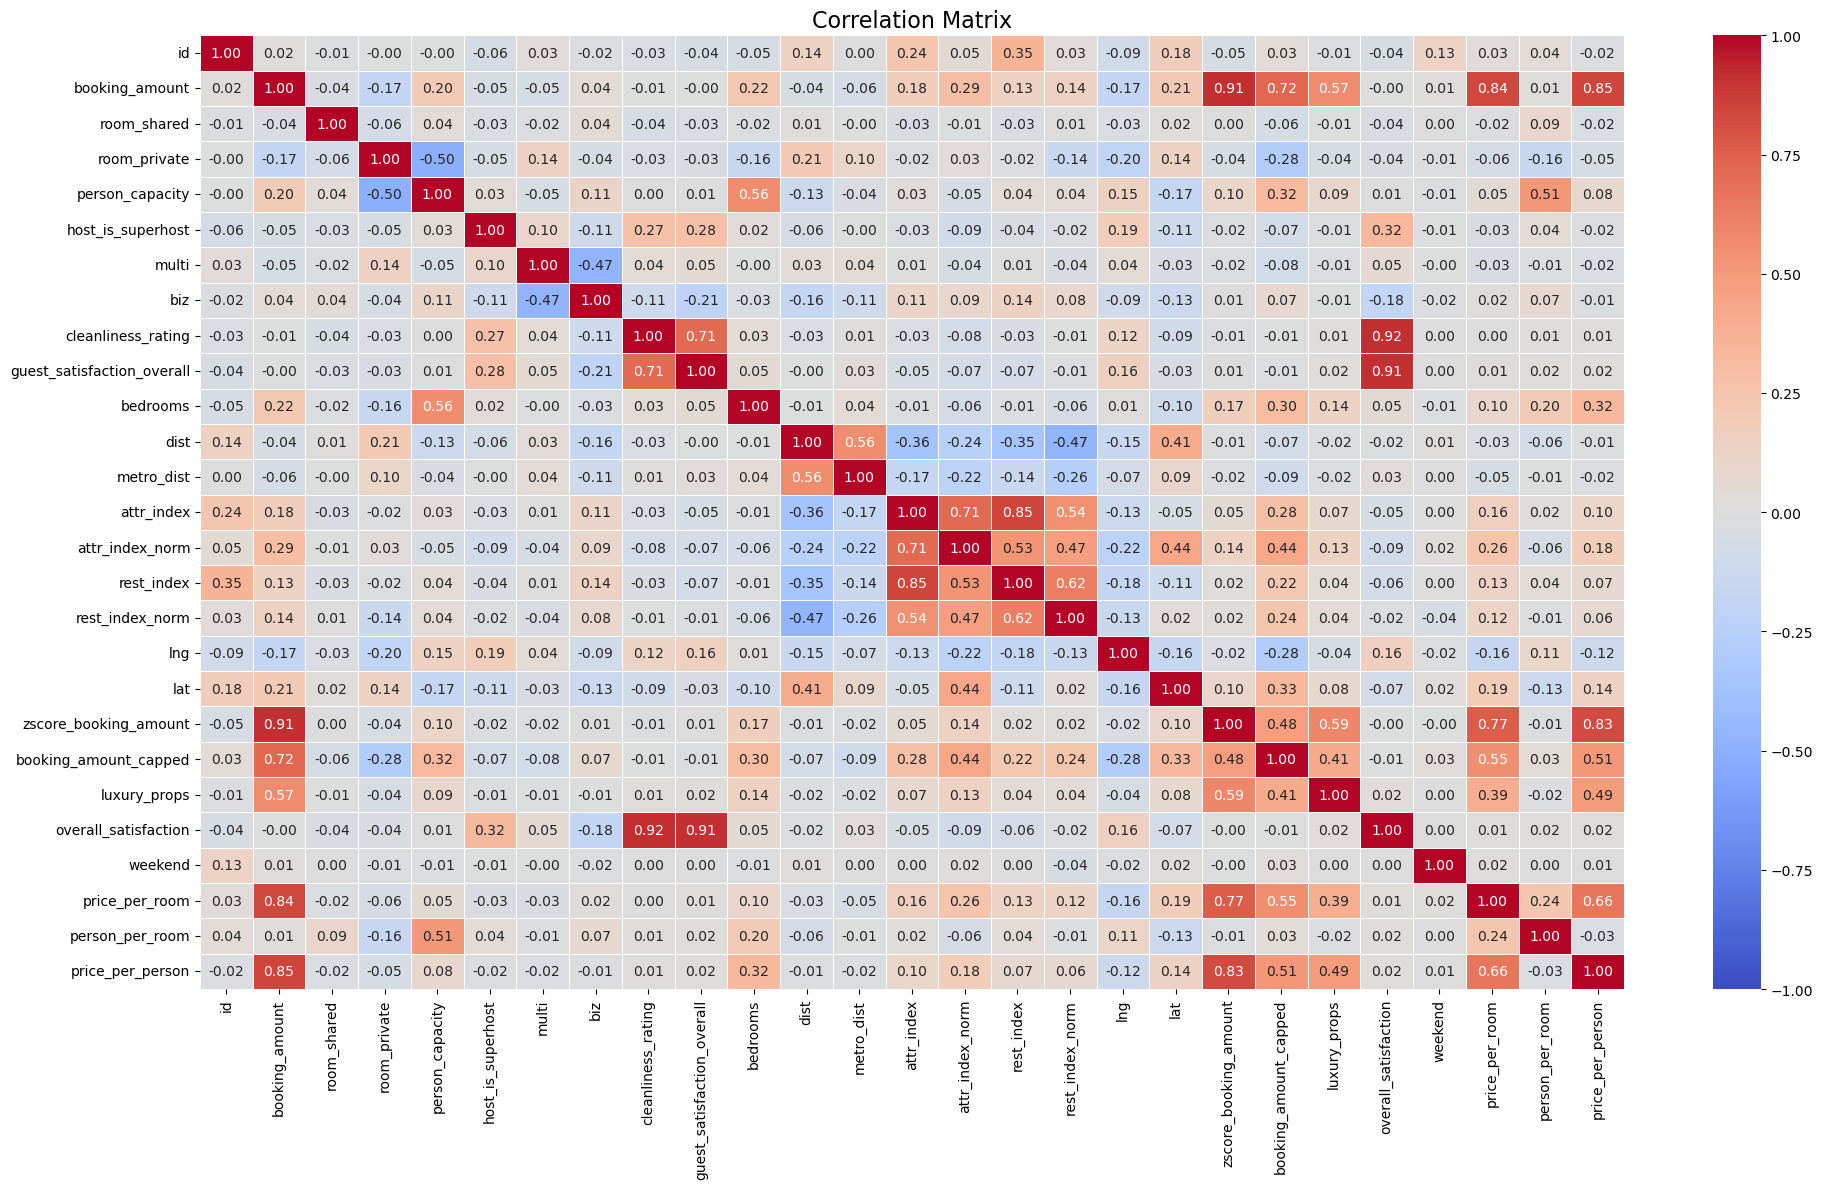

In [95]:
# Correlation matrix
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create the figure for the heatmap
plt.figure(figsize=(20, 12))

# Create a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f',
    linewidths=0.5
)

# Add descriptive title
plt.title('Correlation Matrix', fontsize=16)

# Apply tight layout and Show the plot
plt.tight_layout()
plt.show()

    ⚛ SUMMARY ⚛
	• The features that highly influences the booking amount are : `zscore_booking_amount`, `booking_amount_capped`, `price_per_room` and `price_per_person`.
    • There are a strong positive correlation with `overall_satisfaction` and the two satisfaction features : `guest_satisfaction` and `cleanliness_rating`.
    • The indexes of attraction and restaurant have also a highly positive correlation.

In [98]:
# Pre Processing imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler

# Import Differents Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# !pip install xgboost
from xgboost import XGBRegressor
# !pip install lightgbm
import lightgbm as lgb
# !pip install catboost
from catboost import CatBoostRegressor

# Import Essentials Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time

# Import Cross validation
from sklearn.model_selection import cross_val_score

In [100]:
# 1. Handle categorical features
df = df.apply(LabelEncoder().fit_transform)

# 2. Prepare data for feature selection
X = df.drop(['id', 'time_periods', 'room_private', 'room_shared', 'price_per_room',
             'price_per_person', 'attr_index', 'rest_index', 'lng', 'lat', 'guest_satisfaction_overall',
             'cleanliness_rating', 'zscore_booking_amount', 'booking_amount_capped', 'booking_amount'], axis=1)  # Features
y = df.booking_amount  # Target variable

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=786)

# 4. Apply Robust Scaler
rs = RobustScaler()
X_train = rs.fit_transform(X_train)
X_test = rs.transform(X_test)

    ⚛ SUMMARY ⚛
	• Label Encoding: Converted boolean and categorical variables into numerical values
    • Feature Selection: Dropped unnecessary features such as id, lng, and lat (no predictive value) and high correlated features
    • Train-Test Split: Split the dataset into 80% training and 20% testing sets
    • Scaling: Applied Robust Scaler to reduce the influence of outliers

### **Random Forest Regressor**
The Random Forest method is an ensemble learning strategy that merges various decision trees to develop a powerful predictive model. It is particularly effective for handling non-linear relationships and is well-suited for datasets with many categorical variables and their interactions. Additionally, this model demonstrates resilience against overfitting by leveraging the averaging of multiple trees.

In [102]:
# instantiating the model
model_rf = RandomForestRegressor()

#Starting the modelling
start_rf = time.time()
model_rf.fit(X_train, y_train)

# predicting the  test set results
y_pred_rf = model_rf.predict(X_test)

#Ending the modelling
end_rf = time.time()

# finding the rmse,r2, mae and execution time of the model
score_rf = round(r2_score(y_test, y_pred_rf), 3)
mae_rf = round(mean_absolute_error(y_test, y_pred_rf), 3)
rmse_rf = round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 3)
ex_time_rf = round(end_rf - start_rf, 3)

### **Gradient Boosting Regressor**
Gradient Boosting is an ensemble approach that sequentially constructs decision trees, with each tree designed to improve upon the errors of its predecessors. This model can reach high levels of accuracy when parameters are finely adjusted, is capable of modeling complex and non-linear relationships, and tends to be more robust against overfitting than Random Forest when regularization is utilized. It is especially useful in business applications where even minor enhancements in predictions are significant.

In [103]:
# Instantiating the model
model_gbr = GradientBoostingRegressor()

# Starting the modelling
start_gbr = time.time()

model_gbr.fit(X_train, y_train)

# Predicting the test set results
y_pred_gbr = model_gbr.predict(X_test)

# Ending the modelling
end_gbr = time.time()

# Finding the rmse, r2, mae, and execution time of the model
score_gbr = round(r2_score(y_test, y_pred_gbr), 3)
mae_gbr = round(mean_absolute_error(y_test, y_pred_gbr), 3)
rmse_gbr = round(np.sqrt(mean_squared_error(y_test, y_pred_gbr)), 3)
ex_time_gbr = round(end_gbr - start_gbr, 3)

### **XGBoost Regressor (Extreme Gradient Boosting)**
XGBoost is an enhanced iteration of Gradient Boosting. It is among the most commonly utilized models for both regression and classification tasks. The model is highly scalable and integrates regularization to avoid overfitting, ensuring excellent performance, quick execution times, and reliable accuracy.

In [104]:
# instantiating the model
model_xgb = XGBRegressor()

#Starting the modelling
start_xgb = time.time()

model_xgb.fit(X_train, y_train)

# predicting the  test set results
y_pred_xgb = model_xgb.predict(X_test)

#Ending the modelling
end_xgb = time.time()

# finding the rmse,r2, mae and execution time of the model
score_xgb = round(r2_score(y_test, y_pred_xgb), 3)
mae_xgb = round(mean_absolute_error(y_test, y_pred_xgb), 3)
rmse_xgb = round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 3)
ex_time_xgb = round(end_xgb - start_xgb, 3)

### **LightGBM Regressor**
LightGBM is a gradient boosting framework known for its speed and efficiency. It is scalable and adept at managing categorical features effectively. However, without proper tuning, this model has the potential to overfit.

In [105]:
# instantiating the model
model_lgbm = lgb.LGBMRegressor()

# Train the LightGBM model
start_lgbm = time.time()
model_lgbm.fit(X_train, y_train)
end_lgbm = time.time()

# Make predictions on the test set
y_pred_lgbm = model_lgbm.predict(X_test)

# Evaluate the model
score_lgbm = round(r2_score(y_test, y_pred_lgbm), 3)
mae_lgbm = round(mean_absolute_error(y_test, y_pred_lgbm), 3)
rmse_lgbm = round(np.sqrt(mean_squared_error(y_test, y_pred_lgbm)), 3)
ex_time_lgbm = round(end_lgbm - start_lgbm, 3)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1205
[LightGBM] [Info] Number of data points in the train set: 41365, number of used features: 21
[LightGBM] [Info] Start training from score 3675.623861


### **CatBoost Regressor**
CatBoost is a gradient boosting algorithm designed to efficiently handle categorical features, requiring little preprocessing. This results in impressive predictive accuracy, and it is less sensitive to hyperparameter tuning relative to XGBoost or LightGBM. All methods of Gradient Boosting are are robust to outliers, especially when combined with feature scaling and engineering.

In [106]:
# Create a CatBoostRegressor model
model_catb = CatBoostRegressor()

# Start the modeling
start_catb = time.time()

# Train the model
model_catb.fit(X_train, y_train)

# End the modeling
end_catb = time.time()

# Make predictions on the test set
y_pred_catb = model_catb.predict(X_test)

# Evaluate the model
score_catb = round(r2_score(y_test, y_pred_catb), 3)
mae_catb = round(mean_absolute_error(y_test, y_pred_catb), 3)
rmse_catb = round(np.sqrt(mean_squared_error(y_test, y_pred_catb)), 3)
ex_time_catb = round(end_catb - start_catb, 3)

Learning rate set to 0.073724
0:	learn: 2501.3735590	total: 62.4ms	remaining: 1m 2s
1:	learn: 2405.7161658	total: 65.1ms	remaining: 32.5s
2:	learn: 2320.9000737	total: 67.4ms	remaining: 22.4s
3:	learn: 2243.7991463	total: 69.8ms	remaining: 17.4s
4:	learn: 2174.7329557	total: 72.2ms	remaining: 14.4s
5:	learn: 2113.5272183	total: 74.6ms	remaining: 12.4s
6:	learn: 2059.7473512	total: 77.1ms	remaining: 10.9s
7:	learn: 2012.2595507	total: 79.6ms	remaining: 9.86s
8:	learn: 1966.6432653	total: 82.1ms	remaining: 9.04s
9:	learn: 1928.9594306	total: 84.7ms	remaining: 8.38s
10:	learn: 1890.7276914	total: 87ms	remaining: 7.82s
11:	learn: 1858.2358939	total: 89.5ms	remaining: 7.37s
12:	learn: 1829.2089690	total: 92ms	remaining: 6.98s
13:	learn: 1805.3336496	total: 94.3ms	remaining: 6.64s
14:	learn: 1781.5133341	total: 96.3ms	remaining: 6.32s
15:	learn: 1759.8189315	total: 98.5ms	remaining: 6.06s
16:	learn: 1734.9269868	total: 101ms	remaining: 5.81s
17:	learn: 1714.6614366	total: 103ms	remaining: 5.

### **Models Results**
To confirm that the models were not overfitting, cross-validation was used. The resulting cross-validation score serves as an indicator of how effectively the model can generalize to data it has not encountered before. A higher score signifies improved model robustness.

In [107]:
# Process to Cross Validation
cvs_rf = cross_val_score(estimator=model_rf , X = X_train, y = y_train , cv = 5)
cvs_gbr = cross_val_score(estimator=model_gbr , X = X_train, y = y_train , cv = 5)
cvs_xgb = cross_val_score(estimator=model_xgb , X = X_train, y = y_train , cv = 5)
cvs_lgbm = cross_val_score(estimator=model_lgbm , X = X_train, y = y_train , cv = 5)
cvs_catb = cross_val_score(estimator=model_catb , X = X_train, y = y_train , cv = 5)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1201
[LightGBM] [Info] Number of data points in the train set: 33092, number of used features: 21
[LightGBM] [Info] Start training from score 3676.627251
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1205
[LightGBM] [Info] Number of data points in the train set: 33092, number of used features: 21
[LightGBM] [Info] Start training from score 3677.420071
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

In [109]:
# Print a Dataframe to visualize models metrics
models = pd.DataFrame({
    'Model':["Random Forest", "Gradient Boosting", "XGBoost", "LightGBM", "CatBoost"],
    'R2 Score': [score_rf, score_gbr, score_xgb, score_lgbm, score_catb],
    'MAE': [mae_rf, mae_gbr, mae_xgb, mae_lgbm, mae_catb],
    'RMSE': [rmse_rf, rmse_gbr, rmse_xgb, rmse_lgbm, rmse_catb],
    'Execution Time': [ex_time_rf, ex_time_gbr, ex_time_xgb, ex_time_lgbm, ex_time_catb],
    'CROSS': [round(cvs_rf.mean()*100, 2), round(cvs_gbr.mean()*100, 2),
              round(cvs_xgb.mean()*100, 2), round(cvs_lgbm.mean()*100, 2),
              round(cvs_catb.mean()*100, 2)]
})
models.sort_values(by='R2 Score',ascending=False)

,Model,R2 Score,MAE,RMSE,Execution Time,CROSS
0,Random Forest,0.847,720.628,1020.149,20.418,82.15
2,XGBoost,0.780,913.332,1220.894,0.182,77.40
4,CatBoost,0.777,925.688,1230.637,2.333,77.38
3,LightGBM,0.756,972.930,1286.479,0.187,75.48
1,Gradient Boosting,0.713,1069.675,1396.420,6.304,71.17


	⚛ MODEL-BY-MODEL INTERPRETATION ⚛

	1. Random Forest (Best Model)
	• R² Score: 0.847 (Highest among all models)
	• MAE: 719.68 (Lowest error)
	• RMSE: 1018.47 (Lowest RMSE, indicating good accuracy)
	• Exec Time: 71.97 seconds (Relatively slow)
	• CROSS: 82.18 (Best cross-validation score)
	Interpretation : Among all models evaluated, Random Forest stands out as the most accurate, achieving the best results across various metrics.
	Despite its longer processing time, the model's exceptional R² score and low error rates imply that it effectively accounts for the variance present in the data.
	Additionally, the high score from cross-validation suggests that it generalizes well to new data.

	2. XGBoost (Second Best Model)
	• R² Score: 0.780
	• MAE: 913.33
	• RMSE: 1220.89
	• Exec Time: 0.67 seconds (Fastest model)
	• CROSS: 77.40
	Interpretation : XGBoost is recognized for its efficiency and fast execution, making it a suitable option when rapid performance is crucial.
	While it achieves a respectable R² score of 0.78, its error metrics, specifically MAE and RMSE, are greater than those of Random Forest.
	The cross-validation score of 77.4 indicates that it performs reasonably well on new, unseen data.

	3. CatBoost
	• R² Score: 0.777
	• MAE: 925.69
	• RMSE: 1230.64
	• Execution Time: 10.86 seconds
	• CROSS: 77.38
	Interpretation : CatBoost demonstrates performance that is comparable to XGBoost, although it tends to exhibit marginally higher error rates while maintaining a similar R² score.
	It could serve as a viable alternative, particularly when interpretability is a key consideration, as CatBoost effectively manages categorical data.

	4. LightGBM
	• R² Score: 0.756
	• MAE: 972.93
	• RMSE: 1286.48
	• Execution Time: 0.71 seconds
	• CROSS: 75.48
	Interpretation : LightGBM demonstrates reasonable performance, balancing speed with accuracy.
	However, its R² score and error rates are slightly less impressive than those of CatBoost and XGBoost.
	The reduced cross-validation score also suggests that it may not perform as well on unseen data.

	5. Gradient Boosting (Lowest Performing Model)
	• R² Score: 0.713
	• MAE: 1069.64
	• RMSE: 1396.38
	• Execution Time: 13.15 seconds
	• CROSS: 71.17
	Interpreation : The Gradient Boosting model shows the lowest R² score at 0.713, along with the highest error rates in terms of MAE and RMSE.
	Furthermore, it demands more execution time than the other models.
	With a cross-validation score of 71.17, suggests that it is less reliable than its counterparts.

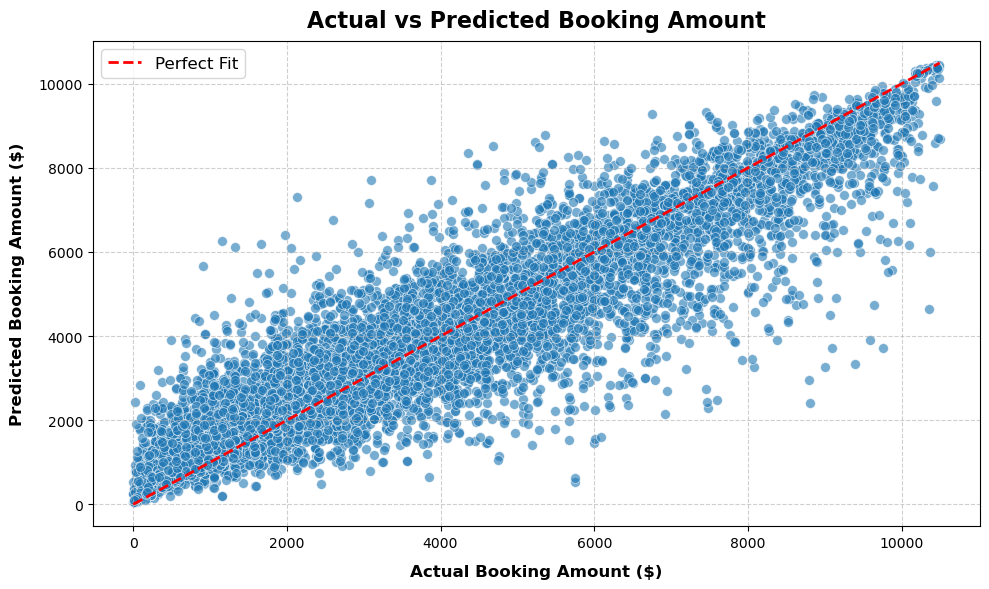

In [113]:
# Visual Interpretation Random Forest Model
# --- Plot: Actual vs Predicted ---
plt.figure(figsize=(10, 6))

# Scatter plot of actual vs predicted
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, s=50, color='tab:blue')

# Plot the perfect prediction line (45-degree line)
max_val = max(max(y_test), max(y_pred_rf))
min_val = min(min(y_test), min(y_pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label='Perfect Fit')

# Titles and labels
plt.title('Actual vs Predicted Booking Amount', fontsize=16, weight='bold', pad=10)
plt.xlabel('Actual Booking Amount ($)', fontsize=12, weight='bold', labelpad=10)
plt.ylabel('Predicted Booking Amount ($)', fontsize=12, weight='bold', labelpad=10)
plt.legend(loc='upper left', fontsize=12)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

    ⚛ INTERPRETATION ⚛
    This chart illustrates a comparison between actual booking amounts and those predicted by the model.
    The red dashed line represents the ideal scenario where predicted equals actual. If all points were on this line, it would signify a 100% accuracy rate for the model.
    In this visualization, numerous blue points are closely clustered around the red line, suggesting that the model demonstrates strong predictive capabilities.
    The model shows effective performance within the booking range of 0$ to 2,000$, exhibiting minimal deviations from the ideal line.
    However, as booking amounts rise, the data points become more scattered, indicating a decrease in accuracy for high-end properties or outliers.
    This trend is common, as predicting luxury properties or high-value bookings often presents greater challenges.

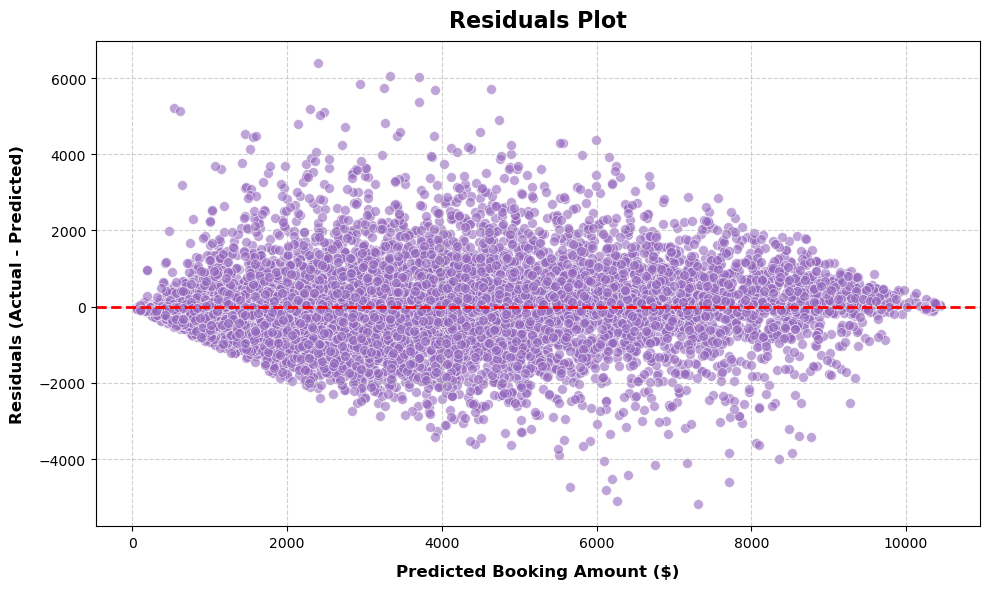

In [115]:
# --- Residuals Plot (to check prediction errors) ---
plt.figure(figsize=(10, 6))

# Residuals = Actual - Predicted
residuals = y_test - y_pred_rf

# Scatter plot of residuals
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.6, s=50, color='tab:purple')
plt.axhline(0, color='red', lw=2, linestyle='--')

# Titles and labels
plt.title('Residuals Plot', fontsize=16, weight='bold', pad=10)
plt.xlabel('Predicted Booking Amount ($)', fontsize=12, weight='bold', labelpad=10)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12, weight='bold', labelpad=10)

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

	A Residual Plot displays the relationship between predicted and actual values, with points closely following a diagonal line, which reflects the model's strong performance.
	The points are randomly scattered around the horizontal line at y=0, that suggests that the model's errors are random and have constant variance. This is a good sign.
	However, some outliers are noticeable, especially at higher predicted booking amounts, and these outliers may be affecting the overall model fit.



### **Model Optimization**

While the Random Forest and XGBoost models demonstrate a positive predictive score, it is essential to enhance these models to achieve the best possible results. This is particularly crucial considering their sensitivity to hyperparameter adjustments and the necessity to reduce the effects of outliers.

In [116]:
!pip install bayesian-optimization
from bayes_opt import BayesianOptimization

# Define the function to optimize
def rf_cv(n_estimators, min_samples_split, max_features):
    model = RandomForestRegressor(
        n_estimators=int(n_estimators),
        min_samples_split=int(min_samples_split),
        max_features=min(max_features, 0.999)
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return -mean_squared_error(y_test, y_pred)

# Set the parameters bounds
pbounds = {
    'n_estimators': (10, 300),
    'min_samples_split': (2, 20),
    'max_features': (0.1, 0.999)
}

# Run Bayesian optimization
optimizer = BayesianOptimization(
    f=rf_cv,
    pbounds=pbounds,
    random_state=42,
)

optimizer.maximize(
    init_points=10,
    n_iter=30,
)

# Display the optimal parameters
print(optimizer.max)

|   iter    |  target   | max_fe... | min_sa... | n_esti... |
-------------------------------------------------------------
| 1         | -1.338e+0 | 0.4367    | 19.11     | 222.3     |
| 2         | -1.069e+0 | 0.6382    | 4.808     | 55.24     |
| 3         | -1.606e+0 | 0.1522    | 17.59     | 184.3     |
| 4         | -1.019e+0 | 0.7366    | 2.371     | 291.3     |
| 5         | -1.077e+0 | 0.8484    | 5.822     | 62.73     |
| 6         | -1.264e+0 | 0.2649    | 7.476     | 162.2     |
| 7         | -1.142e+0 | 0.4883    | 7.242     | 187.4     |
| 8         | -1.335e+0 | 0.2254    | 7.259     | 116.2     |
| 9         | -1.3e+06  | 0.51      | 16.13     | 67.91     |
| 10        | -1.277e+0 | 0.5623    | 12.66     | 23.47     |
| 11        | -1.027e+0 | 0.7802    | 3.152     | 292.1     |
| 12        | -1.264e+0 | 0.2851    | 7.23      | 285.0     |
| 13        | -1.442e+0 | 0.1       | 2.0       | 299.1     |
| 14        | -1.043e+0 | 0.999     | 2.0       | 59.36     |
| 15    

In [117]:
# Get the best parameters from the optimizer
best_params = optimizer.max['params']

# Rebuild the model with the optimized parameters
optimized_rf_model = RandomForestRegressor(
    n_estimators=int(best_params['n_estimators']),
    min_samples_split=int(best_params['min_samples_split']),
    max_features=best_params['max_features']
)

# Train the optimized model
optimized_rf_model.fit(X_train, y_train)

# Make predictions on the test set
optimized_y_pred = optimized_rf_model.predict(X_test)

# Evaluate the optimized model
optimized_score = round(r2_score(y_test, optimized_y_pred), 3)
optimized_mae = round(mean_absolute_error(y_test, optimized_y_pred), 3)
optimized_rmse = round(np.sqrt(mean_squared_error(y_test, optimized_y_pred)), 3)

# Print the results
print(f"Optimized Random Forest R2 Score: {optimized_score}")
print(f"Optimized Random Forest MAE: {optimized_mae}")
print(f"Optimized Random Forest RMSE: {optimized_rmse}")

Optimized Random Forest R2 Score: 0.85
Optimized Random Forest MAE: 716.534
Optimized Random Forest RMSE: 1009.701


    The optimized parameters enable the random forest model to achieve an impressive R² score of 0.85, showcasing its effectiveness.

In [118]:
from bayes_opt import BayesianOptimization
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Define the function to optimize
def xgb_cv(max_depth, learning_rate, n_estimators, gamma, min_child_weight, subsample, colsample_bytree):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'n_estimators': int(n_estimators),
        'gamma': gamma,
        'min_child_weight': min_child_weight,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'objective': 'reg:squarederror'
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return -mean_squared_error(y_test, y_pred)

# Set the parameters bounds
pbounds = {
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'n_estimators': (50, 300),
    'gamma': (0, 0.5),
    'min_child_weight': (1, 10),
    'subsample': (0.5, 1),
    'colsample_bytree': (0.5, 1)
}

# Run Bayesian optimization
optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    random_state=42,
)

optimizer.maximize(
    init_points=10,
    n_iter=30,
)

# Display the optimal parameters
print(optimizer.max)

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
| 1         | -1.516e+0 | 0.6873    | 0.4754    | 0.2223    | 7.191     | 2.404     | 89.0      | 0.529     |
| 2         | -1.695e+0 | 0.9331    | 0.3006    | 0.2153    | 3.144     | 9.729     | 258.1     | 0.6062    |
| 3         | -1.608e+0 | 0.5909    | 0.0917    | 0.09823   | 6.673     | 4.888     | 122.8     | 0.8059    |
| 4         | -1.61e+06 | 0.5697    | 0.1461    | 0.1162    | 6.192     | 8.067     | 99.92     | 0.7571    |
| 5         | -1.596e+0 | 0.7962    | 0.02323   | 0.1862    | 4.194     | 1.585     | 287.2     | 0.9828    |
| 6         | -1.775e+0 | 0.9042    | 0.1523    | 0.03832   | 7.79      | 4.961     | 80.51     | 0.7476    |
| 7         | -1.489e+0 | 0.5172    | 0.4547    | 0.08505   | 7.638     | 3.805     | 180.0     | 0.7734    |
| 8       

In [119]:
# Get the best parameters from the optimizer
best_params = optimizer.max['params']

# Rebuild the model with the optimized parameters
optimized_xgb_model = xgb.XGBRegressor(
    max_depth=int(best_params['max_depth']),
    learning_rate=best_params['learning_rate'],
    n_estimators=int(best_params['n_estimators']),
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    objective='reg:squarederror'
)

# Train the optimized model
optimized_xgb_model.fit(X_train, y_train)

# Make predictions on the test set
optimized_y_pred_xgb = optimized_xgb_model.predict(X_test)

# Evaluate the optimized model
optimized_score_xgb = round(r2_score(y_test, optimized_y_pred_xgb), 3)
optimized_mae_xgb = round(mean_absolute_error(y_test, optimized_y_pred_xgb), 3)
optimized_rmse_xgb = round(np.sqrt(mean_squared_error(y_test, optimized_y_pred_xgb)), 3)

# Print the results
print(f"Optimized XGBoost R2 Score: {optimized_score_xgb}")
print(f"Optimized XGBoost MAE: {optimized_mae_xgb}")
print(f"Optimized XGBoost RMSE: {optimized_rmse_xgb}")

Optimized XGBoost R2 Score: 0.838
Optimized XGBoost MAE: 750.593
Optimized XGBoost RMSE: 1048.051


    XGBoost shows a significant improvement in scoring, reaching 0.83 with its tuned parameters.